#### This script uses five classifiers, linear,ann,knn,protonet and random_forest to get a final classifier using the slide aggregations.
#### It also outputs results metrics such as Balance accuracy, AUROC etc into a csv in the output folder.

In [1]:
import os
os.getcwd()

'd:\\Aamir Gulzar\\KSA_project2\\Cancer-detection-classifier\\slide_classification'

## Hugging face login

In [2]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
load_dotenv()
from huggingface_hub import login

login(os.environ["HF_TOKEN"])

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to C:\Users\datainsight\.cache\huggingface\token
Login successful


In [3]:
from typing import List, Tuple, Dict, Any, Optional
import torch
import torchvision
from torch.utils.data import DataLoader
import os
from os.path import join as j_
from PIL import Image
import pandas as pd
import numpy as np
import time
import random
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import Lambda
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
# loading all packages here to start
# from dataloader import WSIDataset
from eval_patch_features.logistic import eval_linear
from eval_patch_features.ann import eval_ANN
from eval_patch_features.knn import eval_knn
from eval_patch_features.protonet import eval_protonet
from eval_patch_features.r_forest_eval import eval_r_forest
from eval_patch_features.metrics import get_eval_metrics, print_metrics
from utility import calculate_metric_averages, average_confusion_matrices, write_data_in_excel, build_probs_df
from Tissue_Type_Combinations_Exp.TTC_combination_experiment import run_tissue_combination_search
import warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 9 Classes

## Method 1 : Check individual class results then match strong classes

In [4]:
"""
tissue_combination_search.py
─────────────────────────────────────────────────────────────────────────────
Runs two phases of experiments for Tissue_Type_Clustering features only:

  Phase 1 — Individual class evaluation
      Tests each of the 9 tissue classes in isolation (1×N vector),
      EXCLUDING the background class (it is never useful as a standalone
      predictor and is already excluded from Phase 2 combinations).
      Results are saved to: tissue_individual_class_results.xlsx
      Classes are then ranked by bacc and grouped into tiers:
          Strong  (bacc ≥ STRONG_THRESHOLD)
          Neutral (bacc ≥ NEUTRAL_THRESHOLD)
          Weak    (bacc <  NEUTRAL_THRESHOLD)

  Phase 2 — Smart combination search
      Combinations are filtered by tier rules before testing:
          • MAX_WEAK_PERCENT    — skip if too many Weak classes
          • MAX_NEUTRAL_PERCENT — skip if too many Neutral classes
          • MIN_STRONG_COUNT    — skip if too few Strong classes
      Background is excluded from all combinations.
      Results are saved to: tissue_combo_summary_k{k}.xlsx (ranked by bacc)

  Feature vector note
      Stored .pt tensors are always (9 × feature_dim) matrices where each
      row corresponds to the TISSUE_CLASS_NAMES index (0–8).  Background is
      index 1.  We never change the matrix layout — we simply never pass
      index 1 as a row_index to the dataset, so its feature row is never
      loaded into any training or test vector.

  Model saving
      One best model is kept per (foundation model, k value).
      Saved to: …/models/best_{k}labels_TTC/
      All intermediate checkpoints are deleted immediately after each combo.
"""

import os
import gc
import shutil
import itertools
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from itertools import product as iproduct

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

MODEL_NAMES = ["H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"]

MODEL_BASE_DIMS = {
    "H-Optimus-1": 1536,
    "UNI2":        1536,
    "Conch1_5":     768,
    "Virchow2":    2560,
    "ConchV1":      512,
}

TASK_PREFIXES = {
    "MSIH": "1-MSIH",
    "BRAF": "2-BRAF",
    "KRAS": "3-KRAS",
    "TP53": "4-TP53",
    "CIMP": "5-CIMP",
}

TASK_FOLD_CONFIG = {
    "MSIH": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\kfolds_IDARS_fixed.csv",
             "label_desc",    "nonMSIH"),
    "BRAF": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_BRAF.csv",
             "BRAF_mutation", "WT"),
    "KRAS": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_KRAS.csv",
             "KRAS_mutation", "WT"),
    "TP53": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_TP53.csv",
             "TP53_mutation", "WT"),
    "CIMP": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_CIMP.csv",
             "CIMP",          "neg"),
}

TISSUE_CLASS_NAMES = [
    "adipose",       # index 0  — row 0 of the (9 × D) feature matrix
    "background",    # index 1  — row 1  ← NEVER used as a row_index
    "debris",        # index 2  — row 2
    "lymphocyte",    # index 3  — row 3
    "mucin",         # index 4  — row 4
    "smooth_muscle", # index 5  — row 5
    "normal_mucosa", # index 6  — row 6
    "stroma",        # index 7  — row 7
    "tumor",         # index 8  — row 8
]
NUM_TISSUE_CLASSES = 9  # total rows in the stored tensor — do NOT change

# Index of the background class — excluded from Phase 1 and all Phase 2 combos
BACKGROUND_IDX = TISSUE_CLASS_NAMES.index("background")  # → 1

# Indices available for Phase 1 individual evaluation and Phase 2 combinations
EVALUABLE_INDICES = [i for i in range(NUM_TISSUE_CLASSES) if i != BACKGROUND_IDX]
# → [0, 2, 3, 4, 5, 6, 7, 8]  (8 classes)

BATCH_SIZE  = 4
task_names  = ["MSIH"]
model_types = ["ann"]
k_values    = [3,5,8]
rank_by     = "bacc"

STRONG_THRESHOLD  = 0.66
NEUTRAL_THRESHOLD = 0.57

MAX_WEAK_PERCENT    = 0.35
MAX_NEUTRAL_PERCENT = 0.70
MIN_STRONG_COUNT    = 1

RESULT_FOLDER      = "TCGA_Results_Updated"
BASE_ROOT          = r"D:\Aamir Gulzar\KSA_project2"
PROJECT_ROOT       = os.path.join(BASE_ROOT, "Cancer-detection-classifier", "slide_classification")
AGGREGATION_METHOD = "Tissue_Type_Clustering"
sheet_name         = "tissue_search"


# ─────────────────────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────────────────────

class TissueCombinationDataset(Dataset):
    """
    Loads flattened (NUM_TISSUE_CLASSES × feature_dim) .pt tensors.

    The stored tensor always has NUM_TISSUE_CLASSES (9) rows — one per tissue
    class in the original order.  `row_indices` selects which of those rows
    to include in the output feature vector.  Background (index 1) is never
    passed in row_indices, so its row is simply never read into the model.

    Output feature vector shape: (len(row_indices) × feature_dim,)
    """

    def __init__(
        self,
        save_dir:     str,
        fold_ids:     List[str],
        row_indices:  List[int],   # indices into the 9-row matrix; never contains 1
        num_classes:  int,         # always NUM_TISSUE_CLASSES (9)
        feature_dim:  int,
        label_col:    str,
        neg_value:    str,
        k_folds_path: str,
    ):
        self.save_dir    = save_dir
        self.fold_ids    = set(fold_ids)
        self.row_indices = row_indices
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.label_col   = label_col
        self.neg_value   = neg_value

        folds_df      = pd.read_csv(k_folds_path)
        self.folds_df = folds_df.set_index("WSI_Id")

        self.data: List[Tuple[torch.Tensor, int, str]] = []
        self._load()

    def _load(self):
        expected_len = self.num_classes * self.feature_dim  # always 9 × D

        for fname in os.listdir(self.save_dir):
            if not fname.endswith(".pt"):
                continue
            wsi_id = os.path.splitext(fname)[0]
            if wsi_id not in self.fold_ids:
                continue
            if wsi_id not in self.folds_df.index:
                continue

            try:
                feats = torch.load(
                    os.path.join(self.save_dir, fname), map_location="cpu"
                )
                flat = feats.cpu().flatten()

                if flat.numel() != expected_len:
                    print(f"[WARN] {fname}: expected {expected_len} elements "
                          f"(9 × {self.feature_dim}), got {flat.numel()}. Skipping.")
                    continue

                # Reshape to (9, feature_dim) and select only the requested rows.
                # Background row (index 1) is never in row_indices so it is
                # simply never copied into `selected`.
                matrix   = flat.view(self.num_classes, self.feature_dim)
                selected = matrix[self.row_indices].flatten()

                raw   = self.folds_df.at[wsi_id, self.label_col]
                label = 0 if raw == self.neg_value else 1

                self.data.append((selected, label, wsi_id))

            except Exception as exc:
                print(f"[ERROR] {fname}: {exc}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        feats, label, wsi_id = self.data[idx]
        return feats, label, wsi_id


# ─────────────────────────────────────────────────────────────────────────────
# MODEL SAVING HELPERS
# ─────────────────────────────────────────────────────────────────────────────

class BestModelTracker:
    def __init__(self, label: str):
        self.label      = label
        self.best_score = -1.0
        self.best_path: Optional[str] = None

    def update(self, score: float, candidate_path: Optional[str]) -> bool:
        if score <= self.best_score:
            if candidate_path and os.path.exists(candidate_path):
                try:
                    os.remove(candidate_path)
                except OSError:
                    pass
            return False

        if self.best_path and os.path.exists(self.best_path):
            try:
                os.remove(self.best_path)
            except OSError:
                pass

        self.best_score = score
        self.best_path  = candidate_path
        return True

    def cleanup(self, keep_dir: str):
        if self.best_path and os.path.exists(self.best_path):
            os.makedirs(keep_dir, exist_ok=True)
            dest = os.path.join(
                keep_dir,
                f"best_{self.label}_{rank_by}{self.best_score:.4f}.pt",
            )
            shutil.copy2(self.best_path, dest)
            try:
                os.remove(self.best_path)
            except OSError:
                pass
            print(f"  ✓ Best model saved → {dest}")
        else:
            print(f"  [WARN] No best model found for {self.label} — nothing saved.")


def _temp_model_dir(output_save_path: str, label: str) -> str:
    d = os.path.join(
        output_save_path, "_tmp_models", label.replace("+", "_")
    )
    os.makedirs(d, exist_ok=True)
    return d


def _cleanup_temp_dir(output_save_path: str):
    tmp = os.path.join(output_save_path, "_tmp_models")
    if os.path.isdir(tmp):
        shutil.rmtree(tmp, ignore_errors=True)


# ─────────────────────────────────────────────────────────────────────────────
# K-FOLD RUNNER
# ─────────────────────────────────────────────────────────────────────────────

def _run_one_combo_kfold(
    task_name:       str,
    data_path:       str,
    k_folds_path:    str,
    folds:           List[List[str]],
    row_indices:     List[int],   # indices into the 9-row matrix; never contains 1
    num_classes:     int,         # always NUM_TISSUE_CLASSES (9)
    feature_dim:     int,
    model_type:      str,
    model_save_path: str,
    label_col:       str,
    neg_value:       str,
    tracker:         BestModelTracker,
) -> List[Dict[str, Any]]:
    vector_dim       = len(row_indices) * feature_dim
    metric_key       = f"{model_type}_macro_f1"
    results_per_fold = []
    num_folds        = len(folds)

    for i in range(num_folds):
        test_ids  = folds[i]
        val_ids   = folds[(i + 1) % num_folds]
        train_ids = [
            wsi_id
            for j, fold in enumerate(folds)
            if j != i and j != (i + 1) % num_folds
            for wsi_id in fold
        ]

        def make_loader(ids, shuffle):
            ds = TissueCombinationDataset(
                save_dir     = data_path,
                fold_ids     = ids,
                row_indices  = row_indices,
                num_classes  = num_classes,   # always 9
                feature_dim  = feature_dim,
                label_col    = label_col,
                neg_value    = neg_value,
                k_folds_path = k_folds_path,
            )
            if len(ds) == 0:
                raise ValueError(
                    f"Empty dataset for fold {i+1} — "
                    f"check WSI IDs vs files in {data_path}"
                )
            return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

        train_loader = make_loader(train_ids, shuffle=True)
        val_loader   = make_loader(val_ids,   shuffle=False)
        test_loader  = make_loader(test_ids,  shuffle=False)

        def collect(loader):
            feats, labels, ids = [], [], []
            for f, l, w in loader:
                feats.append(f)
                labels.append(l)
                ids.extend(w if isinstance(w, (list, tuple)) else [w])
            return torch.cat(feats), torch.cat(labels), ids

        tr_f, tr_l, _            = collect(train_loader)
        va_f, va_l, _            = collect(val_loader)
        te_f, te_l, test_ids_out = collect(test_loader)

        best_metrics, best_dump, best_params = None, None, None
        last_saved_path = None

        if model_type == "lin":
            for C, max_iter in iproduct([10], [300]):
                m, d = eval_linear(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    max_iter=max_iter, save_path=model_save_path,
                    C=C, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"lin_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (C, max_iter)

        elif model_type == "ann":
            for h1, h2, max_iter in iproduct([128, 256], [64, 128], [500]):
                m, d = eval_ANN(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    input_dim=vector_dim, hidden_dim=h1, hidden_dim2=h2,
                    max_iter=max_iter, model_save_path=model_save_path,
                    verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"ann_fold{i}.pt")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (h1, h2, max_iter)

        elif model_type == "knn":
            for k_n in [3]:
                m, d = eval_knn(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    val_feats=va_f,   val_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_neighbors=k_n, normalize_feats=True,
                    model_save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"knn_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, k_n

        elif model_type == "proto":
            best_metrics, best_dump = eval_protonet(
                fold=i, train_feats=tr_f, train_labels=tr_l,
                val_feats=va_f, val_labels=va_l,
                test_feats=te_f, test_labels=te_l,
                normalize_feats=True, model_save_path=model_save_path,
            )
            last_saved_path = os.path.join(model_save_path, f"proto_fold{i}.pt")
            best_params = None

        elif model_type == "rf":
            for n_est, max_d, min_split, min_leaf, cw, thresh in iproduct(
                [500], [None], [5], [1], [{0: 1, 1: 10}], [0.3]
            ):
                m, d = eval_r_forest(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_estimators=n_est, max_depth=max_d,
                    min_samples_split=min_split, min_samples_leaf=min_leaf,
                    class_weight=cw, prediction_threshold=thresh,
                    save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"rf_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (
                        n_est, max_d, min_split, min_leaf, cw, thresh)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

        fold_score = best_metrics.get(f"{model_type}_{rank_by}", 0.0)
        tracker.update(fold_score, last_saved_path)

        if best_params:
            print(f"  Fold {i+1} | {model_type} best params: {best_params} | "
                  f"{rank_by}={fold_score:.4f}")

        results_per_fold.append({
            **best_metrics,
            **best_dump,
            "wsi_ids": test_ids_out,
            "fold":    i + 1,
        })

    return results_per_fold


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — individual class evaluation (background excluded)
# ─────────────────────────────────────────────────────────────────────────────

def run_phase1_individual_classes(
    task_name:        str,
    data_path:        str,
    k_folds_path:     str,
    folds:            List[List[str]],
    feature_dim:      int,
    model_name:       str,
    output_save_path: str,
    label_col:        str,
    neg_value:        str,
) -> pd.DataFrame:
    """
    Evaluates each tissue class in isolation, SKIPPING background (index 1).

    row_indices passed to the dataset is always a single-element list [class_idx]
    where class_idx is the position in the original 9-row matrix.  The dataset
    slices matrix[class_idx] → a (1 × feature_dim) → flattened to (feature_dim,).
    This is correct because the stored tensor always has 9 rows in the original order.

    Returns a DataFrame of 8 rows (one per non-background class) sorted by
    best_bacc descending, with tier labels assigned.
    """
    print(f"\n{'─'*60}")
    print(f"  PHASE 1 — Individual class evaluation (background excluded)")
    print(f"  Model: {model_name} | Task: {task_name}")
    print(f"{'─'*60}")

    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}
    rows = []

    # Iterate over EVALUABLE_INDICES — background (index 1) is not in this list
    for class_idx in EVALUABLE_INDICES:
        class_name = TISSUE_CLASS_NAMES[class_idx]
        print(f"\n  Class {class_idx}: {class_name}")
        row: Dict[str, Any] = {"class_idx": class_idx, "class_name": class_name}

        model_save_path = _temp_model_dir(output_save_path, f"individual_{class_name}")
        tracker = BestModelTracker(f"{model_name}_phase1_{class_name}")

        for model_type in model_types:
            try:
                fold_results = _run_one_combo_kfold(
                    task_name       = task_name,
                    data_path       = data_path,
                    k_folds_path    = k_folds_path,
                    folds           = folds,
                    row_indices     = [class_idx],  # single row; class_idx is the
                                                    # correct position in the 9-row matrix
                    num_classes     = NUM_TISSUE_CLASSES,  # always 9
                    feature_dim     = feature_dim,
                    model_type      = model_type,
                    model_save_path = model_save_path,
                    label_col       = label_col,
                    neg_value       = neg_value,
                    tracker         = tracker,
                )

                avg = calculate_metric_averages(
                    [{k: v for k, v in r.items()
                      if k in [f"{model_type}_{m}" for m in metric_indices]}
                     for r in fold_results],
                    metric_indices,
                    model_prefix=model_type,
                )
                for m in metric_indices:
                    row[f"{model_type}_{m}"] = avg.get(f"{model_type}_{m}", float("nan"))

            except Exception as exc:
                print(f"    [ERROR] {model_type}: {exc}")
                for m in metric_indices:
                    row[f"{model_type}_{m}"] = float("nan")

        bacc_vals = [row.get(f"{mt}_bacc", float("nan")) for mt in model_types]
        bacc_vals = [v for v in bacc_vals if not np.isnan(v)]
        row["best_bacc"] = (
            sum(bacc_vals) / len(bacc_vals) if bacc_vals else float("nan")
        )

        b = row["best_bacc"]
        row["tier"] = (
            "Strong"  if b >= STRONG_THRESHOLD  else
            "Neutral" if b >= NEUTRAL_THRESHOLD else
            "Weak"
        )
        print(f"    best_bacc={b:.4f}  tier={row['tier']}")
        rows.append(row)

    _cleanup_temp_dir(output_save_path)

    df = pd.DataFrame(rows).sort_values("best_bacc", ascending=False)
    out_path = os.path.join(output_save_path, "tissue_individual_class_results.xlsx")
    write_data_in_excel(out_path, df, sheet_name="individual_classes")
    print(f"\n  ✓ Phase 1 results → {out_path}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# TIER-BASED COMBINATION GENERATOR
# ─────────────────────────────────────────────────────────────────────────────

def _smart_combinations(
    class_df: pd.DataFrame, k: int
) -> List[Tuple[int, ...]]:
    """
    Returns all C(8,k) combinations from EVALUABLE_INDICES that pass all
    three tier filters.  Background (index 1) is already absent from
    EVALUABLE_INDICES so no additional check is needed here.

    Note: the indices in each returned tuple are the original 9-row matrix
    positions, which is exactly what TissueCombinationDataset expects.
    """
    strong  = set(class_df[class_df["tier"] == "Strong" ]["class_idx"].tolist())
    neutral = set(class_df[class_df["tier"] == "Neutral"]["class_idx"].tolist())
    weak    = set(class_df[class_df["tier"] == "Weak"   ]["class_idx"].tolist())

    # Only combine from evaluable (non-background) indices
    all_combos = list(itertools.combinations(EVALUABLE_INDICES, k))

    filtered          = []
    n_removed_weak    = 0
    n_removed_neutral = 0
    n_removed_strong  = 0

    for combo in all_combos:
        n_weak    = sum(1 for i in combo if i in weak)
        n_neutral = sum(1 for i in combo if i in neutral)
        n_strong  = sum(1 for i in combo if i in strong)

        if n_weak / k > MAX_WEAK_PERCENT:
            n_removed_weak += 1
            continue
        if n_neutral / k > MAX_NEUTRAL_PERCENT:
            n_removed_neutral += 1
            continue
        if n_strong < MIN_STRONG_COUNT:
            n_removed_strong += 1
            continue

        filtered.append(combo)

    print(f"  k={k}: {len(all_combos)} total → {len(filtered)} kept  "
          f"(removed {n_removed_weak} excess-weak, "
          f"{n_removed_neutral} excess-neutral, "
          f"{n_removed_strong} insufficient-strong  |  "
          f"thresholds: max_weak={MAX_WEAK_PERCENT:.0%}, "
          f"max_neutral={MAX_NEUTRAL_PERCENT:.0%}, "
          f"min_strong={MIN_STRONG_COUNT})")
    return filtered


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — combination search
# ─────────────────────────────────────────────────────────────────────────────

def run_phase2_combination_search(
    task_name:        str,
    data_path:        str,
    k_folds_path:     str,
    folds:            List[List[str]],
    feature_dim:      int,
    model_name:       str,
    output_save_path: str,
    label_col:        str,
    neg_value:        str,
    class_df:         pd.DataFrame,
    models_root_dir:  str,
):
    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}

    for k in k_values:
        k_tracker  = BestModelTracker(f"{model_name}_k{k}")
        k_best_dir = os.path.join(models_root_dir, f"best_{k}labels_TTC")
        os.makedirs(k_best_dir, exist_ok=True)

        combos = _smart_combinations(class_df, k)
        print(f"\n{'─'*60}")
        print(f"  PHASE 2 — k={k} | {len(combos)} combos | Model: {model_name}")
        print(f"{'─'*60}")

        summary_rows      = []
        best_combo_score  = -1.0
        best_combo_label  = ""
        best_combo_probs: Optional[pd.DataFrame] = None

        for combo_idx, row_indices in enumerate(combos):
            # row_indices are original 9-row matrix positions (no background)
            combo_label = "+".join(TISSUE_CLASS_NAMES[i] for i in row_indices)
            print(f"\n  [{combo_idx+1}/{len(combos)}] {combo_label}")

            model_save_path = _temp_model_dir(output_save_path, combo_label)
            combo_probs_df: Optional[pd.DataFrame] = None

            for model_type in model_types:
                try:
                    fold_results = _run_one_combo_kfold(
                        task_name       = task_name,
                        data_path       = data_path,
                        k_folds_path    = k_folds_path,
                        folds           = folds,
                        row_indices     = list(row_indices),
                        num_classes     = NUM_TISSUE_CLASSES,  # always 9
                        feature_dim     = feature_dim,
                        model_type      = model_type,
                        model_save_path = model_save_path,
                        label_col       = label_col,
                        neg_value       = neg_value,
                        tracker         = k_tracker,
                    )

                    model_df = build_probs_df(fold_results, model_name=model_type)
                    combo_probs_df = (
                        model_df if combo_probs_df is None
                        else pd.merge(combo_probs_df, model_df,
                                      on=["Fold", "WSI_ID", "Target"], how="outer")
                    )

                    avg = calculate_metric_averages(
                        [{key: v for key, v in r.items()
                          if key in [f"{model_type}_{m}" for m in metric_indices]}
                         for r in fold_results],
                        metric_indices,
                        model_prefix=model_type,
                    )

                    combo_score = avg.get(f"{model_type}_{rank_by}", -1.0)
                    summary_rows.append({
                        "combo":      combo_label,
                        "rows":       str(list(row_indices)),
                        "k":          k,
                        "model_type": model_type,
                        **{m: avg.get(f"{model_type}_{m}", float("nan"))
                           for m in metric_indices},
                    })

                    if combo_score > best_combo_score:
                        best_combo_score = combo_score
                        best_combo_label = combo_label
                        best_combo_probs = (
                            combo_probs_df.copy()
                            if combo_probs_df is not None else None
                        )

                except Exception as exc:
                    print(f"    [ERROR] {model_type}: {exc}")

            if os.path.isdir(model_save_path):
                shutil.rmtree(model_save_path, ignore_errors=True)
            gc.collect()

        summary_df = (
            pd.DataFrame(summary_rows)
            .sort_values(rank_by, ascending=False)
        )
        summary_path = os.path.join(output_save_path, f"tissue_combo_summary_k{k}.xlsx")
        write_data_in_excel(summary_path, summary_df, sheet_name=f"k{k}")
        print(f"\n  ✓ Summary k={k} → {summary_path}")
        print(f"  Best combo ({rank_by}={best_combo_score:.4f}): {best_combo_label}")

        if best_combo_probs is not None:
            probs_path = os.path.join(
                output_save_path, f"tissue_combo_probs_k{k}_best.xlsx"
            )
            write_data_in_excel(probs_path, best_combo_probs,
                                sheet_name=f"k{k}_best_probs")
            print(f"  Best combo probs → {probs_path}")

        k_tracker.cleanup(keep_dir=k_best_dir)

    _cleanup_temp_dir(output_save_path)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────

for MODEL_NAME in MODEL_NAMES:
    feature_dim = MODEL_BASE_DIMS[MODEL_NAME]

    DATA_PATH   = os.path.join(
        BASE_ROOT, "dataset", "slide_aggregation", AGGREGATION_METHOD, MODEL_NAME
    )
    RESULT_ROOT = os.path.join(
        PROJECT_ROOT, RESULT_FOLDER, AGGREGATION_METHOD, MODEL_NAME
    )

    for task_name in task_names:
        folder_task_name = TASK_PREFIXES.get(task_name, task_name)
        OUTPUT_SAVE_PATH = os.path.join(RESULT_ROOT, folder_task_name, "Output")
        MODELS_ROOT_DIR  = os.path.join(RESULT_ROOT, folder_task_name, "models")

        os.makedirs(OUTPUT_SAVE_PATH, exist_ok=True)
        os.makedirs(MODELS_ROOT_DIR,  exist_ok=True)

        k_folds_path, label_col, neg_value = TASK_FOLD_CONFIG[task_name]

        folds_df = pd.read_csv(k_folds_path)
        folds: List[List[str]] = [
            folds_df[folds_df["fold"] == fn]["WSI_Id"].tolist()
            for fn in sorted(folds_df["fold"].unique())
        ]

        print(f"\n{'='*70}")
        print(f"  Model: {MODEL_NAME} | Task: {task_name}")
        print(f"{'='*70}")

        class_df = run_phase1_individual_classes(
            task_name        = task_name,
            data_path        = DATA_PATH,
            k_folds_path     = k_folds_path,
            folds            = folds,
            feature_dim      = feature_dim,
            model_name       = MODEL_NAME,
            output_save_path = OUTPUT_SAVE_PATH,
            label_col        = label_col,
            neg_value        = neg_value,
        )

        run_phase2_combination_search(
            task_name        = task_name,
            data_path        = DATA_PATH,
            k_folds_path     = k_folds_path,
            folds            = folds,
            feature_dim      = feature_dim,
            model_name       = MODEL_NAME,
            output_save_path = OUTPUT_SAVE_PATH,
            label_col        = label_col,
            neg_value        = neg_value,
            class_df         = class_df,
            models_root_dir  = MODELS_ROOT_DIR,
        )

        print(f"\n  ✓ Done: {MODEL_NAME} / {task_name}")


  Model: H-Optimus-1 | Task: MSIH

────────────────────────────────────────────────────────────
  PHASE 1 — Individual class evaluation (background excluded)
  Model: H-Optimus-1 | Task: MSIH
────────────────────────────────────────────────────────────

  Class 0: adipose
  Fold 1 | ann best params: (256, 64, 500) | bacc=0.5530
  Fold 2 | ann best params: (128, 128, 500) | bacc=0.5668
  Fold 3 | ann best params: (128, 128, 500) | bacc=0.4989
  Fold 4 | ann best params: (256, 64, 500) | bacc=0.5688
    best_bacc=0.5469  tier=Weak

  Class 2: debris
  Fold 1 | ann best params: (256, 128, 500) | bacc=0.7913
  Fold 2 | ann best params: (128, 128, 500) | bacc=0.6058
  Fold 3 | ann best params: (256, 64, 500) | bacc=0.7120
  Fold 4 | ann best params: (256, 64, 500) | bacc=0.6905
    best_bacc=0.6999  tier=Strong

  Class 3: lymphocyte
  Fold 1 | ann best params: (128, 64, 500) | bacc=0.5913
  Fold 2 | ann best params: (256, 128, 500) | bacc=0.5998
  Fold 3 | ann best params: (256, 64, 500) 

## Generate charts for best combos

[OK] H-Optimus-1 k=3: 52 'ann' rows
[OK] Conch1_5 k=3: 36 'ann' rows
[OK] UNI2 k=3: 48 'ann' rows
[OK] Virchow2 k=3: 46 'ann' rows
[OK] ConchV1 k=3: 36 'ann' rows

Top 5 combos for k=3:
                     combo  H-Optimus-1  Conch1_5     UNI2  Virchow2  ConchV1
        mucin+stroma+tumor     0.866934  0.772822 0.854456  0.810155 0.742372
        debris+mucin+tumor     0.868604  0.784167 0.824520  0.786171 0.743819
 mucin+smooth_muscle+tumor     0.869409  0.753498 0.819183  0.792237 0.749774
smooth_muscle+stroma+tumor     0.831622  0.772863 0.804509  0.782556 0.752325
       adipose+mucin+tumor     0.869902  0.742473 0.832333  0.783969 0.711841
[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\top5_combos_k3.png


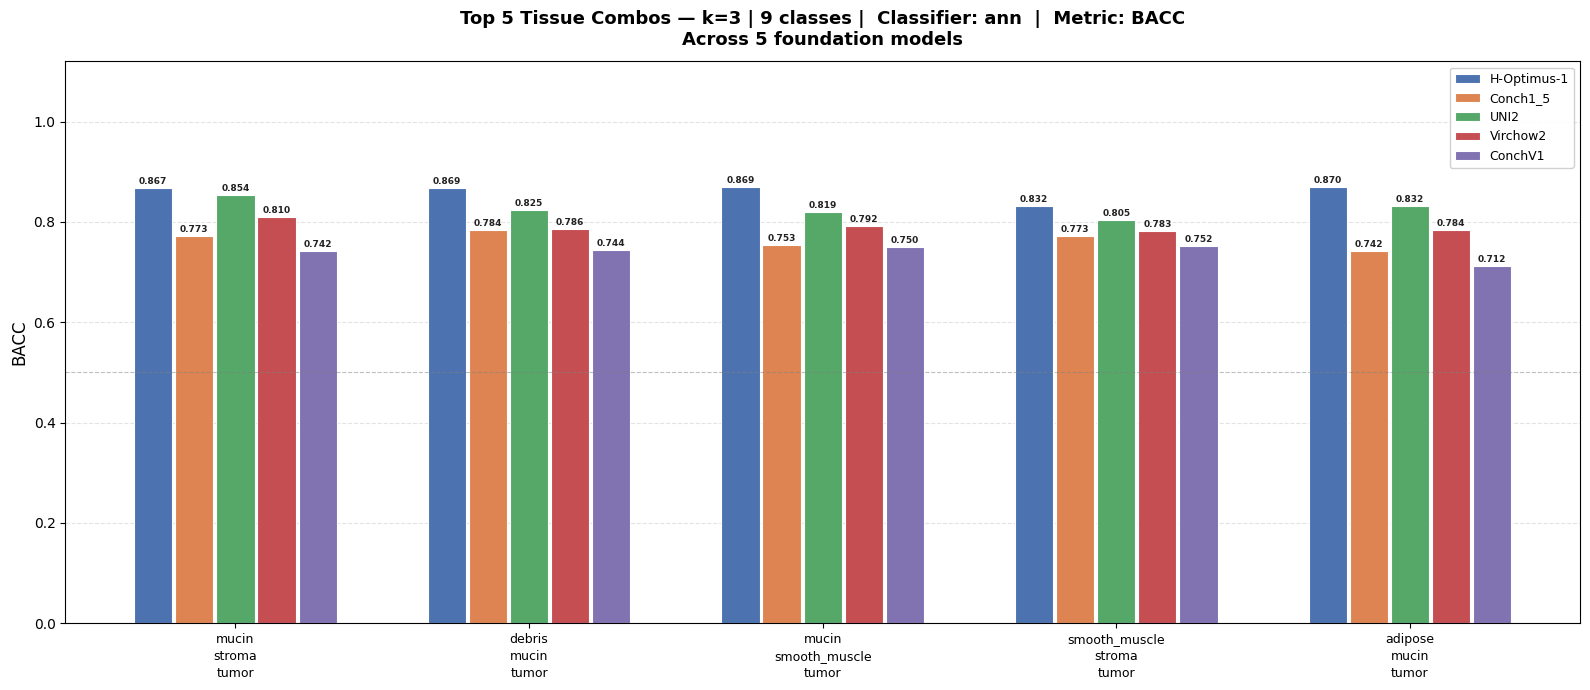

[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\by_model_k3.png


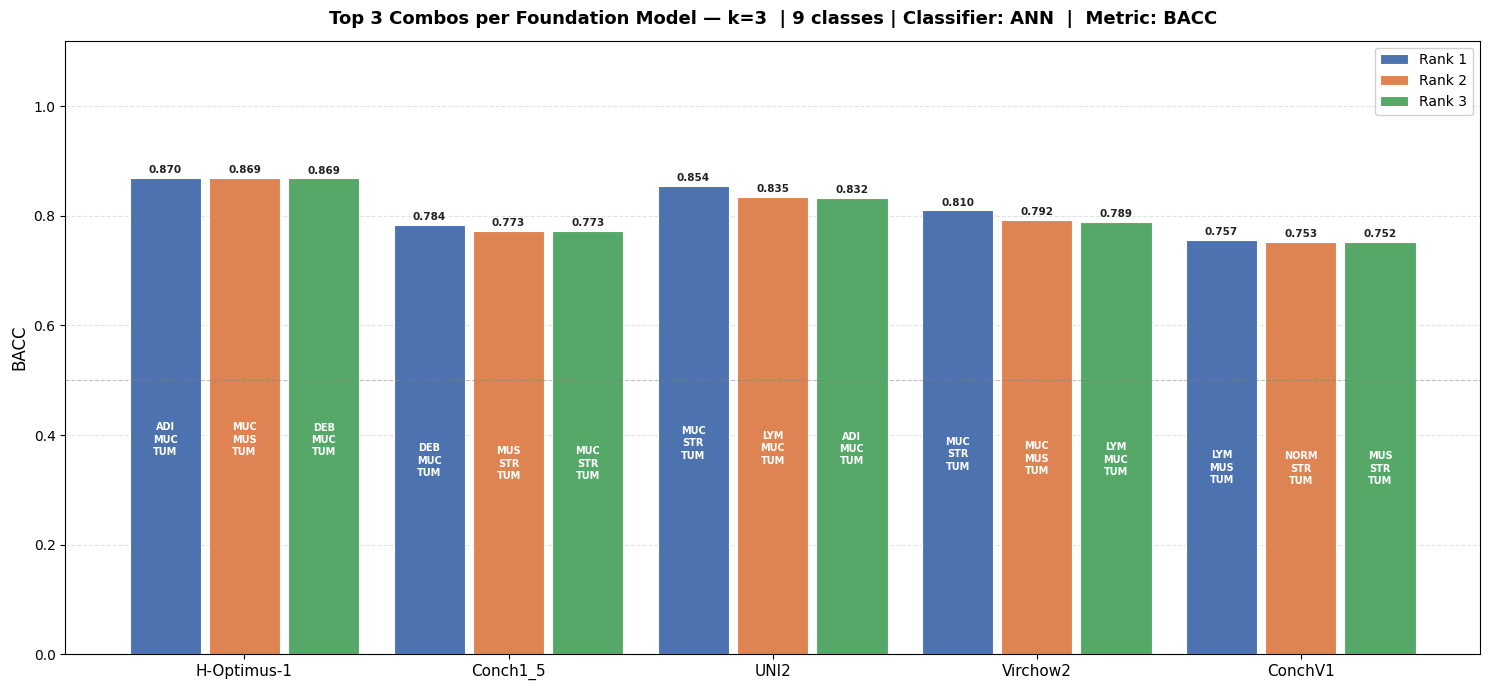

[OK] H-Optimus-1 k=5: 56 'ann' rows
[OK] Conch1_5 k=5: 40 'ann' rows
[OK] UNI2 k=5: 36 'ann' rows
[OK] Virchow2 k=5: 52 'ann' rows
[OK] ConchV1 k=5: 40 'ann' rows

Top 5 combos for k=5:
                                         combo  H-Optimus-1  Conch1_5     UNI2  Virchow2  ConchV1
       debris+mucin+smooth_muscle+stroma+tumor     0.868529  0.749779 0.819254  0.784333 0.749012
   lymphocyte+mucin+smooth_muscle+stroma+tumor     0.814515  0.760660 0.834799  0.777773 0.750751
             adipose+debris+mucin+stroma+tumor     0.828723  0.749936 0.801809  0.800336 0.746206
mucin+smooth_muscle+normal_mucosa+stroma+tumor     0.836570  0.744186 0.814040  0.776266 0.750631
  adipose+lymphocyte+mucin+smooth_muscle+tumor     0.853651  0.763303      NaN  0.770387 0.745367
[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\top5_combos_k5.png


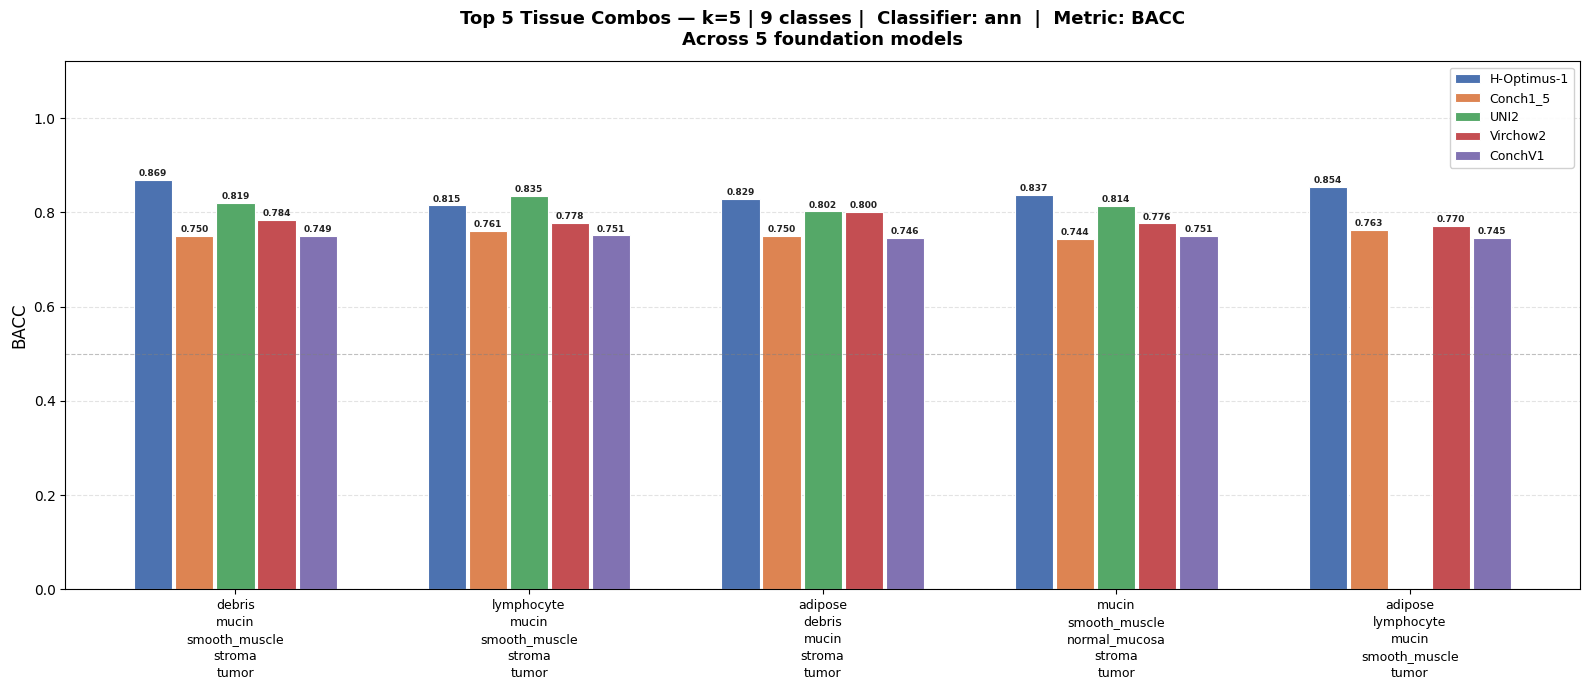

[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\by_model_k5.png


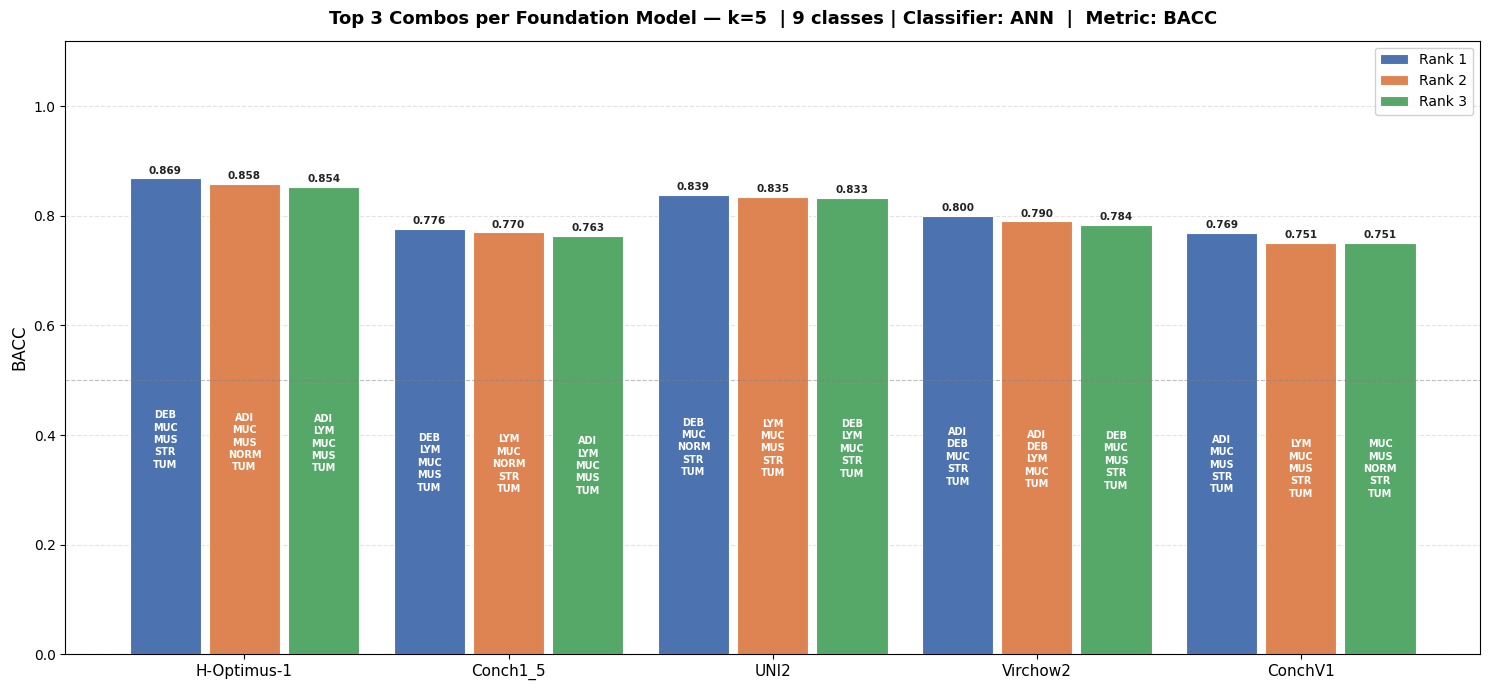

[OK] H-Optimus-1 k=8: 1 'ann' rows
[OK] Conch1_5 k=8: 1 'ann' rows
[OK] UNI2 k=8: 1 'ann' rows
[OK] Virchow2 k=8: 1 'ann' rows
[OK] ConchV1 k=8: 1 'ann' rows

Top 5 combos for k=8:
                                                                   combo  H-Optimus-1  Conch1_5     UNI2  Virchow2  ConchV1
adipose+debris+lymphocyte+mucin+smooth_muscle+normal_mucosa+stroma+tumor     0.779729  0.748912 0.801768  0.756601 0.732614
[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\top5_combos_k8.png


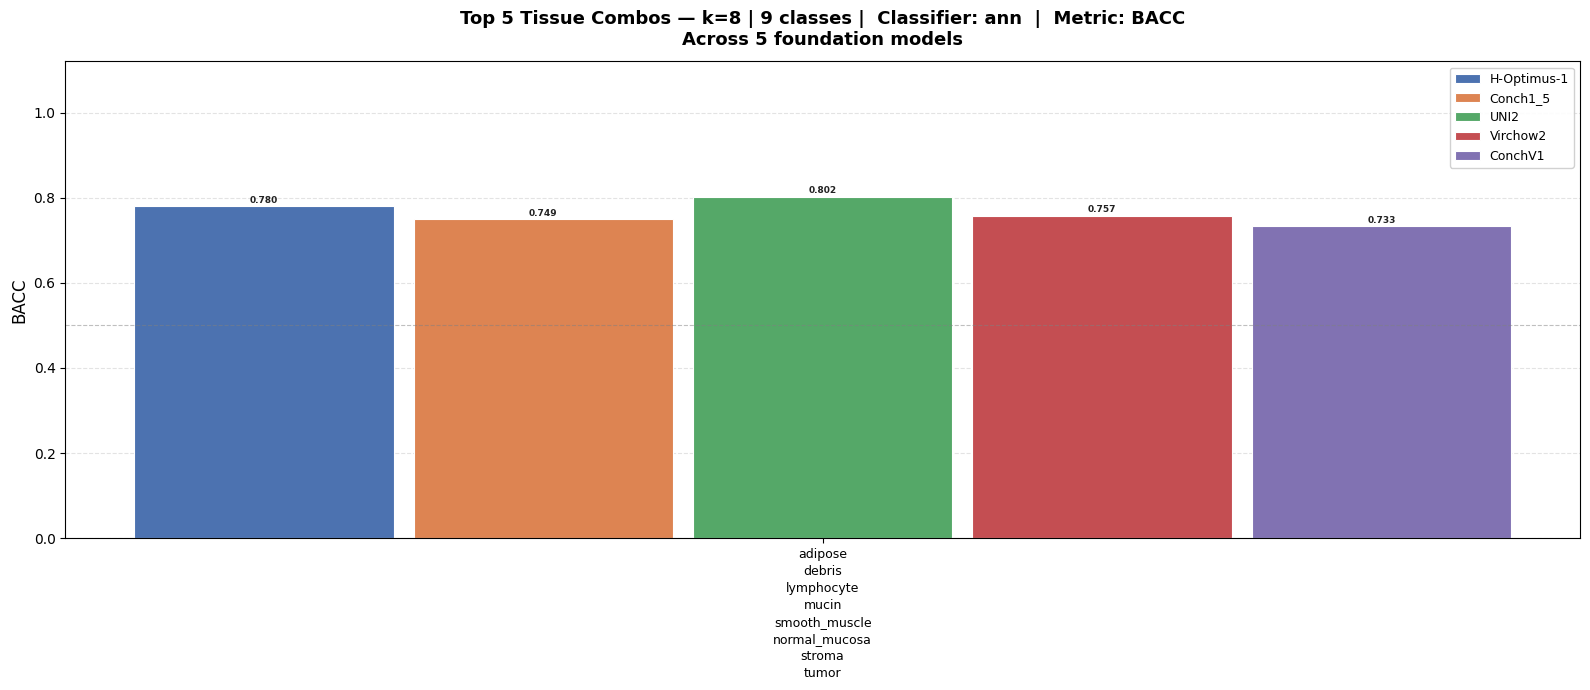

[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\by_model_k8.png


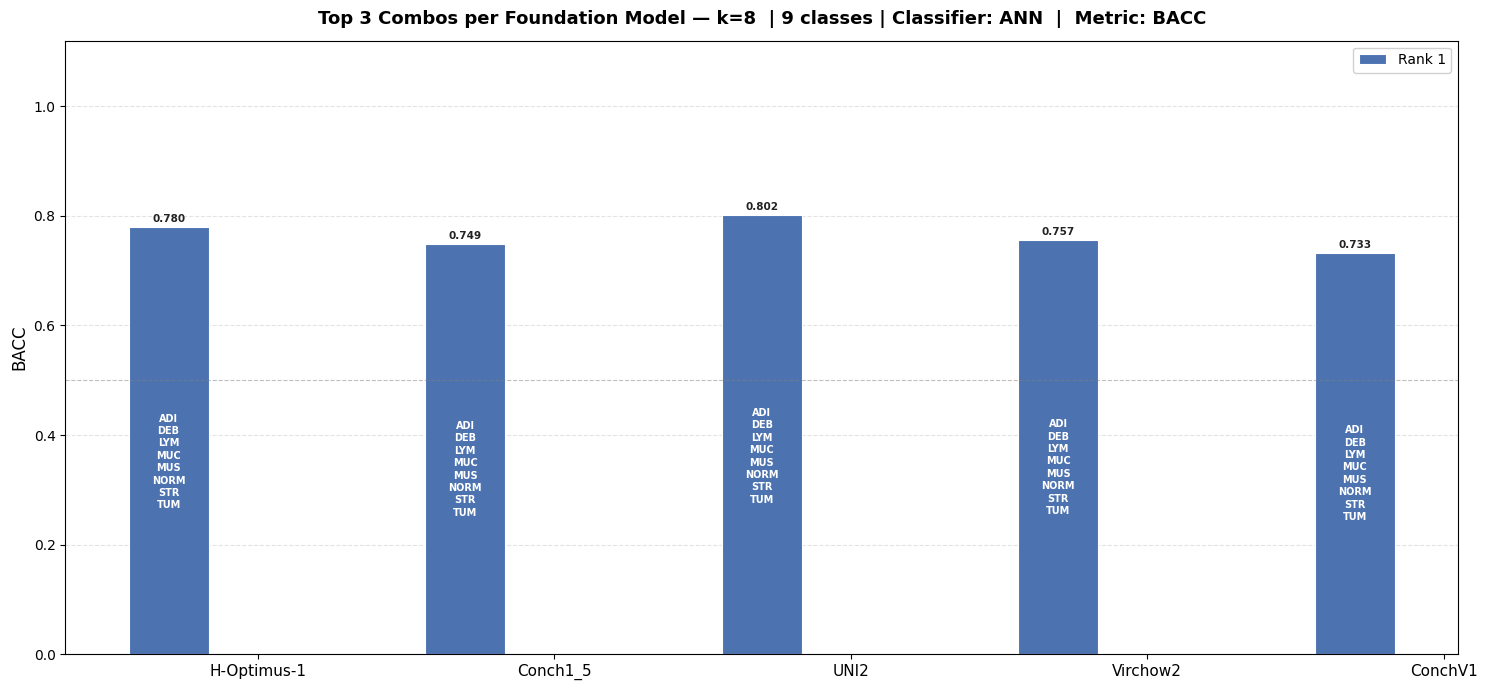

[OK] H-Optimus-1 k=3: 52 'ann' rows
[OK] Conch1_5 k=3: 36 'ann' rows
[OK] UNI2 k=3: 48 'ann' rows
[OK] Virchow2 k=3: 46 'ann' rows
[OK] ConchV1 k=3: 36 'ann' rows
[OK] H-Optimus-1 k=5: 56 'ann' rows
[OK] Conch1_5 k=5: 40 'ann' rows
[OK] UNI2 k=5: 36 'ann' rows
[OK] Virchow2 k=5: 52 'ann' rows
[OK] ConchV1 k=5: 40 'ann' rows
[OK] H-Optimus-1 k=8: 1 'ann' rows
[OK] Conch1_5 k=8: 1 'ann' rows
[OK] UNI2 k=8: 1 'ann' rows
[OK] Virchow2 k=8: 1 'ann' rows
[OK] ConchV1 k=8: 1 'ann' rows
[OK] k-comparison chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\k_comparison_best_combo.png


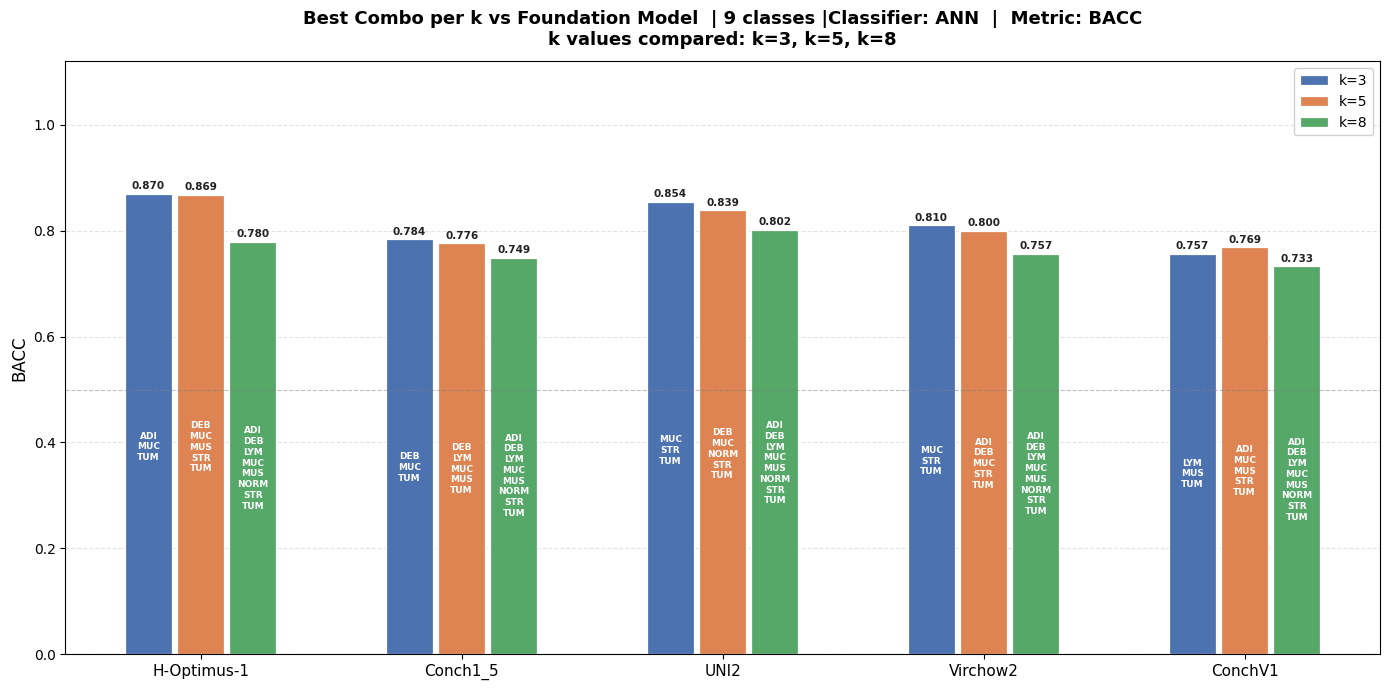

In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Configuration ────────────────────────────────────────────────────────────
BASE_UPDATED = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\TCGA_Results_Updated\Tissue_Type_Clustering"

MODEL_NAMES = [
    "H-Optimus-1",
    "Conch1_5",
    "UNI2",
    "Virchow2",
    "ConchV1"
]

SUBFOLDER = r"1-MSIH\Output"

# Classifier head to filter on — change to "lin", "ann", or "knn"
CLASSIFIER = "ann"

# Metric to rank combos by
RANK_METRIC = "bacc"

# K values used for the k-comparison chart
K_VALUES_COMPARE = [3, 5, 8]

# ── Tissue abbreviations ──────────────────────────────────────────────────────
TISSUE_ABBREV = {
    "adipose":       "ADI",
    "background":    "BACK",
    "debris":        "DEB",
    "lymphocyte":    "LYM",
    "mucin":         "MUC",
    "smooth_muscle": "MUS",
    "normal_mucosa": "NORM",
    "stroma":        "STR",
    "tumor":         "TUM",
}

def abbrev_combo(combo_str):
    parts = [p.strip() for p in combo_str.split("+") if p.strip()]
    return "\n".join(TISSUE_ABBREV.get(p, p) for p in parts)


# ── Load & filter data for a given k ─────────────────────────────────────────
def load_k(k_val):
    """
    Load tissue_combo_summary_k{k_val}.xlsx for all models.
    Filter rows where the 'model_type' column starts with CLASSIFIER (case-insensitive).
    Returns a combined dataframe with a model_name column, or None if nothing found.
    """
    frames = []
    fname = f"tissue_combo_summary_k{k_val}.xlsx"
    for model in MODEL_NAMES:
        path = os.path.join(BASE_UPDATED, model, SUBFOLDER, fname)
        if not os.path.exists(path):
            print(f"[WARN] Not found: {path}")
            continue
        df = pd.read_excel(path)
        if df.empty:
            print(f"[WARN] Empty: {path}")
            continue
        df["model_type"] = df["model_type"].astype(str)
        df_clf = df[df["model_type"].str.lower().str.startswith(CLASSIFIER.lower())].copy()
        if df_clf.empty:
            print(f"[WARN] No '{CLASSIFIER}' rows in {path}")
            continue
        df_clf.insert(0, "model_name", model)
        frames.append(df_clf)
        print(f"[OK] {model} k={k_val}: {len(df_clf)} '{CLASSIFIER}' rows")
    return pd.concat(frames, ignore_index=True) if frames else None


# ── Find top-5 combos by averaged metric across all foundation models ─────────
def top5_combos(df, metric=RANK_METRIC):
    """
    Average the metric across all foundation models for each combo.
    Returns a dataframe of top-5 combos with per-model values (no mean column).
    """
    pivot = (
        df.groupby(["combo", "model_name"])[metric]
        .mean()
        .unstack(fill_value=np.nan)
    )
    pivot["mean"] = pivot.mean(axis=1)
    top5 = pivot.nlargest(5, "mean").drop(columns=["mean"]).reset_index()
    return top5


# ── Plot: top-5 combos bar chart (no mean bar) ────────────────────────────────
def plot_top5(top5, k_val, metric=RANK_METRIC):
    """
    Grouped bar chart: top-5 combos × foundation models.
    Mean bar has been removed — each group shows one bar per model only.
    """
    n_combos = len(top5)
    # Only plot models that actually appear as columns in top5
    models_present = [m for m in MODEL_NAMES if m in top5.columns]
    n_models = len(models_present)

    bar_w = 0.14
    x     = np.arange(n_combos)
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

    fig, ax = plt.subplots(figsize=(16, 7))

    for ci, col in enumerate(models_present):
        offset = (ci - n_models / 2 + 0.5) * bar_w
        vals   = top5[col].values
        color  = palette[ci % len(palette)]

        for bi in range(n_combos):
            v = vals[bi]
            if np.isnan(v):
                continue
            ax.bar(x[bi] + offset, v, width=bar_w - 0.01,
                   color=color, edgecolor="white", linewidth=0.8,
                   label=col if bi == 0 else "")
            ax.text(x[bi] + offset, v + 0.004, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=6.5,
                    fontweight="bold", color="#222222")

    combo_labels = [
        "\n".join([p.strip() for p in c.split("+") if p.strip()])
        for c in top5["combo"]
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(combo_labels, fontsize=9, linespacing=1.4)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top 5 Tissue Combos — k={k_val} | 9 classes |  Classifier: {CLASSIFIER}  |  Metric: {metric.upper()}\n"
        f"Across {len(models_present)} foundation models",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=9,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), f"top5_combos_k{k_val}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()


# ── Plot: top-3 combos per foundation model ───────────────────────────────────
def plot_by_model(df, k_val, metric=RANK_METRIC, top_n=3):
    """
    For each foundation model: show the top-N combos as grouped bars.
    Combo abbreviation is printed inside the bar when the bar is tall enough.
    Produced for every k value that has data.
    """
    palette = ["#4C72B0", "#DD8452", "#55A868"]

    model_data = {}
    for model in MODEL_NAMES:
        sub = df[df["model_name"] == model]
        if sub.empty:
            continue
        top = (
            sub.groupby("combo")[metric]
            .mean()
            .nlargest(top_n)
            .reset_index()
        )
        model_data[model] = top

    models   = [m for m in MODEL_NAMES if m in model_data]
    n_models = len(models)
    if n_models == 0:
        print("[WARN] No data to plot.")
        return

    width   = 0.3
    offsets = np.linspace(-(top_n - 1) / 2, (top_n - 1) / 2, top_n) * width
    x       = np.arange(n_models)

    fig, ax = plt.subplots(figsize=(15, 7))

    for ci in range(top_n):
        color = palette[ci % len(palette)]
        for mi, model in enumerate(models):
            top = model_data[model]
            if ci >= len(top):
                continue
            row   = top.iloc[ci]
            val   = row[metric]
            combo = row["combo"]
            xpos  = x[mi] + offsets[ci]

            ax.bar(xpos, val, width=width - 0.03,
                   color=color, edgecolor="white", linewidth=0.8,
                   label=f"Rank {ci + 1}" if mi == 0 else "")

            ax.text(xpos, val + 0.005, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold", color="#222222")

            if val > 0.08:
                ax.text(xpos, val * 0.45, abbrev_combo(combo),
                        ha="center", va="center",
                        fontsize=7, color="white", fontweight="bold",
                        linespacing=1.3, clip_on=True,
                        multialignment="center")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top {top_n} Combos per Foundation Model — k={k_val}  | 9 classes | "
        f"Classifier: {CLASSIFIER.upper()}  |  Metric: {metric.upper()}",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=10,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), f"by_model_k{k_val}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()


# ── Plot: best-of-k comparison across foundation models ──────────────────────
def plot_k_comparison(k_values, metric=RANK_METRIC):
    """
    For each foundation model (x-axis), plot one bar per k value showing
    the single best combo score for that (model, k) pair.
    Combo abbreviation is printed inside the bar.

    Only k values whose Excel file exists for at least one model are included.
    """
    # Palette: one colour per k value
    k_palette = {
        3: "#4C72B0",   # blue
        5: "#DD8452",   # orange
        8: "#55A868",   # green
    }
    # Fallback colours if someone passes extra k values
    extra_colours = ["#C44E52", "#8172B2", "#2d2d2d"]

    # ── Gather best score + best combo per (model, k) ─────────────────────
    # Structure: best_data[k][model] = {"score": float, "combo": str}
    best_data: dict = {}
    k_loaded: list  = []

    for k_val in k_values:
        df = load_k(k_val)
        if df is None:
            print(f"[WARN] No data for k={k_val} — skipped in comparison chart.")
            continue
        k_loaded.append(k_val)
        best_data[k_val] = {}

        for model in MODEL_NAMES:
            sub = df[df["model_name"] == model]
            if sub.empty:
                continue
            # Best single combo for this model at this k
            best_row = (
                sub.groupby("combo")[metric]
                .mean()
                .idxmax()
            )
            best_score = sub.groupby("combo")[metric].mean().max()
            best_data[k_val][model] = {"score": best_score, "combo": best_row}

    if not k_loaded:
        print("[WARN] No k values had data — skipping comparison chart.")
        return

    # ── Build palette (supports arbitrary k lists) ─────────────────────────
    colour_map = {}
    extra_idx  = 0
    for k_val in k_loaded:
        if k_val in k_palette:
            colour_map[k_val] = k_palette[k_val]
        else:
            colour_map[k_val] = extra_colours[extra_idx % len(extra_colours)]
            extra_idx += 1

    n_k      = len(k_loaded)
    n_models = len(MODEL_NAMES)
    bar_w    = 0.20
    x        = np.arange(n_models)
    offsets  = np.linspace(-(n_k - 1) / 2, (n_k - 1) / 2, n_k) * bar_w

    fig, ax = plt.subplots(figsize=(max(14, n_models * 2.2), 7))

    for ki, k_val in enumerate(k_loaded):
        colour = colour_map[k_val]
        offset = offsets[ki]

        for mi, model in enumerate(MODEL_NAMES):
            entry = best_data[k_val].get(model)
            if entry is None:
                continue

            score = entry["score"]
            combo = entry["combo"]
            xpos  = x[mi] + offset

            ax.bar(xpos, score, width=bar_w - 0.02,
                   color=colour, edgecolor="white", linewidth=0.9,
                   label=f"k={k_val}" if mi == 0 else "")

            # Value label above bar
            ax.text(xpos, score + 0.005, f"{score:.3f}",
                    ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold", color="#222222")

            # Combo abbreviation inside bar (only if bar is tall enough)
            if score > 0.10:
                ax.text(xpos, score * 0.45, abbrev_combo(combo),
                        ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold",
                        linespacing=1.25, clip_on=True,
                        multialignment="center")

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Best Combo per k vs Foundation Model  | 9 classes |"
        f"Classifier: {CLASSIFIER.upper()}  |  Metric: {metric.upper()}\n"
        f"k values compared: {', '.join(f'k={k}' for k in k_loaded)}",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=10,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), "k_comparison_best_combo.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] k-comparison chart saved → {out_path}")
    plt.show()


# ── Main ──────────────────────────────────────────────────────────────────────
# Chart 1 & 2: top-5 combos + top-3 per model, for every k that has data
for k in [3, 5, 8]:
    df = load_k(k)
    if df is None:
        print(f"[WARN] No data for k={k}, skipping per-k charts.")
        continue
    top5 = top5_combos(df, RANK_METRIC)
    print(f"\nTop 5 combos for k={k}:")
    print(top5[["combo"] + [m for m in MODEL_NAMES if m in top5.columns]].to_string(index=False))
    plot_top5(top5, k)       # top-5 across all models (no mean bar)
    plot_by_model(df, k)     # top-3 per foundation model

# Chart 3: k-comparison (best single combo per model per k)
plot_k_comparison(K_VALUES_COMPARE)

## Method 2 : Only take best k

In [5]:
"""
tissue_combination_search_9cls.py
─────────────────────────────────────────────────────────────────────────────
Runs two phases of experiments for Tissue_Type_Clustering features (9 classes).

  Phase 1 — Individual class evaluation (global, across all foundation models)
      Tests each of the 8 active tissue classes (background excluded) in
      isolation (1×N vector) across every foundation model in one combined pass.
      Each class gets a bacc column per foundation model.
      A final 'avg_bacc' column averages across models and produces a global
      class ranking.
      Results saved to: …/Global/<task>/tissue_individual_class_results_9_global.xlsx

  Phase 2 — Fixed top-k combo evaluation
      For each k in k_values, selects the globally top-k tissue classes by
      avg_bacc and runs that single fixed combination across all foundation
      models. No exhaustive combination search.
      Results saved to: …/Global/<task>/tissue_topk_summary_9cls_k{k}.xlsx

  Model saving
      One best model is kept per (foundation model, k value).
      Saved to: …/models/best_{k}labels_TTC/
      All intermediate checkpoints are deleted immediately after each run.
"""

import os
import gc
import shutil
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from itertools import product as iproduct

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

MODEL_NAMES = ["H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"]

MODEL_BASE_DIMS = {
    "H-Optimus-1": 1536,
    "UNI2":        1536,
    "Conch1_5":     768,
    "Virchow2":    2560,
    "ConchV1":      512,
}

TASK_PREFIXES = {
    "MSIH": "1-MSIH",
    "BRAF": "2-BRAF",
    "KRAS": "3-KRAS",
    "TP53": "4-TP53",
    "CIMP": "5-CIMP",
}

TASK_FOLD_CONFIG = {
    "MSIH": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\kfolds_IDARS_fixed.csv",
             "label_desc",    "nonMSIH"),
    "BRAF": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_BRAF.csv",
             "BRAF_mutation", "WT"),
    "KRAS": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_KRAS.csv",
             "KRAS_mutation", "WT"),
    "TP53": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_TP53.csv",
             "TP53_mutation", "WT"),
    "CIMP": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_CIMP.csv",
             "CIMP",          "neg"),
}

TISSUE_CLASS_NAMES = [
    "adipose",       # 0
    "background",    # 1  — excluded from all experiments
    "debris",        # 2
    "lymphocyte",    # 3
    "mucin",         # 4
    "smooth_muscle", # 5
    "normal_mucosa", # 6
    "stroma",        # 7
    "tumor",         # 8
]
NUM_TISSUE_CLASSES = 9          # total rows in each .pt tensor (do not change)

# Background is meaningless for classification — exclude it everywhere.
# NUM_TISSUE_CLASSES stays 9 because the .pt files still have 9 rows;
# ACTIVE_CLASS_INDICES is the only list passed as row_indices to the dataset.
BACKGROUND_IDX       = TISSUE_CLASS_NAMES.index("background")   # → 1
ACTIVE_CLASS_INDICES = [i for i in range(NUM_TISSUE_CLASSES) if i != BACKGROUND_IDX]
NUM_ACTIVE_CLASSES   = len(ACTIVE_CLASS_INDICES)                 # → 8

BATCH_SIZE  = 4
task_names  = ["MSIH"]
model_types = ["ann"]  # "lin", "ann", "knn", "proto", "rf"
k_values    = [3, 5, 7, 8]   # fixed top-k sizes for Phase 2 (max = NUM_ACTIVE_CLASSES)
rank_by     = "bacc"

RESULT_FOLDER      = "TCGA_Results_Updated"
BASE_ROOT          = r"D:\Aamir Gulzar\KSA_project2"
PROJECT_ROOT       = os.path.join(BASE_ROOT, "Cancer-detection-classifier", "slide_classification")
AGGREGATION_METHOD = "Tissue_Type_Clustering"
sheet_name         = "tissue_search"


# ─────────────────────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────────────────────

class TissueCombinationDataset(Dataset):
    """
    Loads flattened (num_classes × feature_dim) .pt tensors and exposes
    only the rows listed in `row_indices`, re-flattened to (k × feature_dim).
    """

    def __init__(
        self,
        save_dir:     str,
        fold_ids:     List[str],
        row_indices:  List[int],
        num_classes:  int,
        feature_dim:  int,
        label_col:    str,
        neg_value:    str,
        k_folds_path: str,
    ):
        self.save_dir    = save_dir
        self.fold_ids    = set(fold_ids)
        self.row_indices = row_indices
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.label_col   = label_col
        self.neg_value   = neg_value

        folds_df      = pd.read_csv(k_folds_path)
        self.folds_df = folds_df.set_index("WSI_Id")

        self.data: List[Tuple[torch.Tensor, int, str]] = []
        self._load()

    def _load(self):
        expected_len = self.num_classes * self.feature_dim

        for fname in os.listdir(self.save_dir):
            if not fname.endswith(".pt"):
                continue
            wsi_id = os.path.splitext(fname)[0]
            if wsi_id not in self.fold_ids:
                continue
            if wsi_id not in self.folds_df.index:
                continue

            try:
                feats = torch.load(
                    os.path.join(self.save_dir, fname), map_location="cpu"
                )
                flat = feats.cpu().flatten()

                if flat.numel() != expected_len:
                    print(f"[WARN] {fname}: expected {expected_len} elements, "
                          f"got {flat.numel()}. Skipping.")
                    continue

                matrix   = flat.view(self.num_classes, self.feature_dim)
                selected = matrix[self.row_indices].flatten()

                raw   = self.folds_df.at[wsi_id, self.label_col]
                label = 0 if raw == self.neg_value else 1

                self.data.append((selected, label, wsi_id))

            except Exception as exc:
                print(f"[ERROR] {fname}: {exc}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        feats, label, wsi_id = self.data[idx]
        return feats, label, wsi_id


# ─────────────────────────────────────────────────────────────────────────────
# MODEL SAVING HELPERS
# ─────────────────────────────────────────────────────────────────────────────

class BestModelTracker:
    """
    Tracks the single best model checkpoint for one (foundation model, k) pair.
    Deletes any checkpoint that is not the current best immediately.
    Call .cleanup(keep_dir) at the end to move the winner to its final location.
    """

    def __init__(self, label: str):
        self.label      = label
        self.best_score = -1.0
        self.best_path: Optional[str] = None

    def update(self, score: float, candidate_path: Optional[str]) -> bool:
        if score <= self.best_score:
            if candidate_path and os.path.exists(candidate_path):
                try:
                    os.remove(candidate_path)
                except OSError:
                    pass
            return False

        if self.best_path and os.path.exists(self.best_path):
            try:
                os.remove(self.best_path)
            except OSError:
                pass

        self.best_score = score
        self.best_path  = candidate_path
        return True

    def cleanup(self, keep_dir: str):
        if self.best_path and os.path.exists(self.best_path):
            os.makedirs(keep_dir, exist_ok=True)
            dest = os.path.join(
                keep_dir,
                f"best_{self.label}_{rank_by}{self.best_score:.4f}.pt",
            )
            shutil.copy2(self.best_path, dest)
            try:
                os.remove(self.best_path)
            except OSError:
                pass
            print(f"  ✓ Best model saved → {dest}")
        else:
            print(f"  [WARN] No best model found for {self.label} — nothing saved.")


def _temp_model_dir(output_save_path: str, label: str) -> str:
    """Scratch directory for a single combo's intermediate checkpoints."""
    d = os.path.join(
        output_save_path, "_tmp_models", label.replace("+", "_")
    )
    os.makedirs(d, exist_ok=True)
    return d


def _cleanup_temp_dir(output_save_path: str):
    tmp = os.path.join(output_save_path, "_tmp_models")
    if os.path.isdir(tmp):
        shutil.rmtree(tmp, ignore_errors=True)


# ─────────────────────────────────────────────────────────────────────────────
# K-FOLD RUNNER  (single combo × single model type)
# ─────────────────────────────────────────────────────────────────────────────

def _run_one_combo_kfold(
    task_name:       str,
    data_path:       str,
    k_folds_path:    str,
    folds:           List[List[str]],
    row_indices:     List[int],
    num_classes:     int,
    feature_dim:     int,
    model_type:      str,
    model_save_path: str,
    label_col:       str,
    neg_value:       str,
    tracker:         BestModelTracker,
) -> List[Dict[str, Any]]:
    """
    Runs k-fold CV for one (combo, model_type) pair.
    Calls eval_* functions that must be in scope (imported from your utils).
    Updates `tracker` after every fold.
    """
    vector_dim       = len(row_indices) * feature_dim
    metric_key       = f"{model_type}_macro_f1"
    results_per_fold = []
    num_folds        = len(folds)

    for i in range(num_folds):
        test_ids  = folds[i]
        val_ids   = folds[(i + 1) % num_folds]
        train_ids = [
            wsi_id
            for j, fold in enumerate(folds)
            if j != i and j != (i + 1) % num_folds
            for wsi_id in fold
        ]

        def make_loader(ids, shuffle):
            ds = TissueCombinationDataset(
                save_dir     = data_path,
                fold_ids     = ids,
                row_indices  = row_indices,
                num_classes  = num_classes,
                feature_dim  = feature_dim,
                label_col    = label_col,
                neg_value    = neg_value,
                k_folds_path = k_folds_path,
            )
            if len(ds) == 0:
                raise ValueError(
                    f"Empty dataset for fold {i+1} — "
                    f"check WSI IDs vs files in {data_path}"
                )
            return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

        train_loader = make_loader(train_ids, shuffle=True)
        val_loader   = make_loader(val_ids,   shuffle=False)
        test_loader  = make_loader(test_ids,  shuffle=False)

        def collect(loader):
            feats, labels, ids = [], [], []
            for f, l, w in loader:
                feats.append(f)
                labels.append(l)
                ids.extend(w if isinstance(w, (list, tuple)) else [w])
            return torch.cat(feats), torch.cat(labels), ids

        tr_f, tr_l, _            = collect(train_loader)
        va_f, va_l, _            = collect(val_loader)
        te_f, te_l, test_ids_out = collect(test_loader)

        best_metrics, best_dump, best_params = None, None, None
        last_saved_path = None

        if model_type == "lin":
            for C, max_iter in iproduct([10], [300]):
                m, d = eval_linear(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    max_iter=max_iter, save_path=model_save_path,
                    C=C, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"lin_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (C, max_iter)

        elif model_type == "ann":
            for h1, h2, max_iter in iproduct([128, 256], [64, 128], [500]):
                m, d = eval_ANN(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    input_dim=vector_dim, hidden_dim=h1, hidden_dim2=h2,
                    max_iter=max_iter, model_save_path=model_save_path,
                    verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"ann_fold{i}.pt")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (h1, h2, max_iter)

        elif model_type == "knn":
            for k_n in [3]:
                m, d = eval_knn(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    val_feats=va_f,   val_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_neighbors=k_n, normalize_feats=True,
                    model_save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"knn_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, k_n

        elif model_type == "proto":
            best_metrics, best_dump = eval_protonet(
                fold=i, train_feats=tr_f, train_labels=tr_l,
                val_feats=va_f, val_labels=va_l,
                test_feats=te_f, test_labels=te_l,
                normalize_feats=True, model_save_path=model_save_path,
            )
            last_saved_path = os.path.join(model_save_path, f"proto_fold{i}.pt")
            best_params = None

        elif model_type == "rf":
            for n_est, max_d, min_split, min_leaf, cw, thresh in iproduct(
                [500], [None], [5], [1], [{0: 1, 1: 10}], [0.3]
            ):
                m, d = eval_r_forest(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_estimators=n_est, max_depth=max_d,
                    min_samples_split=min_split, min_samples_leaf=min_leaf,
                    class_weight=cw, prediction_threshold=thresh,
                    save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"rf_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (
                        n_est, max_d, min_split, min_leaf, cw, thresh)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

        fold_score = best_metrics.get(f"{model_type}_{rank_by}", 0.0)
        tracker.update(fold_score, last_saved_path)

        if best_params:
            print(f"  Fold {i+1} | {model_type} best params: {best_params} | "
                  f"{rank_by}={fold_score:.4f}")

        results_per_fold.append({
            **best_metrics,
            **best_dump,
            "wsi_ids": test_ids_out,
            "fold":    i + 1,
        })

    return results_per_fold


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — individual class evaluation (global, across all foundation models)
# ─────────────────────────────────────────────────────────────────────────────

def run_phase1_individual_classes(
    task_name:          str,
    all_model_configs:  List[Dict],   # list of dicts: model_name, data_path, feature_dim, output_save_path
    k_folds_path:       str,
    folds:              List[List[str]],
    label_col:          str,
    neg_value:          str,
    global_output_path: str,          # where to write the combined Phase 1 xlsx
) -> pd.DataFrame:
    """
    Runs Phase 1 (individual class evaluation) across ALL foundation models in
    one pass. Only the 8 active classes are evaluated (background is skipped).
    Each class gets a bacc column per foundation model. A final 'avg_bacc'
    column averages across models and is used to rank classes globally.

    Returns a DataFrame sorted by avg_bacc descending — used by Phase 2 to pick
    the top-k fixed combo.
    """
    print(f"\n{'─'*60}")
    print(f"  PHASE 1 — Individual class evaluation "
          f"({NUM_ACTIVE_CLASSES} active classes, background excluded, all models)")
    print(f"  Task: {task_name}")
    print(f"{'─'*60}")

    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}

    # Initialise result rows — one per ACTIVE class only
    rows = [
        {"class_idx": i, "class_name": TISSUE_CLASS_NAMES[i]}
        for i in ACTIVE_CLASS_INDICES
    ]
    # Map class_idx → position in rows list for fast lookup
    idx_to_row = {i: pos for pos, i in enumerate(ACTIVE_CLASS_INDICES)}

    for cfg in all_model_configs:
        model_name       = cfg["model_name"]
        data_path        = cfg["data_path"]
        feature_dim      = cfg["feature_dim"]
        output_save_path = cfg["output_save_path"]

        print(f"\n  ── Model: {model_name} ──")

        for class_idx in ACTIVE_CLASS_INDICES:
            class_name = TISSUE_CLASS_NAMES[class_idx]
            print(f"    Class {class_idx}: {class_name}")

            model_save_path = _temp_model_dir(output_save_path, f"p1_{class_name}")
            tracker = BestModelTracker(f"{model_name}_phase1_{class_name}")

            bacc_vals = []
            for model_type in model_types:
                try:
                    fold_results = _run_one_combo_kfold(
                        task_name       = task_name,
                        data_path       = data_path,
                        k_folds_path    = k_folds_path,
                        folds           = folds,
                        row_indices     = [class_idx],
                        num_classes     = NUM_TISSUE_CLASSES,
                        feature_dim     = feature_dim,
                        model_type      = model_type,
                        model_save_path = model_save_path,
                        label_col       = label_col,
                        neg_value       = neg_value,
                        tracker         = tracker,
                    )

                    avg = calculate_metric_averages(
                        [{k: v for k, v in r.items()
                          if k in [f"{model_type}_{m}" for m in metric_indices]}
                         for r in fold_results],
                        metric_indices,
                        model_prefix=model_type,
                    )
                    b = avg.get(f"{model_type}_bacc", float("nan"))
                    bacc_vals.append(b)

                    # Store per-metric results keyed by foundation model + classifier
                    for m in metric_indices:
                        col = f"{model_name}_{model_type}_{m}"
                        rows[idx_to_row[class_idx]][col] = avg.get(f"{model_type}_{m}", float("nan"))

                except Exception as exc:
                    print(f"      [ERROR] {model_type}: {exc}")
                    for m in metric_indices:
                        rows[idx_to_row[class_idx]][f"{model_name}_{model_type}_{m}"] = float("nan")

            # Best bacc for this model (across classifier variants)
            valid = [v for v in bacc_vals if not np.isnan(v)]
            rows[idx_to_row[class_idx]][f"{model_name}_bacc"] = (
                max(valid) if valid else float("nan")
            )

        _cleanup_temp_dir(output_save_path)

    # Compute average bacc across foundation models
    bacc_cols = [f"{cfg['model_name']}_bacc" for cfg in all_model_configs]
    df = pd.DataFrame(rows)
    df["avg_bacc"] = df[bacc_cols].mean(axis=1, skipna=True)
    df = df.sort_values("avg_bacc", ascending=False).reset_index(drop=True)
    df["global_rank"] = df.index + 1

    print(f"\n  Global class ranking by avg_bacc:")
    for _, row in df.iterrows():
        print(f"    #{int(row['global_rank']):2d}  {row['class_name']:<22s}  avg_bacc={row['avg_bacc']:.4f}")

    os.makedirs(global_output_path, exist_ok=True)
    out_path = os.path.join(global_output_path, "tissue_individual_class_results_9_global.xlsx")
    write_data_in_excel(out_path, df, sheet_name="individual_classes_9")
    print(f"\n  ✓ Phase 1 global results → {out_path}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — fixed top-k combo evaluation (9 classes)
# ─────────────────────────────────────────────────────────────────────────────

def run_phase2_topk_combo(
    task_name:          str,
    all_model_configs:  List[Dict],
    k_folds_path:       str,
    folds:              List[List[str]],
    label_col:          str,
    neg_value:          str,
    class_df:           pd.DataFrame,   # output of Phase 1, sorted by avg_bacc desc
    global_output_path: str,
):
    """
    For each k value, selects the globally top-k tissue classes (by avg_bacc)
    and trains/evaluates that single fixed combination across all foundation
    models. Writes one summary xlsx per k containing all model results.
    """
    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}

    ranked_df = class_df.sort_values("avg_bacc", ascending=False).reset_index(drop=True)

    for k in k_values:
        if k > NUM_ACTIVE_CLASSES:
            print(f"  [WARN] k={k} exceeds number of active classes ({NUM_ACTIVE_CLASSES}), skipping.")
            continue

        top_k_rows  = ranked_df.head(k)
        row_indices = top_k_rows["class_idx"].tolist()
        combo_label = "+".join(TISSUE_CLASS_NAMES[i] for i in row_indices)
        combo_baccs = top_k_rows["avg_bacc"].tolist()

        print(f"\n{'─'*60}")
        print(f"  PHASE 2 — k={k} | Fixed top-{k} combo")
        print(f"  Combo : {combo_label}")
        print(f"  Avg bacc of selected classes: "
              + ", ".join(f"{b:.4f}" for b in combo_baccs))
        print(f"{'─'*60}")

        summary_rows: List[Dict] = []
        best_combo_probs: Optional[pd.DataFrame] = None

        for cfg in all_model_configs:
            model_name       = cfg["model_name"]
            data_path        = cfg["data_path"]
            feature_dim      = cfg["feature_dim"]
            output_save_path = cfg["output_save_path"]
            models_root_dir  = cfg["models_root_dir"]

            k_best_dir = os.path.join(models_root_dir, f"best_{k}labels_TTC")
            os.makedirs(k_best_dir, exist_ok=True)

            print(f"\n  Model: {model_name}")

            k_tracker       = BestModelTracker(f"{model_name}_9cls_k{k}")
            model_save_path = _temp_model_dir(output_save_path, combo_label)
            combo_probs_df: Optional[pd.DataFrame] = None

            for model_type in model_types:
                try:
                    fold_results = _run_one_combo_kfold(
                        task_name       = task_name,
                        data_path       = data_path,
                        k_folds_path    = k_folds_path,
                        folds           = folds,
                        row_indices     = row_indices,
                        num_classes     = NUM_TISSUE_CLASSES,
                        feature_dim     = feature_dim,
                        model_type      = model_type,
                        model_save_path = model_save_path,
                        label_col       = label_col,
                        neg_value       = neg_value,
                        tracker         = k_tracker,
                    )

                    model_df = build_probs_df(fold_results, model_name=model_type)
                    combo_probs_df = (
                        model_df if combo_probs_df is None
                        else pd.merge(combo_probs_df, model_df,
                                      on=["Fold", "WSI_ID", "Target"], how="outer")
                    )

                    avg = calculate_metric_averages(
                        [{key: v for key, v in r.items()
                          if key in [f"{model_type}_{m}" for m in metric_indices]}
                         for r in fold_results],
                        metric_indices,
                        model_prefix=model_type,
                    )

                    summary_rows.append({
                        "foundation_model": model_name,
                        "combo":            combo_label,
                        "row_indices":      str(row_indices),
                        "k":                k,
                        "classifier":       model_type,
                        **{m: avg.get(f"{model_type}_{m}", float("nan"))
                           for m in metric_indices},
                    })

                    print(f"    {model_type}: bacc={avg.get(f'{model_type}_bacc', float('nan')):.4f}  "
                          f"macro_f1={avg.get(f'{model_type}_macro_f1', float('nan')):.4f}")

                except Exception as exc:
                    print(f"    [ERROR] {model_type}: {exc}")

            if combo_probs_df is not None and best_combo_probs is None:
                best_combo_probs = combo_probs_df.copy()

            if os.path.isdir(model_save_path):
                shutil.rmtree(model_save_path, ignore_errors=True)

            k_tracker.cleanup(keep_dir=k_best_dir)
            gc.collect()

        # Write summary for this k — rows are all foundation models × classifiers
        summary_df   = pd.DataFrame(summary_rows)
        summary_path = os.path.join(
            global_output_path, f"tissue_topk_summary_9cls_k{k}.xlsx"
        )
        write_data_in_excel(summary_path, summary_df, sheet_name=f"k{k}")
        print(f"\n  ✓ Summary k={k} → {summary_path}")
        print(f"  Combo: {combo_label}")

        if best_combo_probs is not None:
            probs_path = os.path.join(
                global_output_path, f"tissue_topk_probs_9cls_k{k}.xlsx"
            )
            write_data_in_excel(probs_path, best_combo_probs,
                                sheet_name=f"k{k}_probs")
            print(f"  Probs → {probs_path}")

    _cleanup_temp_dir(global_output_path)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────

for task_name in task_names:
    folder_task_name = TASK_PREFIXES.get(task_name, task_name)

    # Build config list for all foundation models
    all_model_configs = []
    for MODEL_NAME in MODEL_NAMES:
        feature_dim      = MODEL_BASE_DIMS[MODEL_NAME]
        DATA_PATH        = os.path.join(
            BASE_ROOT, "dataset", "slide_aggregation", AGGREGATION_METHOD, MODEL_NAME
        )
        RESULT_ROOT      = os.path.join(
            PROJECT_ROOT, RESULT_FOLDER, AGGREGATION_METHOD, MODEL_NAME
        )
        OUTPUT_SAVE_PATH = os.path.join(RESULT_ROOT, folder_task_name, "Output")
        MODELS_ROOT_DIR  = os.path.join(RESULT_ROOT, folder_task_name, "models")
        os.makedirs(OUTPUT_SAVE_PATH, exist_ok=True)
        os.makedirs(MODELS_ROOT_DIR,  exist_ok=True)

        all_model_configs.append({
            "model_name":       MODEL_NAME,
            "data_path":        DATA_PATH,
            "feature_dim":      feature_dim,
            "output_save_path": OUTPUT_SAVE_PATH,
            "models_root_dir":  MODELS_ROOT_DIR,
        })

    # Shared fold config
    k_folds_path, label_col, neg_value = TASK_FOLD_CONFIG[task_name]
    folds_df = pd.read_csv(k_folds_path)
    folds: List[List[str]] = [
        folds_df[folds_df["fold"] == fn]["WSI_Id"].tolist()
        for fn in sorted(folds_df["fold"].unique())
    ]

    # Global output path — one level above any single model's folder
    GLOBAL_OUTPUT = os.path.join(
        PROJECT_ROOT, RESULT_FOLDER,
        AGGREGATION_METHOD, "Global", folder_task_name
    )
    os.makedirs(GLOBAL_OUTPUT, exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  Task: {task_name} | 8-class TTC (background excluded) | Models: {MODEL_NAMES}")
    print(f"{'='*70}")

    # Phase 1 — evaluate all 8 active classes across all models; get global ranking
    class_df = run_phase1_individual_classes(
        task_name          = task_name,
        all_model_configs  = all_model_configs,
        k_folds_path       = k_folds_path,
        folds              = folds,
        label_col          = label_col,
        neg_value          = neg_value,
        global_output_path = GLOBAL_OUTPUT,
    )

    # Phase 2 — test single top-k combo per k value, across all models
    run_phase2_topk_combo(
        task_name          = task_name,
        all_model_configs  = all_model_configs,
        k_folds_path       = k_folds_path,
        folds              = folds,
        label_col          = label_col,
        neg_value          = neg_value,
        class_df           = class_df,
        global_output_path = GLOBAL_OUTPUT,
    )

    print(f"\n  ✓ Done: {task_name} (8 active classes, background excluded, top-k fixed combos)")


  Task: MSIH | 8-class TTC (background excluded) | Models: ['H-Optimus-1', 'Conch1_5', 'UNI2', 'Virchow2', 'ConchV1']

────────────────────────────────────────────────────────────
  PHASE 1 — Individual class evaluation (8 active classes, background excluded, all models)
  Task: MSIH
────────────────────────────────────────────────────────────

  ── Model: H-Optimus-1 ──
    Class 0: adipose
  Fold 1 | ann best params: (128, 64, 500) | bacc=0.5481
  Fold 2 | ann best params: (128, 128, 500) | bacc=0.5614
  Fold 3 | ann best params: (256, 128, 500) | bacc=0.5250
  Fold 4 | ann best params: (256, 64, 500) | bacc=0.7097
    Class 2: debris
  Fold 1 | ann best params: (128, 64, 500) | bacc=0.6530
  Fold 2 | ann best params: (256, 128, 500) | bacc=0.5911
  Fold 3 | ann best params: (128, 128, 500) | bacc=0.6554
  Fold 4 | ann best params: (128, 128, 500) | bacc=0.6929
    Class 3: lymphocyte
  Fold 1 | ann best params: (256, 64, 500) | bacc=0.5856
  Fold 2 | ann best params: (128, 128, 500

## Graphs for best k

[OK] k=3: 5 'ann' rows across 5 models

Results for k=3:
foundation_model              combo  k     bacc
            UNI2 tumor+mucin+stroma  3 0.862199
     H-Optimus-1 tumor+mucin+stroma  3 0.852349
        Virchow2 tumor+mucin+stroma  3 0.817493
        Conch1_5 tumor+mucin+stroma  3 0.775555
         ConchV1 tumor+mucin+stroma  3 0.729248
[OK] k=5: 5 'ann' rows across 5 models

Results for k=5:
foundation_model                                   combo  k     bacc
     H-Optimus-1 tumor+mucin+stroma+debris+normal_mucosa  5 0.841894
            UNI2 tumor+mucin+stroma+debris+normal_mucosa  5 0.821873
        Virchow2 tumor+mucin+stroma+debris+normal_mucosa  5 0.775878
        Conch1_5 tumor+mucin+stroma+debris+normal_mucosa  5 0.753800
         ConchV1 tumor+mucin+stroma+debris+normal_mucosa  5 0.710326
[OK] k=7: 5 'ann' rows across 5 models

Results for k=7:
foundation_model                                                            combo  k     bacc
            UNI2 tumor+mucin+stro

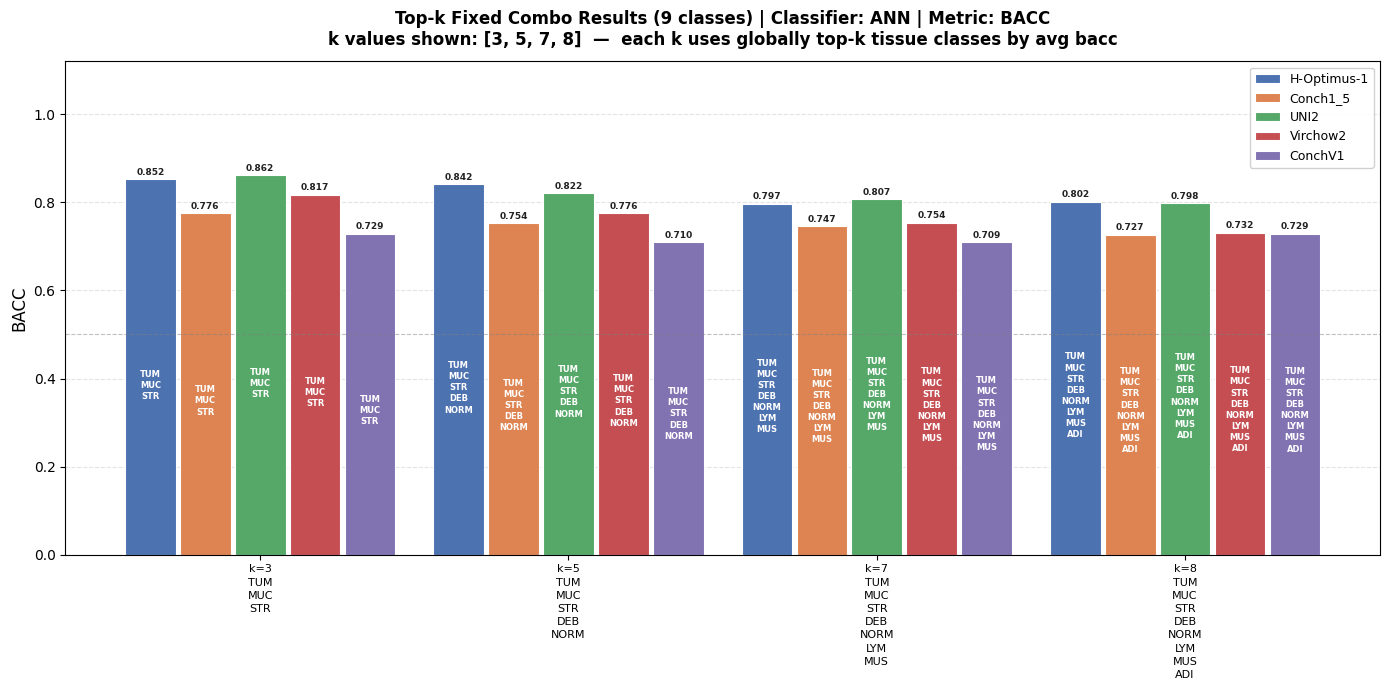

[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\by_model_topk_9cls.png


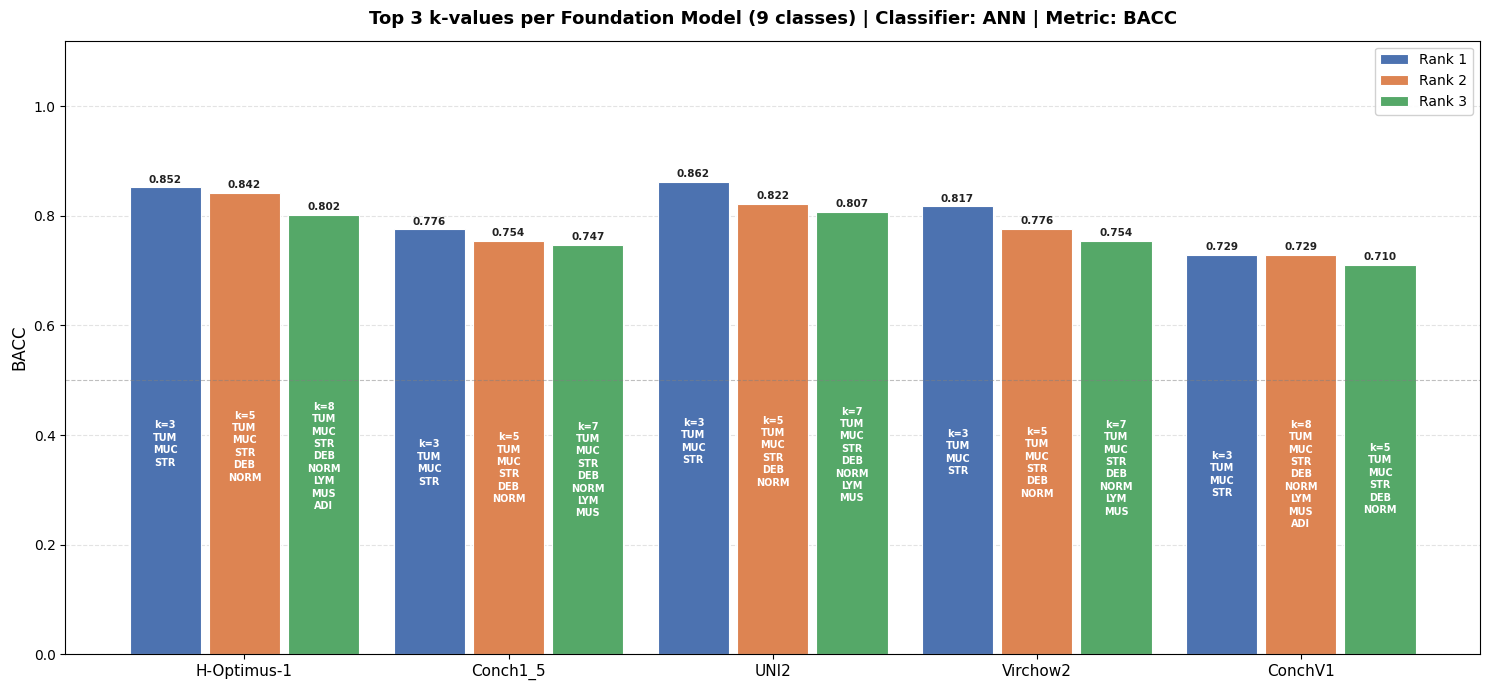

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Configuration ─────────────────────────────────────────────────────────────
BASE_9 = os.path.join(
    r"D:\Aamir Gulzar\KSA_project2",
    "Cancer-detection-classifier", "slide_classification",
    "TCGA_Results_Updated", "Tissue_Type_Clustering",
    "Global",               # Phase 2 summaries live under Global/<task>/
    "1-MSIH",
)

MODEL_NAMES_CHART_9 = [
    "H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"
]

CLASSIFIER_9   = "ann"
RANK_METRIC_9  = "bacc"

# Which k values to visualise — must match what was run in Phase 2 (max = 8, background excluded)
K_VALUES_SHOW = [3, 5, 7, 8]

TISSUE_ABBREV = {
    "adipose":       "ADI",
    "debris":        "DEB",
    "lymphocyte":    "LYM",
    "mucin":         "MUC",
    "smooth_muscle": "MUS",
    "normal_mucosa": "NORM",
    "stroma":        "STR",
    "tumor":         "TUM",
}


def abbrev_combo(combo_str: str) -> str:
    """Replace tissue names in a '+'-separated combo string with abbreviations."""
    parts = [p.strip() for p in combo_str.split("+") if p.strip()]
    return "\n".join(TISSUE_ABBREV.get(p, p) for p in parts)


# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# Phase 2 writes one file per k: tissue_topk_summary_9cls_k{k}.xlsx
# Columns: foundation_model, combo, k, classifier, bacc, …
# ─────────────────────────────────────────────────────────────────────────────

def load_k_9(k_val: int) -> pd.DataFrame | None:
    """
    Load the single top-k combo result file for the given k.
    Returns a DataFrame filtered to the requested classifier,
    or None if the file doesn't exist / has no matching rows.
    """
    fname = f"tissue_topk_summary_9cls_k{k_val}.xlsx"
    path  = os.path.join(BASE_9, fname)

    if not os.path.exists(path):
        print(f"[WARN] Not found: {path}")
        return None

    df = pd.read_excel(path)
    if df.empty:
        print(f"[WARN] Empty: {path}")
        return None

    df["classifier"] = df["classifier"].astype(str)
    df_clf = df[df["classifier"].str.lower().str.startswith(CLASSIFIER_9.lower())].copy()

    if df_clf.empty:
        print(f"[WARN] No '{CLASSIFIER_9}' rows in {path}")
        return None

    print(f"[OK] k={k_val}: {len(df_clf)} '{CLASSIFIER_9}' rows across "
          f"{df_clf['foundation_model'].nunique()} models")
    return df_clf


# ─────────────────────────────────────────────────────────────────────────────
# CHART 1 — Results across k values
#
# x-axis  : k values  (one group per k)
# bars    : one bar per foundation model inside each k group
# y-axis  : bacc
# No mean bar.
# Each bar is labelled with the abbreviated combo text inside the bar.
# ─────────────────────────────────────────────────────────────────────────────

def plot_across_k_9(
    k_data: dict,   # {k_val: DataFrame}
    metric: str = RANK_METRIC_9,
):
    valid_k  = sorted([k for k, df in k_data.items() if df is not None])
    if not valid_k:
        print("[WARN] No valid k data to plot.")
        return

    n_models = len(MODEL_NAMES_CHART_9)
    palette  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

    bar_w   = 0.13
    group_w = n_models * bar_w + 0.08
    x       = np.arange(len(valid_k)) * group_w

    fig, ax = plt.subplots(figsize=(max(14, len(valid_k) * 3.5), 7))

    for mi, model_name in enumerate(MODEL_NAMES_CHART_9):
        color  = palette[mi % len(palette)]
        offset = (mi - n_models / 2 + 0.5) * bar_w

        for ki, k_val in enumerate(valid_k):
            df = k_data[k_val]
            sub = df[df["foundation_model"] == model_name]
            if sub.empty:
                continue

            val   = sub[metric].mean()
            combo = sub["combo"].iloc[0]
            xpos  = x[ki] + offset

            ax.bar(xpos, val, width=bar_w - 0.01,
                   color=color, edgecolor="white", linewidth=0.8,
                   label=model_name if ki == 0 else "")

            # Value above bar
            ax.text(xpos, val + 0.005, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=6.5,
                    fontweight="bold", color="#222222")

            # Abbreviated combo inside bar
            abbrev = abbrev_combo(combo)
            if val > 0.08:
                ax.text(xpos, val * 0.45, abbrev,
                        ha="center", va="center",
                        fontsize=6, color="white", fontweight="bold",
                        linespacing=1.3, clip_on=True,
                        multialignment="center")

    # x-tick labels: show k value and which tissues it contains
    xtick_labels = []
    for k_val in valid_k:
        df = k_data[k_val]
        if df is not None and not df.empty:
            combo  = df["combo"].iloc[0]
            abbrev = abbrev_combo(combo)
            xtick_labels.append(f"k={k_val}\n{abbrev}")
        else:
            xtick_labels.append(f"k={k_val}")

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=8, linespacing=1.4)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top-k Fixed Combo Results (9 classes) | "
        f"Classifier: {CLASSIFIER_9.upper()} | Metric: {metric.upper()}\n"
        f"k values shown: {valid_k}  —  each k uses globally top-k tissue classes by avg bacc",
        fontsize=12, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=9,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    k_str    = "_".join(str(k) for k in valid_k)
    out_path = os.path.join(os.getcwd(), f"across_k_9cls_{k_str}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CHART 2 — Per foundation model, top-3 k values ranked by bacc
#
# x-axis  : foundation model
# bars    : top-3 k values (ranked by bacc for that model), one bar each
# y-axis  : bacc
# Bar interior shows k=N + abbreviated combo.
# ─────────────────────────────────────────────────────────────────────────────

def plot_by_model_9(
    k_data: dict,   # {k_val: DataFrame}
    metric: str = RANK_METRIC_9,
    top_n:  int = 3,
):
    valid_k = sorted([k for k, df in k_data.items() if df is not None])
    if not valid_k:
        print("[WARN] No valid k data to plot.")
        return

    palette  = ["#4C72B0", "#DD8452", "#55A868"]
    models   = MODEL_NAMES_CHART_9
    n_models = len(models)

    # For each model, collect (k_val, bacc, combo) sorted by bacc desc
    model_ranked: dict = {}
    for model_name in models:
        entries = []
        for k_val in valid_k:
            df  = k_data[k_val]
            if df is None:
                continue
            sub = df[df["foundation_model"] == model_name]
            if sub.empty:
                continue
            val   = sub[metric].mean()
            combo = sub["combo"].iloc[0]
            entries.append({"k": k_val, metric: val, "combo": combo})
        entries.sort(key=lambda d: d[metric], reverse=True)
        model_ranked[model_name] = entries[:top_n]

    width   = 0.3
    offsets = np.linspace(-(top_n - 1) / 2, (top_n - 1) / 2, top_n) * width
    x       = np.arange(n_models)

    fig, ax = plt.subplots(figsize=(15, 7))

    for ci in range(top_n):
        color = palette[ci % len(palette)]
        for mi, model_name in enumerate(models):
            entries = model_ranked.get(model_name, [])
            if ci >= len(entries):
                continue
            entry = entries[ci]
            val   = entry[metric]
            k_val = entry["k"]
            combo = entry["combo"]
            xpos  = x[mi] + offsets[ci]

            ax.bar(xpos, val, width=width - 0.03,
                   color=color, edgecolor="white", linewidth=0.8,
                   label=f"Rank {ci + 1}" if mi == 0 else "")

            # Value above bar
            ax.text(xpos, val + 0.005, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold", color="#222222")

            # k label + abbreviated combo inside bar
            label_text = f"k={k_val}\n{abbrev_combo(combo)}"
            if val > 0.08:
                ax.text(xpos, val * 0.45, label_text,
                        ha="center", va="center",
                        fontsize=7, color="white", fontweight="bold",
                        linespacing=1.3, clip_on=True,
                        multialignment="center")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top {top_n} k-values per Foundation Model (9 classes) | "
        f"Classifier: {CLASSIFIER_9.upper()} | Metric: {metric.upper()}",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=10,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), "by_model_topk_9cls.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# MAIN — load all requested k values then produce both charts
# ─────────────────────────────────────────────────────────────────────────────

k_data = {}
for k in K_VALUES_SHOW:
    df = load_k_9(k)
    k_data[k] = df

    if df is not None:
        print(f"\nResults for k={k}:")
        print(
            df[["foundation_model", "combo", "k", RANK_METRIC_9]]
            .sort_values(RANK_METRIC_9, ascending=False)
            .to_string(index=False)
        )

# Chart 1: results across all k values, bars = foundation models
plot_across_k_9(k_data, RANK_METRIC_9)

# Chart 2: per foundation model, best k values as ranked bars
plot_by_model_9(k_data, RANK_METRIC_9, top_n=3)

# 14 Classes

## Method 1 : Check individual class results then match strong classes (Caption_based_aggregation)

In [7]:
import os
import gc
import shutil
import itertools
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from itertools import product as iproduct

# Helper functions

class BestModelTracker:
    """
    Tracks the single best model checkpoint for one (foundation model, k) pair.
    Deletes any checkpoint that is not the current best immediately.
    Call .cleanup(keep_dir) at the end to move the winner to its final location.
    """

    def __init__(self, label: str):
        self.label      = label
        self.best_score = -1.0
        self.best_path: Optional[str] = None

    def update(self, score: float, candidate_path: Optional[str]) -> bool:
        """
        If `score` beats the current best, delete the old checkpoint and
        register the new one. Otherwise delete the candidate immediately.
        Returns True if a new best was found.
        """
        if score <= self.best_score:
            if candidate_path and os.path.exists(candidate_path):
                try:
                    os.remove(candidate_path)
                except OSError:
                    pass
            return False

        # New best — remove old checkpoint
        if self.best_path and os.path.exists(self.best_path):
            try:
                os.remove(self.best_path)
            except OSError:
                pass

        self.best_score = score
        self.best_path  = candidate_path
        return True

    def cleanup(self, keep_dir: str):
        """
        Copy the best checkpoint to `keep_dir` with a descriptive name,
        then delete the temporary copy.
        """
        if self.best_path and os.path.exists(self.best_path):
            os.makedirs(keep_dir, exist_ok=True)
            dest = os.path.join(
                keep_dir,
                f"best_{self.label}_{rank_by}{self.best_score:.4f}.pt",
            )
            shutil.copy2(self.best_path, dest)
            try:
                os.remove(self.best_path)
            except OSError:
                pass
            print(f"  ✓ Best model saved → {dest}")
        else:
            print(f"  [WARN] No best model found for {self.label} — nothing saved.")

def _temp_model_dir(output_save_path: str, label: str) -> str:
    """Scratch directory for a single combo's intermediate checkpoints."""
    d = os.path.join(
        output_save_path, "_tmp_models", label.replace("+", "_")
    )
    os.makedirs(d, exist_ok=True)
    return d


def _cleanup_temp_dir(output_save_path: str):
    tmp = os.path.join(output_save_path, "_tmp_models")
    if os.path.isdir(tmp):
        shutil.rmtree(tmp, ignore_errors=True)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — 14 Classes (Caption_based_aggregation)
# ─────────────────────────────────────────────────────────────────────────────

MODEL_NAMES_14 = [ "H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"] # "H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"

MODEL_BASE_DIMS_14 = {
    "H-Optimus-1": 1536,
    "UNI2":        1536,
    "Conch1_5":     768,
    "Virchow2":    2560,
    "ConchV1":      512,
}

TASK_PREFIXES_14 = {
    "MSIH": "1-MSIH",
    "BRAF": "2-BRAF",
    "KRAS": "3-KRAS",
    "TP53": "4-TP53",
    "CIMP": "5-CIMP",
}

TASK_FOLD_CONFIG_14 = {
    "MSIH": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\kfolds_IDARS_fixed.csv",
             "label_desc",    "nonMSIH"),
    "BRAF": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_BRAF.csv",
             "BRAF_mutation", "WT"),
    "KRAS": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_KRAS.csv",
             "KRAS_mutation", "WT"),
    "TP53": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_TP53.csv",
             "TP53_mutation", "WT"),
    "CIMP": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_CIMP.csv",
             "CIMP",          "neg"),
}

# 14 tissue class names (Caption_based_aggregation order, no background)
TISSUE_CLASS_NAMES_14 = [
    "adipose",             # 0  ADI
    "debris",              # 1  DEB
    "lymphocyte",          # 2  LYM
    "plasma_cell",         # 3  PLC
    "lymphoid_agg",        # 4  LYA
    "mucin",               # 5  MUC
    "smooth_muscle",       # 6  MUS
    "normal_mucosa",       # 7  NORM
    "adenoma",             # 8  ADE
    "stroma",              # 9  STR
    "mesenchymal",         # 10 MES
    "carcinoma",           # 11 CAR
    "poor_diff_carcinoma", # 12 PDC
    "signet_ring",         # 13 SIG
]
NUM_TISSUE_CLASSES_14 = 14

BATCH_SIZE_14    = 4
task_names_14    = ["MSIH"]                           # extend as needed
model_types_14   = ["ann"] # "lin", "ann", "knn", "proto", "rf"
k_values_14      = [4,14]                             # combination sizes for Phase 2
rank_by_14       = "bacc"

# Tier thresholds
STRONG_THRESHOLD_14  = 0.65 # 0.65,0.60
NEUTRAL_THRESHOLD_14 = 0.57 # 0.57,0.53

# Phase 2 combination filters
MAX_WEAK_PERCENT_14    = 0.10 # lower = more strict
MAX_NEUTRAL_PERCENT_14 = 0.35
MIN_STRONG_COUNT_14    = 1

RESULT_FOLDER_14      = "TCGA_Results_Updated"
BASE_ROOT_14          = r"D:\Aamir Gulzar\KSA_project2"
PROJECT_ROOT_14       = os.path.join(BASE_ROOT_14, "Cancer-detection-classifier", "slide_classification")
AGGREGATION_METHOD_14 = "Caption_based_aggregation"
sheet_name_14         = "tissue_search_14"


# ─────────────────────────────────────────────────────────────────────────────
# DATASET — 14 classes
# ─────────────────────────────────────────────────────────────────────────────

class TissueCombinationDataset14(Dataset):
    """
    Loads flattened (14 × feature_dim) .pt tensors and exposes
    only the rows listed in `row_indices`, re-flattened to (k × feature_dim).
    """

    def __init__(
        self,
        save_dir:     str,
        fold_ids:     List[str],
        row_indices:  List[int],
        num_classes:  int,
        feature_dim:  int,
        label_col:    str,
        neg_value:    str,
        k_folds_path: str,
    ):
        self.save_dir    = save_dir
        self.fold_ids    = set(fold_ids)
        self.row_indices = row_indices
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.label_col   = label_col
        self.neg_value   = neg_value

        folds_df      = pd.read_csv(k_folds_path)
        self.folds_df = folds_df.set_index("WSI_Id")

        self.data: List[Tuple[torch.Tensor, int, str]] = []
        self._load()

    def _load(self):
        expected_len = self.num_classes * self.feature_dim

        for fname in os.listdir(self.save_dir):
            if not fname.endswith(".pt"):
                continue
            wsi_id = os.path.splitext(fname)[0]
            if wsi_id not in self.fold_ids:
                continue
            if wsi_id not in self.folds_df.index:
                continue

            try:
                feats = torch.load(
                    os.path.join(self.save_dir, fname), map_location="cpu"
                )
                flat = feats.cpu().flatten()

                if flat.numel() != expected_len:
                    print(f"[WARN] {fname}: expected {expected_len} elements, "
                          f"got {flat.numel()}. Skipping.")
                    continue

                matrix   = flat.view(self.num_classes, self.feature_dim)
                selected = matrix[self.row_indices].flatten()

                raw   = self.folds_df.at[wsi_id, self.label_col]
                label = 0 if raw == self.neg_value else 1

                self.data.append((selected, label, wsi_id))

            except Exception as exc:
                print(f"[ERROR] {fname}: {exc}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        feats, label, wsi_id = self.data[idx]
        return feats, label, wsi_id


# ─────────────────────────────────────────────────────────────────────────────
# K-FOLD RUNNER — 14 classes (single combo × single model type)
# ─────────────────────────────────────────────────────────────────────────────

def _run_one_combo_kfold_14(
    task_name:       str,
    data_path:       str,
    k_folds_path:    str,
    folds:           List[List[str]],
    row_indices:     List[int],
    num_classes:     int,
    feature_dim:     int,
    model_type:      str,
    model_save_path: str,
    label_col:       str,
    neg_value:       str,
    tracker:         BestModelTracker,
) -> List[Dict[str, Any]]:
    """
    Runs k-fold CV for one (combo, model_type) pair using 14-class tensors.
    """
    vector_dim       = len(row_indices) * feature_dim
    metric_key       = f"{model_type}_macro_f1"
    results_per_fold = []
    num_folds        = len(folds)

    for i in range(num_folds):
        test_ids  = folds[i]
        val_ids   = folds[(i + 1) % num_folds]
        train_ids = [
            wsi_id
            for j, fold in enumerate(folds)
            if j != i and j != (i + 1) % num_folds
            for wsi_id in fold
        ]

        def make_loader_14(ids, shuffle):
            ds = TissueCombinationDataset14(
                save_dir     = data_path,
                fold_ids     = ids,
                row_indices  = row_indices,
                num_classes  = num_classes,
                feature_dim  = feature_dim,
                label_col    = label_col,
                neg_value    = neg_value,
                k_folds_path = k_folds_path,
            )
            if len(ds) == 0:
                raise ValueError(
                    f"Empty dataset for fold {i+1} — "
                    f"check WSI IDs vs files in {data_path}"
                )
            return DataLoader(ds, batch_size=BATCH_SIZE_14, shuffle=shuffle)

        train_loader = make_loader_14(train_ids, shuffle=True)
        val_loader   = make_loader_14(val_ids,   shuffle=False)
        test_loader  = make_loader_14(test_ids,  shuffle=False)

        def collect_14(loader):
            feats, labels, ids = [], [], []
            for f, l, w in loader:
                feats.append(f)
                labels.append(l)
                ids.extend(w if isinstance(w, (list, tuple)) else [w])
            return torch.cat(feats), torch.cat(labels), ids

        tr_f, tr_l, _            = collect_14(train_loader)
        va_f, va_l, _            = collect_14(val_loader)
        te_f, te_l, test_ids_out = collect_14(test_loader)

        best_metrics, best_dump, best_params = None, None, None
        last_saved_path = None

        if model_type == "lin":
            for C, max_iter in iproduct([10], [300]):
                m, d = eval_linear(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    max_iter=max_iter, save_path=model_save_path,
                    C=C, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"lin_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (C, max_iter)

        elif model_type == "ann":
            for h1, h2, max_iter in iproduct([128, 256], [64, 128], [500]):
                m, d = eval_ANN(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    input_dim=vector_dim, hidden_dim=h1, hidden_dim2=h2,
                    max_iter=max_iter, model_save_path=model_save_path,
                    verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"ann_fold{i}.pt")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (h1, h2, max_iter)

        elif model_type == "knn":
            for k_n in [3]:
                m, d = eval_knn(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    val_feats=va_f,   val_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_neighbors=k_n, normalize_feats=True,
                    model_save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"knn_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, k_n

        elif model_type == "proto":
            best_metrics, best_dump = eval_protonet(
                fold=i, train_feats=tr_f, train_labels=tr_l,
                val_feats=va_f, val_labels=va_l,
                test_feats=te_f, test_labels=te_l,
                normalize_feats=True, model_save_path=model_save_path,
            )
            last_saved_path = os.path.join(model_save_path, f"proto_fold{i}.pt")
            best_params = None

        elif model_type == "rf":
            for n_est, max_d, min_split, min_leaf, cw, thresh in iproduct(
                [500], [None], [5], [1], [{0: 1, 1: 10}], [0.3]
            ):
                m, d = eval_r_forest(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_estimators=n_est, max_depth=max_d,
                    min_samples_split=min_split, min_samples_leaf=min_leaf,
                    class_weight=cw, prediction_threshold=thresh,
                    save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"rf_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (
                        n_est, max_d, min_split, min_leaf, cw, thresh)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

        tracker.update(best_metrics.get(f"{model_type}_{rank_by_14}", 0.0), last_saved_path)

        if best_params:
            print(f"  Fold {i+1} | {model_type} best params: {best_params} | "
                  f"{rank_by_14}={best_metrics.get(f'{model_type}_{rank_by_14}', 0.0):.4f}")

        results_per_fold.append({
            **best_metrics,
            **best_dump,
            "wsi_ids": test_ids_out,
            "fold":    i + 1,
        })

    return results_per_fold


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — individual class evaluation (14 classes)
# ─────────────────────────────────────────────────────────────────────────────

def run_phase1_individual_classes_14(
    task_name:        str,
    data_path:        str,
    k_folds_path:     str,
    folds:            List[List[str]],
    feature_dim:      int,
    model_name:       str,
    output_save_path: str,
    label_col:        str,
    neg_value:        str,
) -> pd.DataFrame:
    """
    Evaluates each of the 14 tissue classes in isolation across all model types.
    Returns a DataFrame (one row per class) with avg metrics and tier labels.
    """
    print(f"\n{'─'*60}")
    print(f"  PHASE 1 — Individual class evaluation (14 classes)")
    print(f"  Model: {model_name} | Task: {task_name}")
    print(f"{'─'*60}")

    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}
    rows = []

    for class_idx, class_name in enumerate(TISSUE_CLASS_NAMES_14):
        print(f"\n  Class {class_idx}: {class_name}")
        row: Dict[str, Any] = {"class_idx": class_idx, "class_name": class_name}

        model_save_path = _temp_model_dir(output_save_path, f"individual_{class_name}")
        tracker = BestModelTracker(f"{model_name}_phase1_{class_name}")

        for model_type in model_types_14:
            try:
                fold_results = _run_one_combo_kfold_14(
                    task_name       = task_name,
                    data_path       = data_path,
                    k_folds_path    = k_folds_path,
                    folds           = folds,
                    row_indices     = [class_idx],
                    num_classes     = NUM_TISSUE_CLASSES_14,
                    feature_dim     = feature_dim,
                    model_type      = model_type,
                    model_save_path = model_save_path,
                    label_col       = label_col,
                    neg_value       = neg_value,
                    tracker         = tracker,
                )

                avg = calculate_metric_averages(
                    [{k: v for k, v in r.items()
                      if k in [f"{model_type}_{m}" for m in metric_indices]}
                     for r in fold_results],
                    metric_indices,
                    model_prefix=model_type,
                )
                for m in metric_indices:
                    row[f"{model_type}_{m}"] = avg.get(f"{model_type}_{m}", float("nan"))

            except Exception as exc:
                print(f"    [ERROR] {model_type}: {exc}")
                for m in metric_indices:
                    row[f"{model_type}_{m}"] = float("nan")

        bacc_vals = [row.get(f"{mt}_bacc", float("nan")) for mt in model_types_14]
        bacc_vals = [v for v in bacc_vals if not np.isnan(v)]
        row["best_bacc"] = (
            sum(bacc_vals) / len(bacc_vals) if bacc_vals else float("nan")
        )

        b = row["best_bacc"]
        row["tier"] = (
            "Strong"  if b >= STRONG_THRESHOLD_14  else
            "Neutral" if b >= NEUTRAL_THRESHOLD_14 else
            "Weak"
        )
        print(f"    best_bacc={b:.4f}  tier={row['tier']}")
        rows.append(row)

    _cleanup_temp_dir(output_save_path)

    df = pd.DataFrame(rows).sort_values("best_bacc", ascending=False)
    out_path = os.path.join(output_save_path, "tissue_individual_class_results_14.xlsx")
    write_data_in_excel(out_path, df, sheet_name="individual_classes_14")
    print(f"\n  ✓ Phase 1 results → {out_path}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# TIER-BASED COMBINATION GENERATOR — 14 classes
# ─────────────────────────────────────────────────────────────────────────────

def _smart_combinations_14(
    class_df: pd.DataFrame, k: int
) -> List[Tuple[int, ...]]:
    """
    Returns all C(14,k) combinations that pass all three tier filters.
    Special case: if k == NUM_TISSUE_CLASSES_14 (all 14 classes), tier
    filtering is skipped entirely and the single all-class combo is returned.
    """
    all_indices = class_df["class_idx"].tolist()

    # ── Special case: k == 14 → skip tier filtering, use all classes ─────────
    if k == NUM_TISSUE_CLASSES_14:
        combo = tuple(all_indices)
        print(f"  k={k}: using all {k} classes directly (tier filtering skipped)")
        return [combo]

    # ── Standard path: tier-filtered combinations ─────────────────────────────
    strong  = set(class_df[class_df["tier"] == "Strong" ]["class_idx"].tolist())
    neutral = set(class_df[class_df["tier"] == "Neutral"]["class_idx"].tolist())
    weak    = set(class_df[class_df["tier"] == "Weak"   ]["class_idx"].tolist())

    all_combos = list(itertools.combinations(all_indices, k))

    filtered          = []
    n_removed_weak    = 0
    n_removed_neutral = 0
    n_removed_strong  = 0

    for combo in all_combos:
        n_weak    = sum(1 for i in combo if i in weak)
        n_neutral = sum(1 for i in combo if i in neutral)
        n_strong  = sum(1 for i in combo if i in strong)

        if n_weak / k > MAX_WEAK_PERCENT_14:
            n_removed_weak += 1
            continue
        if n_neutral / k > MAX_NEUTRAL_PERCENT_14:
            n_removed_neutral += 1
            continue
        if n_strong < MIN_STRONG_COUNT_14:
            n_removed_strong += 1
            continue

        filtered.append(combo)

    print(f"  k={k}: {len(all_combos)} total → {len(filtered)} kept  "
          f"(removed {n_removed_weak} excess-weak, "
          f"{n_removed_neutral} excess-neutral, "
          f"{n_removed_strong} insufficient-strong  |  "
          f"thresholds: max_weak={MAX_WEAK_PERCENT_14:.0%}, "
          f"max_neutral={MAX_NEUTRAL_PERCENT_14:.0%}, "
          f"min_strong={MIN_STRONG_COUNT_14})")
    return filtered


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — combination search (14 classes)
# ─────────────────────────────────────────────────────────────────────────────

def run_phase2_combination_search_14(
    task_name:        str,
    data_path:        str,
    k_folds_path:     str,
    folds:            List[List[str]],
    feature_dim:      int,
    model_name:       str,
    output_save_path: str,
    label_col:        str,
    neg_value:        str,
    class_df:         pd.DataFrame,
    models_root_dir:  str,
):
    """
    Tests all tier-filtered combinations for each k in k_values_14.
    One BestModelTracker per (foundation model, k) — only the single best
    model checkpoint is kept at the end of each k.
    """
    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}

    for k in k_values_14:
        k_tracker  = BestModelTracker(f"{model_name}_14cls_k{k}")
        k_best_dir = os.path.join(models_root_dir, f"best_{k}labels_CAP")
        os.makedirs(k_best_dir, exist_ok=True)

        combos = _smart_combinations_14(class_df, k)
        print(f"\n{'─'*60}")
        print(f"  PHASE 2 — k={k} | {len(combos)} combos | Model: {model_name}")
        print(f"{'─'*60}")

        summary_rows      = []
        best_combo_score  = -1.0
        best_combo_label  = ""
        best_combo_probs: Optional[pd.DataFrame] = None

        for combo_idx, row_indices in enumerate(combos):
            combo_label = "+".join(TISSUE_CLASS_NAMES_14[i] for i in row_indices)
            print(f"\n  [{combo_idx+1}/{len(combos)}] {combo_label}")

            model_save_path = _temp_model_dir(output_save_path, combo_label)
            combo_probs_df: Optional[pd.DataFrame] = None

            for model_type in model_types_14:
                try:
                    fold_results = _run_one_combo_kfold_14(
                        task_name       = task_name,
                        data_path       = data_path,
                        k_folds_path    = k_folds_path,
                        folds           = folds,
                        row_indices     = list(row_indices),
                        num_classes     = NUM_TISSUE_CLASSES_14,
                        feature_dim     = feature_dim,
                        model_type      = model_type,
                        model_save_path = model_save_path,
                        label_col       = label_col,
                        neg_value       = neg_value,
                        tracker         = k_tracker,
                    )

                    model_df = build_probs_df(fold_results, model_name=model_type)
                    combo_probs_df = (
                        model_df if combo_probs_df is None
                        else pd.merge(combo_probs_df, model_df,
                                      on=["Fold", "WSI_ID", "Target"], how="outer")
                    )

                    avg = calculate_metric_averages(
                        [{key: v for key, v in r.items()
                          if key in [f"{model_type}_{m}" for m in metric_indices]}
                         for r in fold_results],
                        metric_indices,
                        model_prefix=model_type,
                    )

                    combo_score = avg.get(f"{model_type}_{rank_by_14}", -1.0)
                    summary_rows.append({
                        "combo":      combo_label,
                        "rows":       str(list(row_indices)),
                        "k":          k,
                        "model":      model_type,
                        **{m: avg.get(f"{model_type}_{m}", float("nan"))
                           for m in metric_indices},
                    })

                    if combo_score > best_combo_score:
                        best_combo_score = combo_score
                        best_combo_label = combo_label
                        best_combo_probs = (
                            combo_probs_df.copy()
                            if combo_probs_df is not None else None
                        )

                except Exception as exc:
                    print(f"    [ERROR] {model_type}: {exc}")

            if os.path.isdir(model_save_path):
                shutil.rmtree(model_save_path, ignore_errors=True)
            gc.collect()

        summary_df = (
            pd.DataFrame(summary_rows)
            .sort_values(rank_by_14, ascending=False)
        )
        summary_path = os.path.join(output_save_path, f"tissue_combo_summary_14cls_k{k}.xlsx")
        write_data_in_excel(summary_path, summary_df, sheet_name=f"k{k}")
        print(f"\n  ✓ Summary k={k} → {summary_path}")
        print(f"  Best combo ({rank_by_14}={best_combo_score:.4f}): {best_combo_label}")

        if best_combo_probs is not None:
            probs_path = os.path.join(
                output_save_path, f"tissue_combo_probs_14cls_k{k}_best.xlsx"
            )
            write_data_in_excel(probs_path, best_combo_probs,
                                sheet_name=f"k{k}_best_probs")
            print(f"  Best combo probs → {probs_path}")

        k_tracker.cleanup(keep_dir=k_best_dir)

    _cleanup_temp_dir(output_save_path)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP — 14 classes
# ─────────────────────────────────────────────────────────────────────────────

for MODEL_NAME_14 in MODEL_NAMES_14:
    feature_dim_14 = MODEL_BASE_DIMS_14[MODEL_NAME_14]

    DATA_PATH_14   = os.path.join(
        BASE_ROOT_14, "dataset", "slide_aggregation", AGGREGATION_METHOD_14, MODEL_NAME_14
    )
    RESULT_ROOT_14 = os.path.join(
        PROJECT_ROOT_14, RESULT_FOLDER_14, AGGREGATION_METHOD_14, MODEL_NAME_14
    )

    for task_name in task_names_14:
        folder_task_name = TASK_PREFIXES_14.get(task_name, task_name)
        OUTPUT_SAVE_PATH_14 = os.path.join(RESULT_ROOT_14, folder_task_name, "Output")
        MODELS_ROOT_DIR_14  = os.path.join(RESULT_ROOT_14, folder_task_name, "models")

        os.makedirs(OUTPUT_SAVE_PATH_14, exist_ok=True)
        os.makedirs(MODELS_ROOT_DIR_14,  exist_ok=True)

        k_folds_path_14, label_col_14, neg_value_14 = TASK_FOLD_CONFIG_14[task_name]

        folds_df_14 = pd.read_csv(k_folds_path_14)
        folds_14: List[List[str]] = [
            folds_df_14[folds_df_14["fold"] == fn]["WSI_Id"].tolist()
            for fn in sorted(folds_df_14["fold"].unique())
        ]

        print(f"\n{'='*70}")
        print(f"  Model: {MODEL_NAME_14} | Task: {task_name} | 14-class CAP")
        print(f"{'='*70}")

        class_df_14 = run_phase1_individual_classes_14(
            task_name        = task_name,
            data_path        = DATA_PATH_14,
            k_folds_path     = k_folds_path_14,
            folds            = folds_14,
            feature_dim      = feature_dim_14,
            model_name       = MODEL_NAME_14,
            output_save_path = OUTPUT_SAVE_PATH_14,
            label_col        = label_col_14,
            neg_value        = neg_value_14,
        )

        run_phase2_combination_search_14(
            task_name        = task_name,
            data_path        = DATA_PATH_14,
            k_folds_path     = k_folds_path_14,
            folds            = folds_14,
            feature_dim      = feature_dim_14,
            model_name       = MODEL_NAME_14,
            output_save_path = OUTPUT_SAVE_PATH_14,
            label_col        = label_col_14,
            neg_value        = neg_value_14,
            class_df         = class_df_14,
            models_root_dir  = MODELS_ROOT_DIR_14,
        )

        print(f"\n  ✓ Done: {MODEL_NAME_14} / {task_name} (14 classes)")


  Model: H-Optimus-1 | Task: MSIH | 14-class CAP

────────────────────────────────────────────────────────────
  PHASE 1 — Individual class evaluation (14 classes)
  Model: H-Optimus-1 | Task: MSIH
────────────────────────────────────────────────────────────

  Class 0: adipose
  Fold 1 | ann best params: (128, 64, 500) | bacc=0.6246
  Fold 2 | ann best params: (256, 64, 500) | bacc=0.5788
  Fold 3 | ann best params: (128, 64, 500) | bacc=0.5076
  Fold 4 | ann best params: (128, 128, 500) | bacc=0.5993
    best_bacc=0.5776  tier=Neutral

  Class 1: debris
  Fold 1 | ann best params: (128, 128, 500) | bacc=0.6311
  Fold 2 | ann best params: (128, 128, 500) | bacc=0.6030
  Fold 3 | ann best params: (256, 128, 500) | bacc=0.6087
  Fold 4 | ann best params: (128, 64, 500) | bacc=0.6096
    best_bacc=0.6131  tier=Neutral

  Class 2: lymphocyte
  Fold 1 | ann best params: (256, 64, 500) | bacc=0.5652
  Fold 2 | ann best params: (256, 64, 500) | bacc=0.6474
  Fold 3 | ann best params: (256, 

KeyboardInterrupt: 

## Generate charts for best combos (14 classes)

[OK] H-Optimus-1 k=4: 350 'ann' rows
[OK] Conch1_5 k=4: 35 'ann' rows
[OK] UNI2 k=4: 155 'ann' rows
[OK] Virchow2 k=4: 175 'ann' rows
[OK] ConchV1 k=4: 55 'ann' rows
[INFO] 20 NaN cell(s) in top-5 — running on-the-fly evaluation...

  [ON-THE-FLY] Model: Conch1_5 | 5 combo(s)
    Combo: carcinoma+adenoma+poor_diff_carcinoma+smooth_muscle
  Fold 1 | ann best params: (256, 128, 500) | bacc=0.8098
  Fold 2 | ann best params: (128, 64, 500) | bacc=0.6978
  Fold 3 | ann best params: (256, 128, 500) | bacc=0.8207
  Fold 4 | ann best params: (128, 128, 500) | bacc=0.7243
      ann: bacc=0.7631
    → pivot['carcinoma+adenoma+poor_diff_carcinoma+smooth_muscle']['Conch1_5'] = 0.7631
    Combo: carcinoma+adenoma+poor_diff_carcinoma+mesenchymal
  Fold 1 | ann best params: (128, 64, 500) | bacc=0.7644
  Fold 2 | ann best params: (128, 64, 500) | bacc=0.5678
  Fold 3 | ann best params: (256, 128, 500) | bacc=0.7511
  Fold 4 | ann best params: (256, 128, 500) | bacc=0.7186
      ann: bacc=0.7005
    

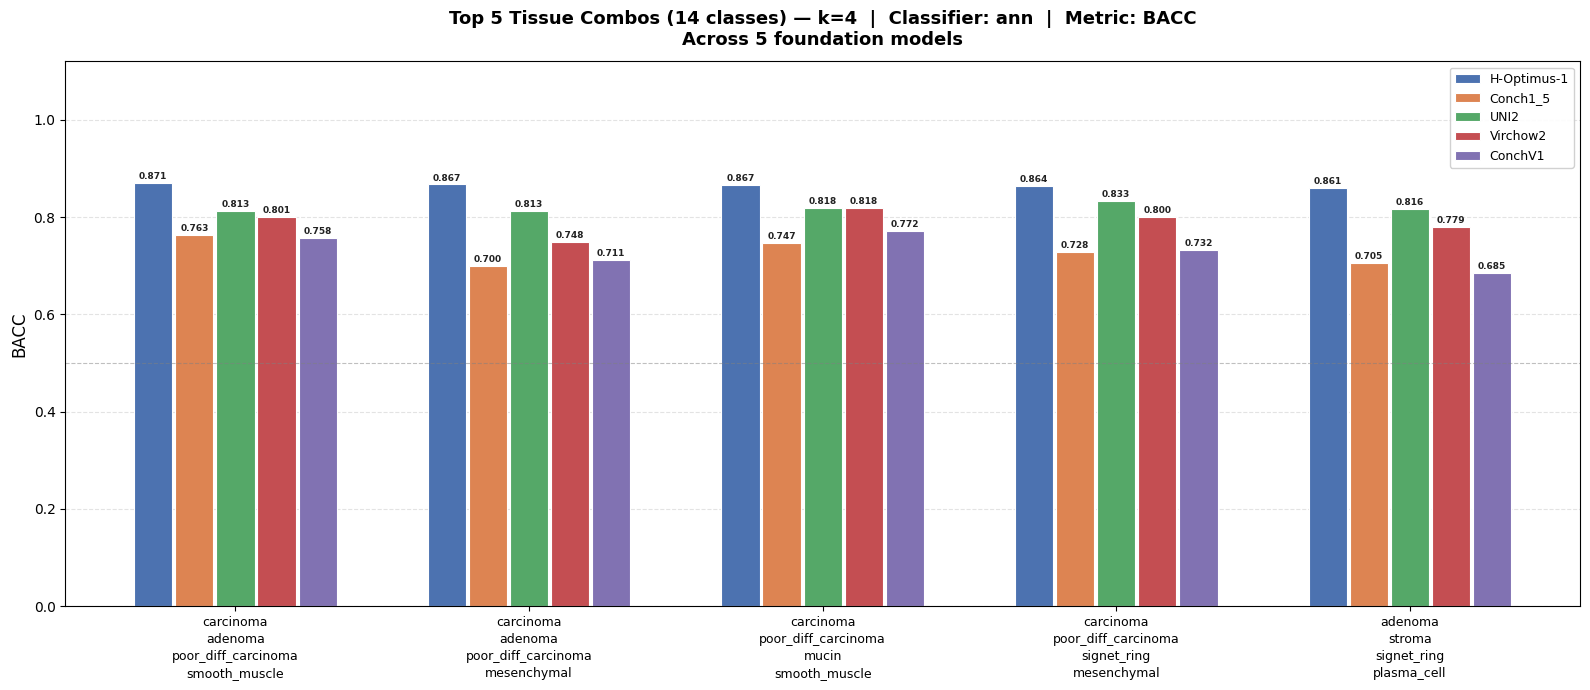

[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\by_model_14cls_k4.png


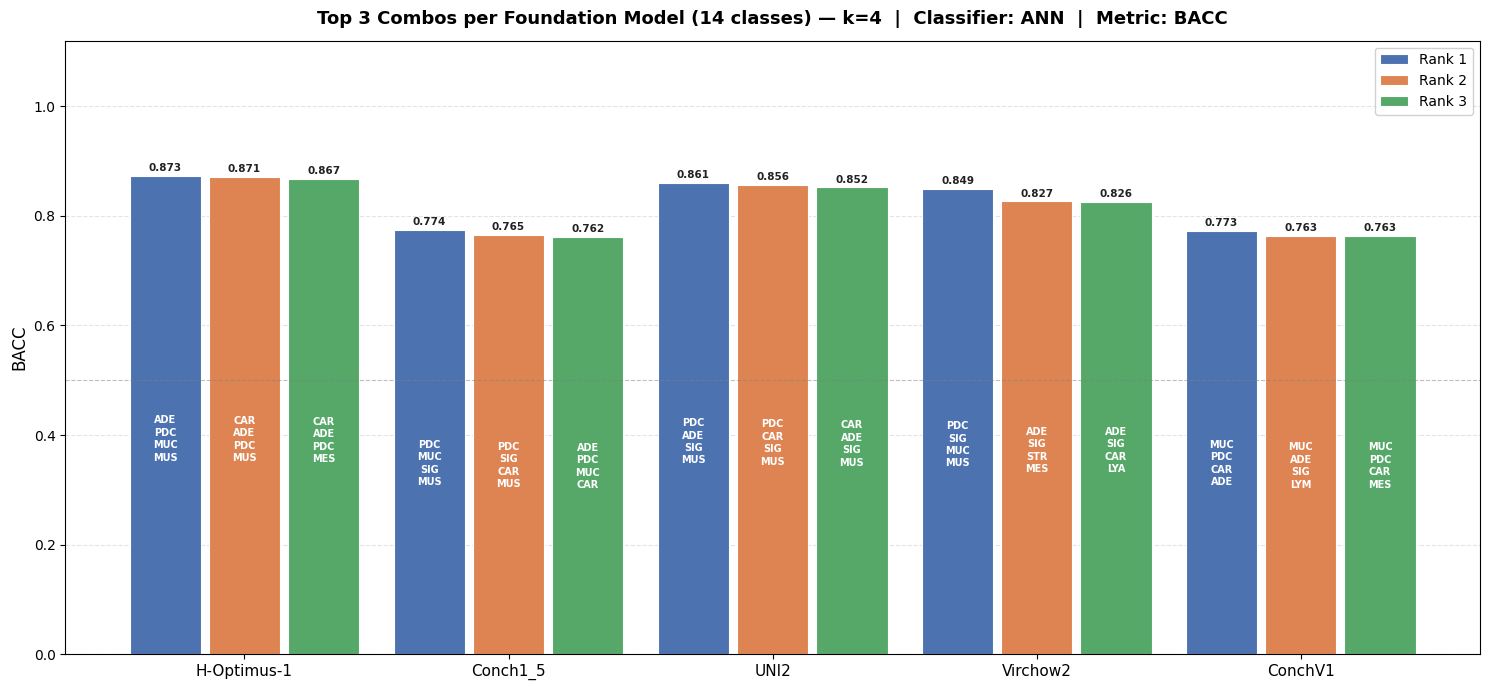

[OK] H-Optimus-1 k=14: 1 'ann' rows
[OK] Conch1_5 k=14: 1 'ann' rows
[OK] UNI2 k=14: 1 'ann' rows
[OK] Virchow2 k=14: 1 'ann' rows
[OK] ConchV1 k=14: 1 'ann' rows
[INFO] 20 NaN cell(s) in top-5 — running on-the-fly evaluation...

  [ON-THE-FLY] Model: Conch1_5 | 4 combo(s)
    Combo: carcinoma+adenoma+poor_diff_carcinoma+stroma+mucin+signet_ring+lymphoid_agg+mesenchymal+normal_mucosa+smooth_muscle+lymphocyte+plasma_cell+debris+adipose
  Fold 1 | ann best params: (256, 128, 500) | bacc=0.7758
  Fold 2 | ann best params: (256, 128, 500) | bacc=0.7390
  Fold 3 | ann best params: (256, 64, 500) | bacc=0.7717
  Fold 4 | ann best params: (128, 64, 500) | bacc=0.7051
      ann: bacc=0.7479
    → pivot['carcinoma+adenoma+poor_diff_carcinoma+stroma+mucin+signet_ring+lymphoid_agg+mesenchymal+normal_mucosa+smooth_muscle+lymphocyte+plasma_cell+debris+adipose']['Conch1_5'] = 0.7479
    Combo: poor_diff_carcinoma+carcinoma+adenoma+signet_ring+stroma+mucin+lymphoid_agg+smooth_muscle+lymphocyte+normal

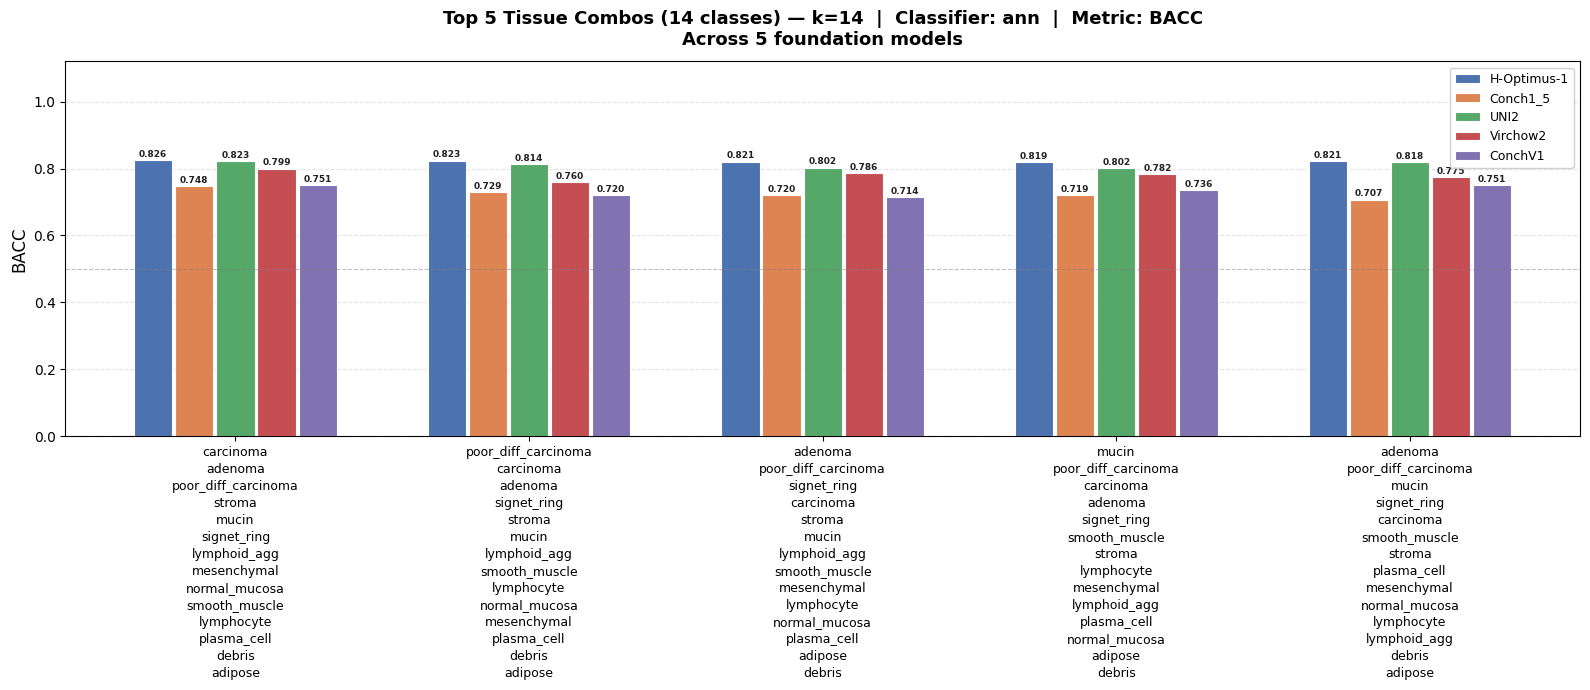

[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\by_model_14cls_k14.png


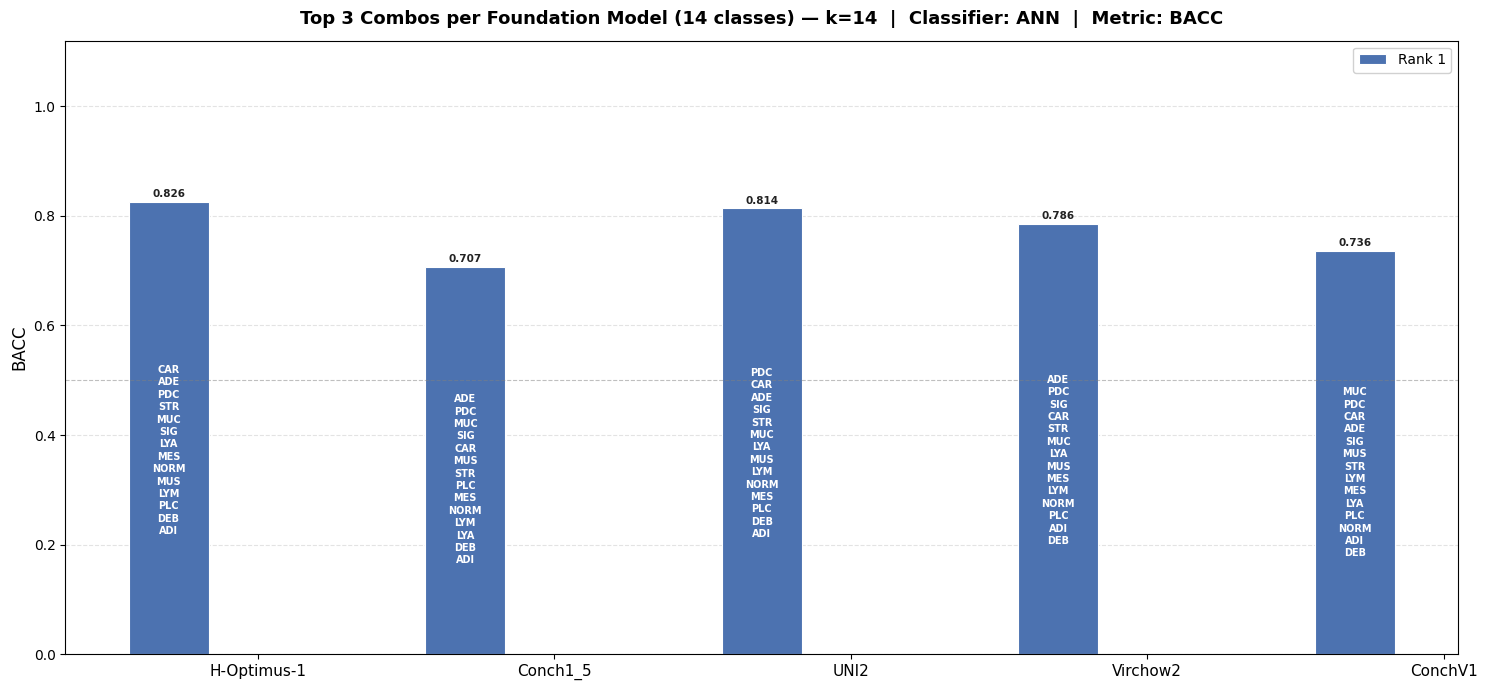

[OK] H-Optimus-1 k=4: 350 'ann' rows
[OK] Conch1_5 k=4: 35 'ann' rows
[OK] UNI2 k=4: 155 'ann' rows
[OK] Virchow2 k=4: 175 'ann' rows
[OK] ConchV1 k=4: 55 'ann' rows
[OK] H-Optimus-1 k=14: 1 'ann' rows
[OK] Conch1_5 k=14: 1 'ann' rows
[OK] UNI2 k=14: 1 'ann' rows
[OK] Virchow2 k=14: 1 'ann' rows
[OK] ConchV1 k=14: 1 'ann' rows
[OK] k-comparison chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\k_comparison_best_combo_14cls.png


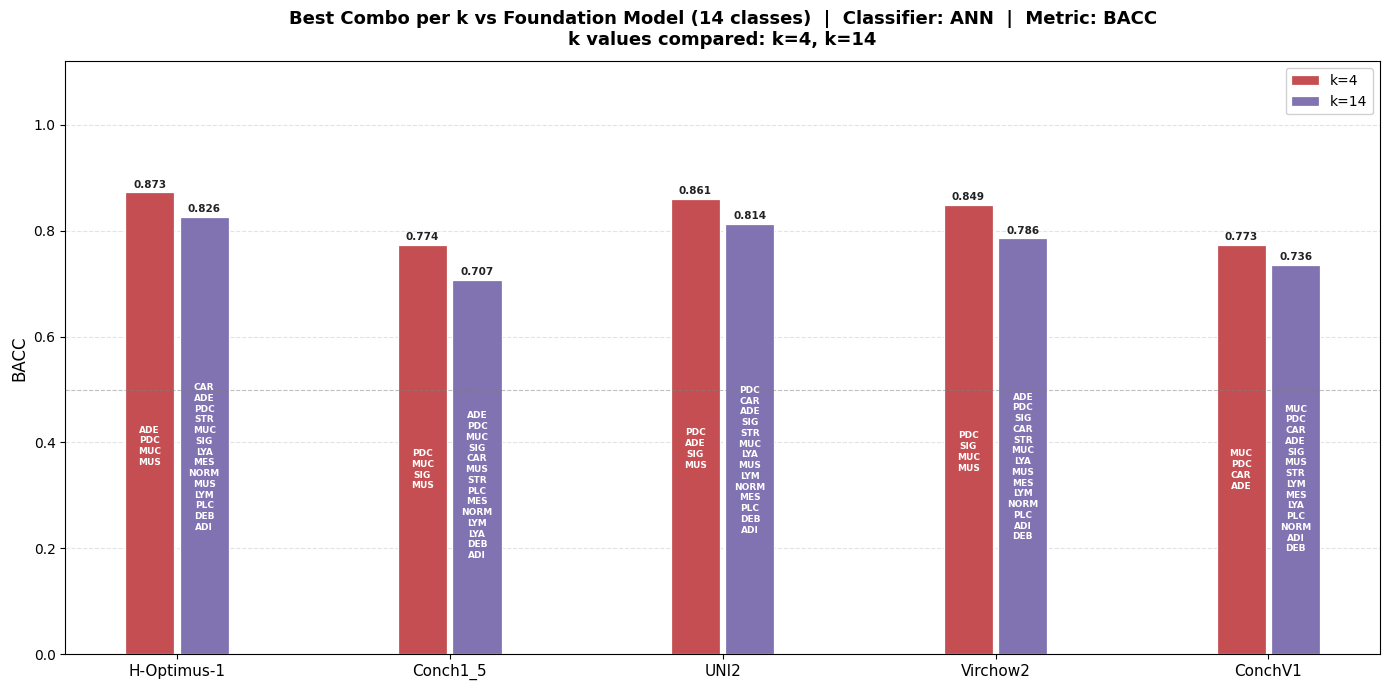

In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Configuration ─────────────────────────────────────────────────────────────
BASE_14 = os.path.join(
    r"D:\Aamir Gulzar\KSA_project2",
    "Cancer-detection-classifier", "slide_classification",
    "TCGA_Results_Updated", "Caption_based_aggregation"
)

MODEL_NAMES_CHART_14 = [
    "H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"
]

SUBFOLDER_14     = r"1-MSIH\Output"
CLASSIFIER_14    = "ann"
RANK_METRIC_14   = "bacc"

# K values used for the k-comparison chart
K_VALUES_COMPARE = [4, 14]

TISSUE_ABBREV = {
    "adipose":             "ADI",
    "debris":              "DEB",
    "lymphocyte":          "LYM",
    "plasma_cell":         "PLC",
    "lymphoid_agg":        "LYA",
    "mucin":               "MUC",
    "smooth_muscle":       "MUS",
    "normal_mucosa":       "NORM",
    "adenoma":             "ADE",
    "stroma":              "STR",
    "mesenchymal":         "MES",
    "carcinoma":           "CAR",
    "poor_diff_carcinoma": "PDC",
    "signet_ring":         "SIG",
}

def abbrev_combo(combo_str):
    parts = [p.strip() for p in combo_str.split("+") if p.strip()]
    return "\n".join(TISSUE_ABBREV.get(p, p) for p in parts)


# ── Load ──────────────────────────────────────────────────────────────────────
def load_k_14(k_val):
    frames = []
    fname = f"tissue_combo_summary_14cls_k{k_val}.xlsx"
    for model in MODEL_NAMES_CHART_14:
        path = os.path.join(BASE_14, model, SUBFOLDER_14, fname)
        if not os.path.exists(path):
            print(f"[WARN] Not found: {path}")
            continue
        df = pd.read_excel(path)
        if df.empty:
            print(f"[WARN] Empty: {path}")
            continue
        df["model"] = df["model"].astype(str)
        df_clf = df[df["model"].str.lower().str.startswith(CLASSIFIER_14.lower())].copy()
        if df_clf.empty:
            print(f"[WARN] No '{CLASSIFIER_14}' rows in {path}")
            continue
        df_clf.insert(0, "model_name", model)
        frames.append(df_clf)
        print(f"[OK] {model} k={k_val}: {len(df_clf)} '{CLASSIFIER_14}' rows")
    return pd.concat(frames, ignore_index=True) if frames else None


# ── Top-5 combos (ranked by mean, mean col dropped before plotting) ───────────
def top5_combos_14(df, metric=RANK_METRIC_14):
    pivot = (
        df.groupby(["combo", "model_name"])[metric]
        .mean()
        .unstack(fill_value=np.nan)
    )

    models_present = [m for m in MODEL_NAMES_CHART_14 if m in pivot.columns]

    # ── Count how many models have data per combo ─────────────────────────────
    coverage = pivot[models_present].notna().sum(axis=1)   # Series: combo → int
    max_coverage = coverage.max()

    # ── Try to find combos with full coverage, step down if none exist ────────
    selected = pd.DataFrame()
    achieved_coverage = 0

    for required in range(max_coverage, 0, -1):
        mask = coverage >= required
        candidates = pivot[mask].copy()
        if candidates.empty:
            continue

        candidates["mean"] = candidates[models_present].mean(axis=1)   # mean over available models only
        top5 = candidates.nlargest(5, "mean").drop(columns=["mean"]).reset_index()

        if len(top5) >= 1:
            selected = top5
            achieved_coverage = required
            break

    if selected.empty:
        print("[WARN] Completely empty pivot — nothing to rank.")
        return pd.DataFrame(columns=["combo"] + models_present)

    # ── Diagnostic summary ────────────────────────────────────────────────────
    if achieved_coverage < len(models_present):
        missing_models = [
            m for m in models_present
            if selected[m].isna().all()
        ]
        print(
            f"[INFO] No combo had data across all {len(models_present)} models.\n"
            f"       Fell back to combos covered by {achieved_coverage}/{len(models_present)} model(s).\n"
            f"       Models with no data for this k: {missing_models}\n"
            f"       Mean is computed only over models that have data."
        )
    else:
        print(f"[INFO] Top-5 selected from combos with full coverage ({achieved_coverage}/{len(models_present)} models).")

    return selected


# ── Chart 1: top-5 combos (no mean bar) ──────────────────────────────────────
def top5_combos_14(df, metric=RANK_METRIC_14, k_val=None):
    from collections import defaultdict

    pivot = (
        df.groupby(["combo", "model_name"])[metric]
        .mean()
        .unstack(fill_value=np.nan)
    )

    models_present = [m for m in MODEL_NAMES_CHART_14 if m in pivot.columns]

    # ── Step 1: rank ALL combos by mean over whatever data exists ─────────────
    pivot["mean"] = pivot[models_present].mean(axis=1)   # NaN cols ignored by default
    top5_combos   = pivot.nlargest(5, "mean").index.tolist()
    pivot.drop(columns=["mean"], inplace=True)

    # ── Step 2: find NaN cells only within those top 5 ───────────────────────
    top5_pivot   = pivot.loc[top5_combos]
    nan_mask     = top5_pivot[models_present].isna()
    missing_pairs = [
        (combo, model)
        for combo in top5_combos
        for model in models_present
        if nan_mask.at[combo, model]
    ]

    if missing_pairs:
        print(f"[INFO] {len(missing_pairs)} NaN cell(s) in top-5 — running on-the-fly evaluation...")

        metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2, "weighted_f1": 3, "auroc": 4}

        missing_by_model = defaultdict(list)
        for combo, model in missing_pairs:
            missing_by_model[model].append(combo)

        tmp_root = os.path.join(
            BASE_ROOT_14, "Cancer-detection-classifier",
            "slide_classification", "_otf_tmp"
        )

        for model_name, combos in missing_by_model.items():
            print(f"\n  [ON-THE-FLY] Model: {model_name} | {len(combos)} combo(s)")

            feature_dim  = MODEL_BASE_DIMS_14[model_name]
            data_path    = os.path.join(
                BASE_ROOT_14, "dataset", "slide_aggregation",
                AGGREGATION_METHOD_14, model_name
            )
            task_name    = task_names_14[0]
            k_folds_path, label_col, neg_value = TASK_FOLD_CONFIG_14[task_name]

            folds_df = pd.read_csv(k_folds_path)
            folds = [
                folds_df[folds_df["fold"] == fn]["WSI_Id"].tolist()
                for fn in sorted(folds_df["fold"].unique())
            ]

            for combo_str in combos:
                parts       = [p.strip() for p in combo_str.split("+") if p.strip()]
                row_indices = [TISSUE_CLASS_NAMES_14.index(p) for p in parts
                               if p in TISSUE_CLASS_NAMES_14]

                if len(row_indices) != len(parts):
                    print(f"    [WARN] Could not resolve all tissue names in '{combo_str}' — skipping.")
                    continue

                print(f"    Combo: {combo_str}")

                model_save_path = _temp_model_dir(tmp_root, combo_str)
                tracker         = BestModelTracker(f"otf_{model_name}_{combo_str[:30]}")
                scores          = []

                for model_type in model_types_14:
                    try:
                        fold_results = _run_one_combo_kfold_14(
                            task_name       = task_name,
                            data_path       = data_path,
                            k_folds_path    = k_folds_path,
                            folds           = folds,
                            row_indices     = row_indices,
                            num_classes     = NUM_TISSUE_CLASSES_14,
                            feature_dim     = feature_dim,
                            model_type      = model_type,
                            model_save_path = model_save_path,
                            label_col       = label_col,
                            neg_value       = neg_value,
                            tracker         = tracker,
                        )
                        avg   = calculate_metric_averages(
                            [{k: v for k, v in r.items()
                              if k in [f"{model_type}_{m}" for m in metric_indices]}
                             for r in fold_results],
                            metric_indices,
                            model_prefix=model_type,
                        )
                        score = avg.get(f"{model_type}_{metric}", float("nan"))
                        scores.append(score)
                        print(f"      {model_type}: {metric}={score:.4f}")

                    except Exception as exc:
                        print(f"      [ERROR] {model_type}: {exc}")
                        scores.append(float("nan"))

                valid  = [s for s in scores if not np.isnan(s)]
                filled = float(np.mean(valid)) if valid else float("nan")
                pivot.at[combo_str, model_name] = filled
                print(f"    → pivot['{combo_str}']['{model_name}'] = {filled:.4f}")

                if os.path.isdir(model_save_path):
                    shutil.rmtree(model_save_path, ignore_errors=True)

        _cleanup_temp_dir(tmp_root)

    # ── Step 3: return the top-5 slice with NaN cells now filled ─────────────
    return pivot.loc[top5_combos].reset_index()


# ── Chart 2: top-3 per foundation model ──────────────────────────────────────
def plot_by_model_14(df, k_val, metric=RANK_METRIC_14, top_n=3):
    palette = ["#4C72B0", "#DD8452", "#55A868"]

    model_data = {}
    for model in MODEL_NAMES_CHART_14:
        sub = df[df["model_name"] == model]
        if sub.empty:
            continue
        top = (
            sub.groupby("combo")[metric]
            .mean()
            .nlargest(top_n)
            .reset_index()
        )
        model_data[model] = top

    models   = [m for m in MODEL_NAMES_CHART_14 if m in model_data]
    n_models = len(models)
    if n_models == 0:
        print("[WARN] No data to plot.")
        return

    width   = 0.3
    offsets = np.linspace(-(top_n - 1) / 2, (top_n - 1) / 2, top_n) * width
    x       = np.arange(n_models)

    fig, ax = plt.subplots(figsize=(15, 7))

    for ci in range(top_n):
        color = palette[ci % len(palette)]
        for mi, model in enumerate(models):
            top = model_data[model]
            if ci >= len(top):
                continue
            row   = top.iloc[ci]
            val   = row[metric]
            combo = row["combo"]
            xpos  = x[mi] + offsets[ci]

            ax.bar(xpos, val, width=width - 0.03,
                   color=color, edgecolor="white", linewidth=0.8,
                   label=f"Rank {ci + 1}" if mi == 0 else "")

            ax.text(xpos, val + 0.005, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold", color="#222222")

            if val > 0.08:
                ax.text(xpos, val * 0.45, abbrev_combo(combo),
                        ha="center", va="center",
                        fontsize=7, color="white", fontweight="bold",
                        linespacing=1.3, clip_on=True,
                        multialignment="center")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top {top_n} Combos per Foundation Model (14 classes) — k={k_val}  |  "
        f"Classifier: {CLASSIFIER_14.upper()}  |  Metric: {metric.upper()}",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=10,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), f"by_model_14cls_k{k_val}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()


# ── Chart 3: best combo per k vs foundation model ─────────────────────────────
def plot_k_comparison_14(k_values, metric=RANK_METRIC_14):
    """
    x-axis  = foundation model
    y-axis  = metric value
    bars    = one per k value, showing the single best combo for that (model, k)
    Combo abbreviation printed inside each bar.
    """
    k_palette = {
        3: "#4C72B0",
        5: "#DD8452",
        8: "#55A868",
    }
    extra_colours = ["#C44E52", "#8172B2", "#2d2d2d"]

    # ── Gather best (score, combo) per (model, k) ─────────────────────────────
    best_data: dict = {}
    k_loaded:  list = []

    for k_val in k_values:
        df = load_k_14(k_val)
        if df is None:
            print(f"[WARN] No data for k={k_val} — skipped in comparison chart.")
            continue
        k_loaded.append(k_val)
        best_data[k_val] = {}

        for model in MODEL_NAMES_CHART_14:
            sub = df[df["model_name"] == model]
            if sub.empty:
                continue
            grouped     = sub.groupby("combo")[metric].mean()
            best_combo  = grouped.idxmax()
            best_score  = grouped.max()
            best_data[k_val][model] = {"score": best_score, "combo": best_combo}

    if not k_loaded:
        print("[WARN] No k values had data — skipping comparison chart.")
        return

    # ── Colour map ────────────────────────────────────────────────────────────
    colour_map = {}
    extra_idx  = 0
    for k_val in k_loaded:
        if k_val in k_palette:
            colour_map[k_val] = k_palette[k_val]
        else:
            colour_map[k_val] = extra_colours[extra_idx % len(extra_colours)]
            extra_idx += 1

    n_k      = len(k_loaded)
    n_models = len(MODEL_NAMES_CHART_14)
    bar_w    = 0.20
    x        = np.arange(n_models)
    offsets  = np.linspace(-(n_k - 1) / 2, (n_k - 1) / 2, n_k) * bar_w

    fig, ax = plt.subplots(figsize=(max(14, n_models * 2.2), 7))

    for ki, k_val in enumerate(k_loaded):
        colour = colour_map[k_val]
        offset = offsets[ki]

        for mi, model in enumerate(MODEL_NAMES_CHART_14):
            entry = best_data[k_val].get(model)
            if entry is None:
                continue

            score = entry["score"]
            combo = entry["combo"]
            xpos  = x[mi] + offset

            ax.bar(xpos, score, width=bar_w - 0.02,
                   color=colour, edgecolor="white", linewidth=0.9,
                   label=f"k={k_val}" if mi == 0 else "")

            ax.text(xpos, score + 0.005, f"{score:.3f}",
                    ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold", color="#222222")

            if score > 0.10:
                ax.text(xpos, score * 0.45, abbrev_combo(combo),
                        ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold",
                        linespacing=1.25, clip_on=True,
                        multialignment="center")

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES_CHART_14, fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Best Combo per k vs Foundation Model (14 classes)  |  "
        f"Classifier: {CLASSIFIER_14.upper()}  |  Metric: {metric.upper()}\n"
        f"k values compared: {', '.join(f'k={k}' for k in k_loaded)}",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=10,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), "k_comparison_best_combo_14cls.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] k-comparison chart saved → {out_path}")
    plt.show()


# ── Main ──────────────────────────────────────────────────────────────────────
for k in [4, 14]:
    df = load_k_14(k)
    if df is None:
        print(f"[WARN] No data for k={k}, skipping per-k charts.")
        continue
    top5 = top5_combos_14(df, RANK_METRIC_14, k_val=k)   # <-- pass k_val
    print(f"\nTop 5 combos for k={k} (14 classes):")
    print(top5[["combo"] + [m for m in MODEL_NAMES_CHART_14 if m in top5.columns]].to_string(index=False))
    plot_top5_14(top5, k)
    plot_by_model_14(df, k)

plot_k_comparison_14(K_VALUES_COMPARE)

## Method 2 : Using best k only

In [9]:
import os
import gc
import shutil
import itertools
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from itertools import product as iproduct

# Helper functions

class BestModelTracker:
    """
    Tracks the single best model checkpoint for one (foundation model, k) pair.
    Deletes any checkpoint that is not the current best immediately.
    Call .cleanup(keep_dir) at the end to move the winner to its final location.
    """

    def __init__(self, label: str):
        self.label      = label
        self.best_score = -1.0
        self.best_path: Optional[str] = None

    def update(self, score: float, candidate_path: Optional[str]) -> bool:
        if score <= self.best_score:
            if candidate_path and os.path.exists(candidate_path):
                try:
                    os.remove(candidate_path)
                except OSError:
                    pass
            return False

        if self.best_path and os.path.exists(self.best_path):
            try:
                os.remove(self.best_path)
            except OSError:
                pass

        self.best_score = score
        self.best_path  = candidate_path
        return True

    def cleanup(self, keep_dir: str):
        if self.best_path and os.path.exists(self.best_path):
            os.makedirs(keep_dir, exist_ok=True)
            dest = os.path.join(
                keep_dir,
                f"best_{self.label}_{rank_by_14}{self.best_score:.4f}.pt",
            )
            shutil.copy2(self.best_path, dest)
            try:
                os.remove(self.best_path)
            except OSError:
                pass
            print(f"  ✓ Best model saved → {dest}")
        else:
            print(f"  [WARN] No best model found for {self.label} — nothing saved.")


def _temp_model_dir(output_save_path: str, label: str) -> str:
    d = os.path.join(
        output_save_path, "_tmp_models", label.replace("+", "_")
    )
    os.makedirs(d, exist_ok=True)
    return d


def _cleanup_temp_dir(output_save_path: str):
    tmp = os.path.join(output_save_path, "_tmp_models")
    if os.path.isdir(tmp):
        shutil.rmtree(tmp, ignore_errors=True)


# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — 14 Classes (Caption_based_aggregation)
# ─────────────────────────────────────────────────────────────────────────────

MODEL_NAMES_14 = ["H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"]  # "H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"

MODEL_BASE_DIMS_14 = {
    "H-Optimus-1": 1536,
    "UNI2":        1536,
    "Conch1_5":     768,
    "Virchow2":    2560,
    "ConchV1":      512,
}

TASK_PREFIXES_14 = {
    "MSIH": "1-MSIH",
    "BRAF": "2-BRAF",
    "KRAS": "3-KRAS",
    "TP53": "4-TP53",
    "CIMP": "5-CIMP",
}

TASK_FOLD_CONFIG_14 = {
    "MSIH": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\kfolds_IDARS_fixed.csv",
             "label_desc",    "nonMSIH"),
    "BRAF": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_BRAF.csv",
             "BRAF_mutation", "WT"),
    "KRAS": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_KRAS.csv",
             "KRAS_mutation", "WT"),
    "TP53": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_TP53.csv",
             "TP53_mutation", "WT"),
    "CIMP": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_CIMP.csv",
             "CIMP",          "neg"),
}

TISSUE_CLASS_NAMES_14 = [
    "adipose",             # 0  ADI
    "debris",              # 1  DEB
    "lymphocyte",          # 2  LYM
    "plasma_cell",         # 3  PLC
    "lymphoid_agg",        # 4  LYA
    "mucin",               # 5  MUC
    "smooth_muscle",       # 6  MUS
    "normal_mucosa",       # 7  NORM
    "adenoma",             # 8  ADE
    "stroma",              # 9  STR
    "mesenchymal",         # 10 MES
    "carcinoma",           # 11 CAR
    "poor_diff_carcinoma", # 12 PDC
    "signet_ring",         # 13 SIG
]
NUM_TISSUE_CLASSES_14 = 14

BATCH_SIZE_14    = 4
task_names_14    = ["MSIH"]
model_types_14   = ["ann"]  # "lin", "ann", "knn", "proto", "rf"

# k values to evaluate — one fixed top-k combo will be tested per k value
# e.g. k=3 → take the 3 globally-best individual classes and combine them
k_values_14      = [3,5,7,10,14]

rank_by_14       = "bacc"

RESULT_FOLDER_14      = "TCGA_Results_Updated"
BASE_ROOT_14          = r"D:\Aamir Gulzar\KSA_project2"
PROJECT_ROOT_14       = os.path.join(BASE_ROOT_14, "Cancer-detection-classifier", "slide_classification")
AGGREGATION_METHOD_14 = "Caption_based_aggregation"
sheet_name_14         = "tissue_search_14"


# ─────────────────────────────────────────────────────────────────────────────
# DATASET — 14 classes
# ─────────────────────────────────────────────────────────────────────────────

class TissueCombinationDataset14(Dataset):
    def __init__(
        self,
        save_dir:     str,
        fold_ids:     List[str],
        row_indices:  List[int],
        num_classes:  int,
        feature_dim:  int,
        label_col:    str,
        neg_value:    str,
        k_folds_path: str,
    ):
        self.save_dir    = save_dir
        self.fold_ids    = set(fold_ids)
        self.row_indices = row_indices
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.label_col   = label_col
        self.neg_value   = neg_value

        folds_df      = pd.read_csv(k_folds_path)
        self.folds_df = folds_df.set_index("WSI_Id")

        self.data: List[Tuple[torch.Tensor, int, str]] = []
        self._load()

    def _load(self):
        expected_len = self.num_classes * self.feature_dim

        for fname in os.listdir(self.save_dir):
            if not fname.endswith(".pt"):
                continue
            wsi_id = os.path.splitext(fname)[0]
            if wsi_id not in self.fold_ids:
                continue
            if wsi_id not in self.folds_df.index:
                continue

            try:
                feats = torch.load(
                    os.path.join(self.save_dir, fname), map_location="cpu"
                )
                flat = feats.cpu().flatten()

                if flat.numel() != expected_len:
                    print(f"[WARN] {fname}: expected {expected_len} elements, "
                          f"got {flat.numel()}. Skipping.")
                    continue

                matrix   = flat.view(self.num_classes, self.feature_dim)
                selected = matrix[self.row_indices].flatten()

                raw   = self.folds_df.at[wsi_id, self.label_col]
                label = 0 if raw == self.neg_value else 1

                self.data.append((selected, label, wsi_id))

            except Exception as exc:
                print(f"[ERROR] {fname}: {exc}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        feats, label, wsi_id = self.data[idx]
        return feats, label, wsi_id


# ─────────────────────────────────────────────────────────────────────────────
# K-FOLD RUNNER — 14 classes (single combo × single model type)
# ─────────────────────────────────────────────────────────────────────────────

def _run_one_combo_kfold_14(
    task_name:       str,
    data_path:       str,
    k_folds_path:    str,
    folds:           List[List[str]],
    row_indices:     List[int],
    num_classes:     int,
    feature_dim:     int,
    model_type:      str,
    model_save_path: str,
    label_col:       str,
    neg_value:       str,
    tracker:         BestModelTracker,
) -> List[Dict[str, Any]]:
    vector_dim       = len(row_indices) * feature_dim
    metric_key       = f"{model_type}_macro_f1"
    results_per_fold = []
    num_folds        = len(folds)

    for i in range(num_folds):
        test_ids  = folds[i]
        val_ids   = folds[(i + 1) % num_folds]
        train_ids = [
            wsi_id
            for j, fold in enumerate(folds)
            if j != i and j != (i + 1) % num_folds
            for wsi_id in fold
        ]

        def make_loader_14(ids, shuffle):
            ds = TissueCombinationDataset14(
                save_dir     = data_path,
                fold_ids     = ids,
                row_indices  = row_indices,
                num_classes  = num_classes,
                feature_dim  = feature_dim,
                label_col    = label_col,
                neg_value    = neg_value,
                k_folds_path = k_folds_path,
            )
            if len(ds) == 0:
                raise ValueError(
                    f"Empty dataset for fold {i+1} — "
                    f"check WSI IDs vs files in {data_path}"
                )
            return DataLoader(ds, batch_size=BATCH_SIZE_14, shuffle=shuffle)

        train_loader = make_loader_14(train_ids, shuffle=True)
        val_loader   = make_loader_14(val_ids,   shuffle=False)
        test_loader  = make_loader_14(test_ids,  shuffle=False)

        def collect_14(loader):
            feats, labels, ids = [], [], []
            for f, l, w in loader:
                feats.append(f)
                labels.append(l)
                ids.extend(w if isinstance(w, (list, tuple)) else [w])
            return torch.cat(feats), torch.cat(labels), ids

        tr_f, tr_l, _            = collect_14(train_loader)
        va_f, va_l, _            = collect_14(val_loader)
        te_f, te_l, test_ids_out = collect_14(test_loader)

        best_metrics, best_dump, best_params = None, None, None
        last_saved_path = None

        if model_type == "lin":
            for C, max_iter in iproduct([10], [300]):
                m, d = eval_linear(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    max_iter=max_iter, save_path=model_save_path,
                    C=C, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"lin_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (C, max_iter)

        elif model_type == "ann":
            for h1, h2, max_iter in iproduct([128, 256], [64, 128], [500]):
                m, d = eval_ANN(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    input_dim=vector_dim, hidden_dim=h1, hidden_dim2=h2,
                    max_iter=max_iter, model_save_path=model_save_path,
                    verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"ann_fold{i}.pt")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (h1, h2, max_iter)

        elif model_type == "knn":
            for k_n in [3]:
                m, d = eval_knn(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    val_feats=va_f,   val_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_neighbors=k_n, normalize_feats=True,
                    model_save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"knn_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, k_n

        elif model_type == "proto":
            best_metrics, best_dump = eval_protonet(
                fold=i, train_feats=tr_f, train_labels=tr_l,
                val_feats=va_f, val_labels=va_l,
                test_feats=te_f, test_labels=te_l,
                normalize_feats=True, model_save_path=model_save_path,
            )
            last_saved_path = os.path.join(model_save_path, f"proto_fold{i}.pt")
            best_params = None

        elif model_type == "rf":
            for n_est, max_d, min_split, min_leaf, cw, thresh in iproduct(
                [500], [None], [5], [1], [{0: 1, 1: 10}], [0.3]
            ):
                m, d = eval_r_forest(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_estimators=n_est, max_depth=max_d,
                    min_samples_split=min_split, min_samples_leaf=min_leaf,
                    class_weight=cw, prediction_threshold=thresh,
                    save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"rf_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (
                        n_est, max_d, min_split, min_leaf, cw, thresh)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

        tracker.update(best_metrics.get(f"{model_type}_{rank_by_14}", 0.0), last_saved_path)

        if best_params:
            print(f"  Fold {i+1} | {model_type} best params: {best_params} | "
                  f"{rank_by_14}={best_metrics.get(f'{model_type}_{rank_by_14}', 0.0):.4f}")

        results_per_fold.append({
            **best_metrics,
            **best_dump,
            "wsi_ids": test_ids_out,
            "fold":    i + 1,
        })

    return results_per_fold


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — individual class evaluation (14 classes, per foundation model)
#
# Returns a DataFrame with one row per class containing per-model bacc columns
# and a cross-model average bacc ("avg_bacc") used for global ranking.
# ─────────────────────────────────────────────────────────────────────────────

def run_phase1_individual_classes_14(
    task_name:        str,
    all_model_configs: List[Dict],   # list of dicts with keys: model_name, data_path, feature_dim, output_save_path
    k_folds_path:     str,
    folds:            List[List[str]],
    label_col:        str,
    neg_value:        str,
    global_output_path: str,         # where to write the combined Phase 1 xlsx
) -> pd.DataFrame:
    """
    Runs Phase 1 (individual class evaluation) across ALL foundation models in one
    call. Each class gets a bacc column per foundation model. A final 'avg_bacc'
    column averages across models and is used to rank classes globally.

    Returns a DataFrame sorted by avg_bacc descending — used by Phase 2 to pick
    the top-k fixed combo.
    """
    print(f"\n{'─'*60}")
    print(f"  PHASE 1 — Individual class evaluation (14 classes, all models)")
    print(f"  Task: {task_name}")
    print(f"{'─'*60}")

    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}

    # Initialise result rows — one per tissue class
    rows = [
        {"class_idx": i, "class_name": TISSUE_CLASS_NAMES_14[i]}
        for i in range(NUM_TISSUE_CLASSES_14)
    ]

    for cfg in all_model_configs:
        model_name       = cfg["model_name"]
        data_path        = cfg["data_path"]
        feature_dim      = cfg["feature_dim"]
        output_save_path = cfg["output_save_path"]

        print(f"\n  ── Model: {model_name} ──")

        for class_idx, class_name in enumerate(TISSUE_CLASS_NAMES_14):
            print(f"    Class {class_idx}: {class_name}")

            model_save_path = _temp_model_dir(output_save_path, f"p1_{class_name}")
            tracker = BestModelTracker(f"{model_name}_phase1_{class_name}")

            bacc_vals = []
            for model_type in model_types_14:
                try:
                    fold_results = _run_one_combo_kfold_14(
                        task_name       = task_name,
                        data_path       = data_path,
                        k_folds_path    = k_folds_path,
                        folds           = folds,
                        row_indices     = [class_idx],
                        num_classes     = NUM_TISSUE_CLASSES_14,
                        feature_dim     = feature_dim,
                        model_type      = model_type,
                        model_save_path = model_save_path,
                        label_col       = label_col,
                        neg_value       = neg_value,
                        tracker         = tracker,
                    )

                    avg = calculate_metric_averages(
                        [{k: v for k, v in r.items()
                          if k in [f"{model_type}_{m}" for m in metric_indices]}
                         for r in fold_results],
                        metric_indices,
                        model_prefix=model_type,
                    )
                    b = avg.get(f"{model_type}_bacc", float("nan"))
                    bacc_vals.append(b)

                    # Store per-metric results keyed by foundation model + classifier
                    for m in metric_indices:
                        col = f"{model_name}_{model_type}_{m}"
                        rows[class_idx][col] = avg.get(f"{model_type}_{m}", float("nan"))

                except Exception as exc:
                    print(f"      [ERROR] {model_type}: {exc}")
                    for m in metric_indices:
                        rows[class_idx][f"{model_name}_{model_type}_{m}"] = float("nan")

            # Best bacc for this model (across classifier variants)
            valid = [v for v in bacc_vals if not np.isnan(v)]
            rows[class_idx][f"{model_name}_bacc"] = (
                max(valid) if valid else float("nan")
            )

        _cleanup_temp_dir(output_save_path)

    # Compute average bacc across foundation models
    bacc_cols = [f"{cfg['model_name']}_bacc" for cfg in all_model_configs]
    df = pd.DataFrame(rows)
    df["avg_bacc"] = df[bacc_cols].mean(axis=1, skipna=True)
    df = df.sort_values("avg_bacc", ascending=False).reset_index(drop=True)
    df["global_rank"] = df.index + 1

    print(f"\n  Global class ranking by avg_bacc:")
    for _, row in df.iterrows():
        print(f"    #{int(row['global_rank']):2d}  {row['class_name']:<22s}  avg_bacc={row['avg_bacc']:.4f}")

    os.makedirs(global_output_path, exist_ok=True)
    out_path = os.path.join(global_output_path, "tissue_individual_class_results_14_global.xlsx")
    write_data_in_excel(out_path, df, sheet_name="individual_classes_14")
    print(f"\n  ✓ Phase 1 global results → {out_path}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — fixed top-k combo evaluation (14 classes)
#
# For each k in k_values_14, takes the top-k classes by avg_bacc from Phase 1
# and runs the single fixed combination across all foundation models.
# ─────────────────────────────────────────────────────────────────────────────

def run_phase2_topk_combo_14(
    task_name:         str,
    all_model_configs: List[Dict],
    k_folds_path:      str,
    folds:             List[List[str]],
    label_col:         str,
    neg_value:         str,
    class_df:          pd.DataFrame,   # output of Phase 1, sorted by avg_bacc desc
    global_output_path: str,
):
    """
    For each k value, selects the globally top-k tissue classes (by avg_bacc)
    and trains/evaluates that single fixed combination across all foundation models.
    Writes one summary xlsx per k containing all model results.
    """
    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}

    # Pre-sort class_df by avg_bacc (should already be sorted, but be safe)
    ranked_df = class_df.sort_values("avg_bacc", ascending=False).reset_index(drop=True)

    for k in k_values_14:
        if k > NUM_TISSUE_CLASSES_14:
            print(f"  [WARN] k={k} exceeds number of classes ({NUM_TISSUE_CLASSES_14}), skipping.")
            continue

        top_k_rows    = ranked_df.head(k)
        row_indices   = top_k_rows["class_idx"].tolist()
        combo_label   = "+".join(TISSUE_CLASS_NAMES_14[i] for i in row_indices)
        combo_baccs   = top_k_rows["avg_bacc"].tolist()

        print(f"\n{'─'*60}")
        print(f"  PHASE 2 — k={k} | Fixed top-{k} combo")
        print(f"  Combo : {combo_label}")
        print(f"  Avg bacc of selected classes: "
              + ", ".join(f"{b:.4f}" for b in combo_baccs))
        print(f"{'─'*60}")

        summary_rows: List[Dict] = []
        best_combo_probs: Optional[pd.DataFrame] = None

        for cfg in all_model_configs:
            model_name       = cfg["model_name"]
            data_path        = cfg["data_path"]
            feature_dim      = cfg["feature_dim"]
            output_save_path = cfg["output_save_path"]
            models_root_dir  = cfg["models_root_dir"]

            k_best_dir = os.path.join(models_root_dir, f"best_{k}labels_CAP")
            os.makedirs(k_best_dir, exist_ok=True)

            print(f"\n  Model: {model_name}")

            k_tracker       = BestModelTracker(f"{model_name}_14cls_k{k}")
            model_save_path = _temp_model_dir(output_save_path, combo_label)
            combo_probs_df: Optional[pd.DataFrame] = None

            for model_type in model_types_14:
                try:
                    fold_results = _run_one_combo_kfold_14(
                        task_name       = task_name,
                        data_path       = data_path,
                        k_folds_path    = k_folds_path,
                        folds           = folds,
                        row_indices     = row_indices,
                        num_classes     = NUM_TISSUE_CLASSES_14,
                        feature_dim     = feature_dim,
                        model_type      = model_type,
                        model_save_path = model_save_path,
                        label_col       = label_col,
                        neg_value       = neg_value,
                        tracker         = k_tracker,
                    )

                    model_df = build_probs_df(fold_results, model_name=model_type)
                    combo_probs_df = (
                        model_df if combo_probs_df is None
                        else pd.merge(combo_probs_df, model_df,
                                      on=["Fold", "WSI_ID", "Target"], how="outer")
                    )

                    avg = calculate_metric_averages(
                        [{key: v for key, v in r.items()
                          if key in [f"{model_type}_{m}" for m in metric_indices]}
                         for r in fold_results],
                        metric_indices,
                        model_prefix=model_type,
                    )

                    summary_rows.append({
                        "foundation_model": model_name,
                        "combo":            combo_label,
                        "row_indices":      str(row_indices),
                        "k":                k,
                        "classifier":       model_type,
                        **{m: avg.get(f"{model_type}_{m}", float("nan"))
                           for m in metric_indices},
                    })

                    print(f"    {model_type}: bacc={avg.get(f'{model_type}_bacc', float('nan')):.4f}  "
                          f"macro_f1={avg.get(f'{model_type}_macro_f1', float('nan')):.4f}")

                except Exception as exc:
                    print(f"    [ERROR] {model_type}: {exc}")

            if combo_probs_df is not None and best_combo_probs is None:
                best_combo_probs = combo_probs_df.copy()

            if os.path.isdir(model_save_path):
                shutil.rmtree(model_save_path, ignore_errors=True)

            k_tracker.cleanup(keep_dir=k_best_dir)
            gc.collect()

        # Write summary for this k — rows are all foundation models × classifiers
        summary_df   = pd.DataFrame(summary_rows)
        summary_path = os.path.join(
            global_output_path, f"tissue_topk_summary_14cls_k{k}.xlsx"
        )
        write_data_in_excel(summary_path, summary_df, sheet_name=f"k{k}")
        print(f"\n  ✓ Summary k={k} → {summary_path}")
        print(f"  Combo: {combo_label}")

        if best_combo_probs is not None:
            probs_path = os.path.join(
                global_output_path, f"tissue_topk_probs_14cls_k{k}.xlsx"
            )
            write_data_in_excel(probs_path, best_combo_probs,
                                sheet_name=f"k{k}_probs")
            print(f"  Probs → {probs_path}")

    _cleanup_temp_dir(global_output_path)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP — 14 classes
#
# Phase 1 is run ONCE across all foundation models to produce a global ranking.
# Phase 2 is run ONCE per task using that ranking.
# ─────────────────────────────────────────────────────────────────────────────

for task_name in task_names_14:
    folder_task_name = TASK_PREFIXES_14.get(task_name, task_name)

    # Build config list for all foundation models
    all_model_configs = []
    for MODEL_NAME_14 in MODEL_NAMES_14:
        feature_dim_14      = MODEL_BASE_DIMS_14[MODEL_NAME_14]
        DATA_PATH_14        = os.path.join(
            BASE_ROOT_14, "dataset", "slide_aggregation",
            AGGREGATION_METHOD_14, MODEL_NAME_14
        )
        RESULT_ROOT_14      = os.path.join(
            PROJECT_ROOT_14, RESULT_FOLDER_14, AGGREGATION_METHOD_14, MODEL_NAME_14
        )
        OUTPUT_SAVE_PATH_14 = os.path.join(RESULT_ROOT_14, folder_task_name, "Output")
        MODELS_ROOT_DIR_14  = os.path.join(RESULT_ROOT_14, folder_task_name, "models")
        os.makedirs(OUTPUT_SAVE_PATH_14, exist_ok=True)
        os.makedirs(MODELS_ROOT_DIR_14,  exist_ok=True)

        all_model_configs.append({
            "model_name":       MODEL_NAME_14,
            "data_path":        DATA_PATH_14,
            "feature_dim":      feature_dim_14,
            "output_save_path": OUTPUT_SAVE_PATH_14,
            "models_root_dir":  MODELS_ROOT_DIR_14,
        })

    # Shared fold config — assume same folds CSV for all models under one task
    k_folds_path_14, label_col_14, neg_value_14 = TASK_FOLD_CONFIG_14[task_name]
    folds_df_14 = pd.read_csv(k_folds_path_14)
    folds_14: List[List[str]] = [
        folds_df_14[folds_df_14["fold"] == fn]["WSI_Id"].tolist()
        for fn in sorted(folds_df_14["fold"].unique())
    ]

    # Global output path — one level above any single model's folder
    GLOBAL_OUTPUT_14 = os.path.join(
        PROJECT_ROOT_14, RESULT_FOLDER_14,
        AGGREGATION_METHOD_14, "Global", folder_task_name
    )
    os.makedirs(GLOBAL_OUTPUT_14, exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  Task: {task_name} | 14-class CAP | Models: {MODEL_NAMES_14}")
    print(f"{'='*70}")

    # Phase 1 — evaluate all 14 classes across all models; get global ranking
    class_df_14 = run_phase1_individual_classes_14(
        task_name          = task_name,
        all_model_configs  = all_model_configs,
        k_folds_path       = k_folds_path_14,
        folds              = folds_14,
        label_col          = label_col_14,
        neg_value          = neg_value_14,
        global_output_path = GLOBAL_OUTPUT_14,
    )

    # Phase 2 — test single top-k combo per k value, across all models
    run_phase2_topk_combo_14(
        task_name          = task_name,
        all_model_configs  = all_model_configs,
        k_folds_path       = k_folds_path_14,
        folds              = folds_14,
        label_col          = label_col_14,
        neg_value          = neg_value_14,
        class_df           = class_df_14,
        global_output_path = GLOBAL_OUTPUT_14,
    )

    print(f"\n  ✓ Done: {task_name} (14 classes, top-k fixed combos)")


  Task: MSIH | 14-class CAP | Models: ['H-Optimus-1', 'Conch1_5', 'UNI2', 'Virchow2', 'ConchV1']

────────────────────────────────────────────────────────────
  PHASE 1 — Individual class evaluation (14 classes, all models)
  Task: MSIH
────────────────────────────────────────────────────────────

  ── Model: H-Optimus-1 ──
    Class 0: adipose
  Fold 1 | ann best params: (256, 128, 500) | bacc=0.4970
  Fold 2 | ann best params: (128, 128, 500) | bacc=0.5311
  Fold 3 | ann best params: (256, 64, 500) | bacc=0.5109
  Fold 4 | ann best params: (128, 64, 500) | bacc=0.5655
    Class 1: debris
  Fold 1 | ann best params: (256, 64, 500) | bacc=0.6913
  Fold 2 | ann best params: (256, 128, 500) | bacc=0.5971
  Fold 3 | ann best params: (256, 64, 500) | bacc=0.6174
  Fold 4 | ann best params: (256, 128, 500) | bacc=0.6376
    Class 2: lymphocyte
  Fold 1 | ann best params: (256, 64, 500) | bacc=0.6636
  Fold 2 | ann best params: (128, 64, 500) | bacc=0.6296
  Fold 3 | ann best params: (256, 

## Graphs for best k

[OK] k=3: 5 'ann' rows across 5 models

Results for k=3:
foundation_model                                 combo  k     bacc
     H-Optimus-1 poor_diff_carcinoma+adenoma+carcinoma  3 0.868576
            UNI2 poor_diff_carcinoma+adenoma+carcinoma  3 0.828113
        Virchow2 poor_diff_carcinoma+adenoma+carcinoma  3 0.811983
         ConchV1 poor_diff_carcinoma+adenoma+carcinoma  3 0.708940
        Conch1_5 poor_diff_carcinoma+adenoma+carcinoma  3 0.705406
[OK] k=5: 5 'ann' rows across 5 models

Results for k=5:
foundation_model                                                   combo  k     bacc
     H-Optimus-1 poor_diff_carcinoma+adenoma+carcinoma+mucin+signet_ring  5 0.865298
            UNI2 poor_diff_carcinoma+adenoma+carcinoma+mucin+signet_ring  5 0.847974
        Virchow2 poor_diff_carcinoma+adenoma+carcinoma+mucin+signet_ring  5 0.809866
        Conch1_5 poor_diff_carcinoma+adenoma+carcinoma+mucin+signet_ring  5 0.731204
         ConchV1 poor_diff_carcinoma+adenoma+carcinoma+muci

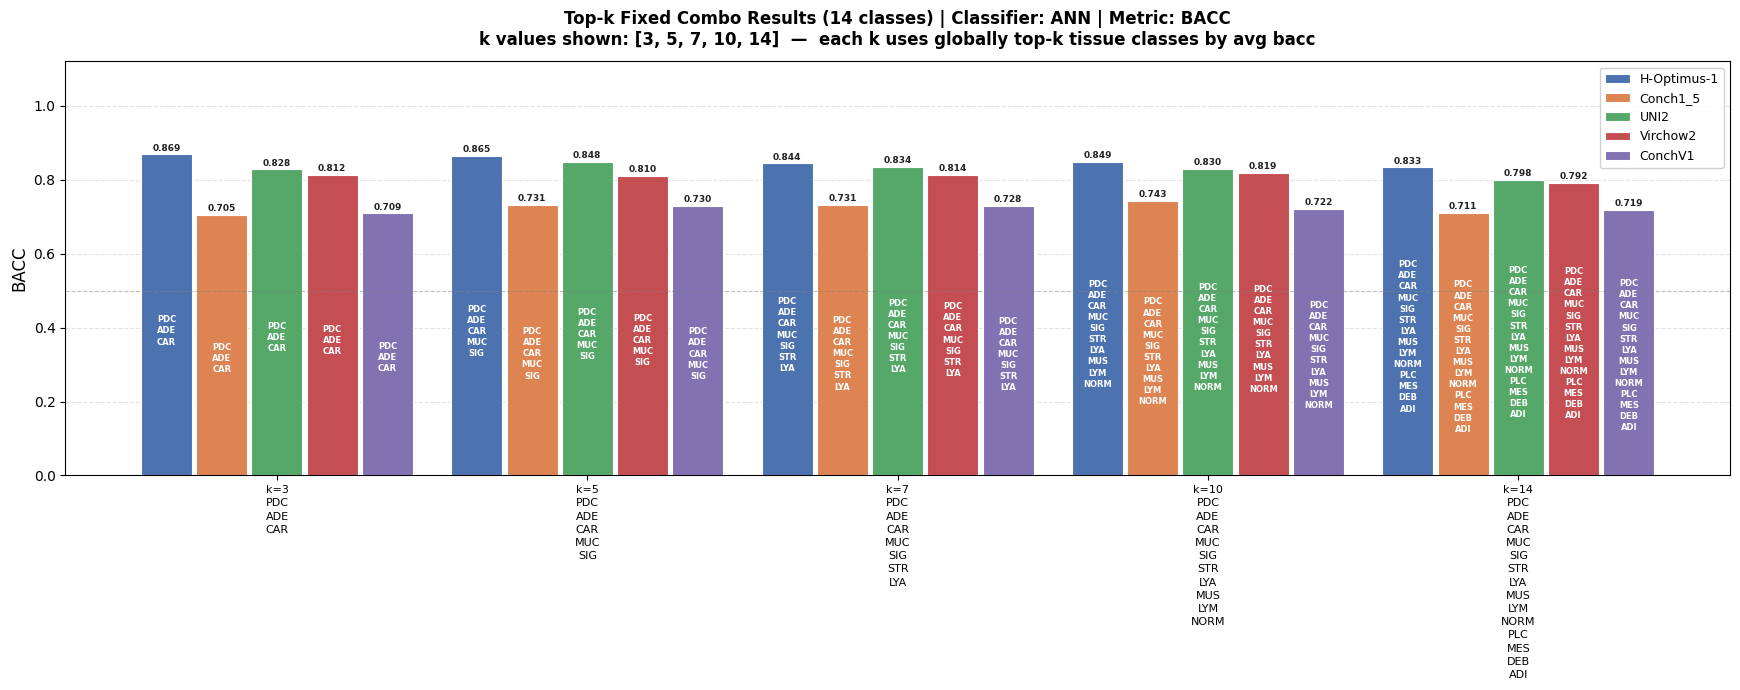

[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\by_model_topk_14cls.png


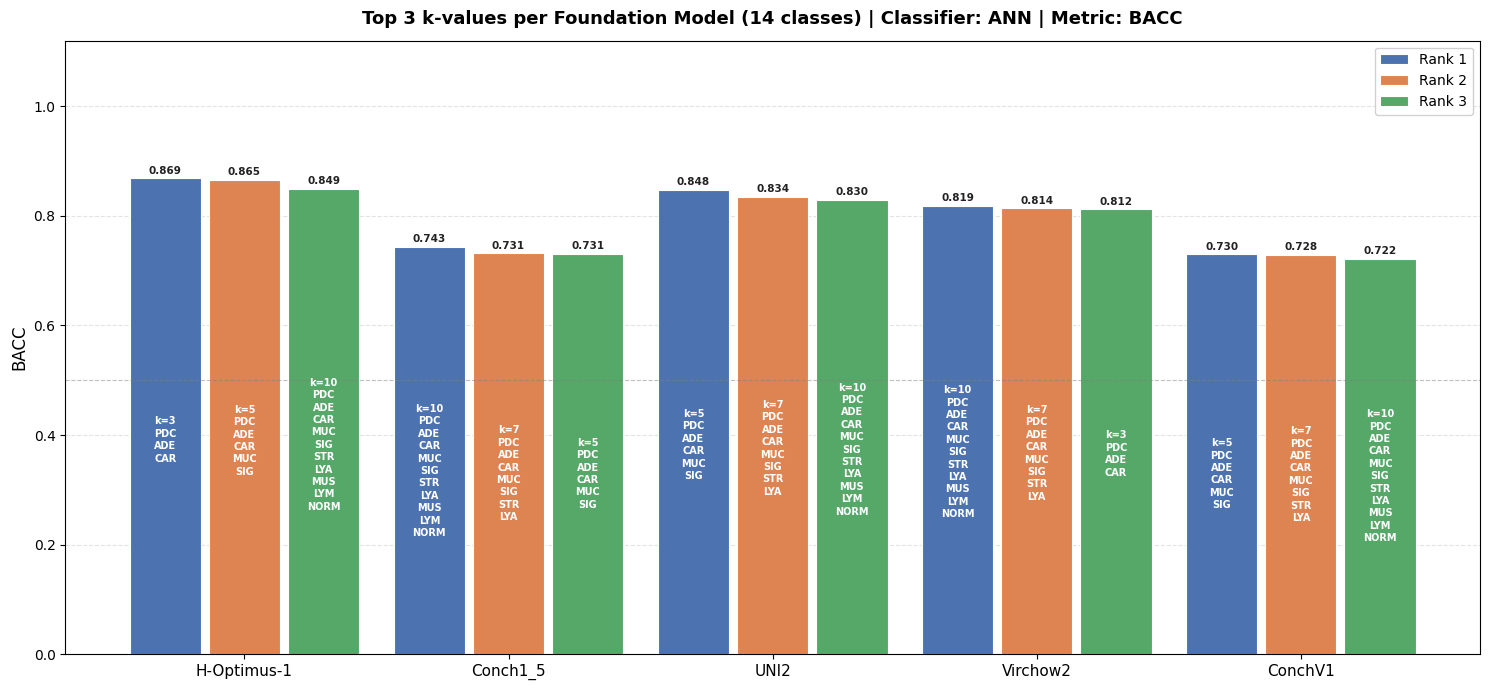

In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Configuration ─────────────────────────────────────────────────────────────
BASE_14 = os.path.join(
    r"D:\Aamir Gulzar\KSA_project2",
    "Cancer-detection-classifier", "slide_classification",
    "TCGA_Results_Updated", "Caption_based_aggregation",
    "Global",               # Phase 2 summaries now live under Global/<task>/
    "1-MSIH",
)

MODEL_NAMES_CHART_14 = [
    "H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"
]

CLASSIFIER_14   = "ann"
RANK_METRIC_14  = "bacc"

# ── Which k values to visualise in the "across k" chart ───────────────────────
# Change this list to show any k values you have results for.
K_VALUES_SHOW = [3, 5, 7, 10,14]

TISSUE_ABBREV = {
    "adipose":             "ADI",
    "debris":              "DEB",
    "lymphocyte":          "LYM",
    "plasma_cell":         "PLC",
    "lymphoid_agg":        "LYA",
    "mucin":               "MUC",
    "smooth_muscle":       "MUS",
    "normal_mucosa":       "NORM",
    "adenoma":             "ADE",
    "stroma":              "STR",
    "mesenchymal":         "MES",
    "carcinoma":           "CAR",
    "poor_diff_carcinoma": "PDC",
    "signet_ring":         "SIG",
}


def abbrev_combo(combo_str: str) -> str:
    """Replace tissue names in a '+'-separated combo string with abbreviations."""
    parts = [p.strip() for p in combo_str.split("+") if p.strip()]
    return "\n".join(TISSUE_ABBREV.get(p, p) for p in parts)


# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# Phase 2 now writes one file per k: tissue_topk_summary_14cls_k{k}.xlsx
# Each file has columns: foundation_model, combo, k, classifier, bacc, ...
# ─────────────────────────────────────────────────────────────────────────────

def load_k_14(k_val: int) -> pd.DataFrame | None:
    """
    Load the single top-k combo result file for the given k.
    Returns a DataFrame filtered to the requested classifier,
    or None if the file doesn't exist / has no matching rows.
    """
    fname = f"tissue_topk_summary_14cls_k{k_val}.xlsx"
    path  = os.path.join(BASE_14, fname)

    if not os.path.exists(path):
        print(f"[WARN] Not found: {path}")
        return None

    df = pd.read_excel(path)
    if df.empty:
        print(f"[WARN] Empty: {path}")
        return None

    df["classifier"] = df["classifier"].astype(str)
    df_clf = df[df["classifier"].str.lower().str.startswith(CLASSIFIER_14.lower())].copy()

    if df_clf.empty:
        print(f"[WARN] No '{CLASSIFIER_14}' rows in {path}")
        return None

    print(f"[OK] k={k_val}: {len(df_clf)} '{CLASSIFIER_14}' rows across "
          f"{df_clf['foundation_model'].nunique()} models")
    return df_clf


# ─────────────────────────────────────────────────────────────────────────────
# CHART 1 — Results across k values
#
# x-axis  : k values  (one group per k)
# bars    : one bar per foundation model inside each k group
# y-axis  : bacc
# No mean bar.
#
# Each bar is labelled with the abbreviated combo text inside the bar.
# ─────────────────────────────────────────────────────────────────────────────

def plot_across_k_14(
    k_data:  dict,   # {k_val: DataFrame}
    metric:  str = RANK_METRIC_14,
):
    """
    k_data : mapping k_val → filtered DataFrame (one row per foundation model
             for that k's fixed combo).
    """
    valid_k = sorted([k for k, df in k_data.items() if df is not None])
    if not valid_k:
        print("[WARN] No valid k data to plot.")
        return

    n_models = len(MODEL_NAMES_CHART_14)
    palette  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

    bar_w    = 0.13
    group_w  = n_models * bar_w + 0.08          # total width per k group
    x        = np.arange(len(valid_k)) * group_w

    fig, ax = plt.subplots(figsize=(max(14, len(valid_k) * 3.5), 7))

    for mi, model_name in enumerate(MODEL_NAMES_CHART_14):
        color  = palette[mi % len(palette)]
        offset = (mi - n_models / 2 + 0.5) * bar_w

        for ki, k_val in enumerate(valid_k):
            df = k_data[k_val]
            # Each k file has one row per foundation model
            sub = df[df["foundation_model"] == model_name]
            if sub.empty:
                continue

            val   = sub[metric].mean()           # mean across classifiers if >1 row
            combo = sub["combo"].iloc[0]
            xpos  = x[ki] + offset

            ax.bar(xpos, val, width=bar_w - 0.01,
                   color=color, edgecolor="white", linewidth=0.8,
                   label=model_name if ki == 0 else "")

            # Value above bar
            ax.text(xpos, val + 0.005, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=6.5,
                    fontweight="bold", color="#222222")

            # Abbreviated combo inside bar
            abbrev = abbrev_combo(combo)
            if val > 0.08:
                ax.text(xpos, val * 0.45, abbrev,
                        ha="center", va="center",
                        fontsize=6, color="white", fontweight="bold",
                        linespacing=1.3, clip_on=True,
                        multialignment="center")

    # x-tick labels: show k value and which tissues it contains
    xtick_labels = []
    for k_val in valid_k:
        df = k_data[k_val]
        if df is not None and not df.empty:
            combo = df["combo"].iloc[0]
            abbrev = abbrev_combo(combo)
            xtick_labels.append(f"k={k_val}\n{abbrev}")
        else:
            xtick_labels.append(f"k={k_val}")

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=8, linespacing=1.4)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top-k Fixed Combo Results (14 classes) | "
        f"Classifier: {CLASSIFIER_14.upper()} | Metric: {metric.upper()}\n"
        f"k values shown: {valid_k}  —  each k uses globally top-k tissue classes by avg bacc",
        fontsize=12, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=9,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    k_str    = "_".join(str(k) for k in valid_k)
    out_path = os.path.join(os.getcwd(), f"across_k_14cls_{k_str}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CHART 2 — Per foundation model, top-3 k values ranked by bacc
#
# x-axis  : foundation model
# bars    : top-3 k values (ranked by bacc for that model), one bar each
# y-axis  : bacc
# Bar interior shows k=N + abbreviated combo.
# ─────────────────────────────────────────────────────────────────────────────

def plot_by_model_14(
    k_data:  dict,   # {k_val: DataFrame}
    metric:  str = RANK_METRIC_14,
    top_n:   int = 3,
):
    """
    For each foundation model, ranks all k values by their bacc and shows the
    top_n as grouped bars. This replaces the old "top combos per model" chart
    which no longer makes sense since there is only one combo per k.
    """
    valid_k  = sorted([k for k, df in k_data.items() if df is not None])
    if not valid_k:
        print("[WARN] No valid k data to plot.")
        return

    palette  = ["#4C72B0", "#DD8452", "#55A868"]
    models   = MODEL_NAMES_CHART_14
    n_models = len(models)

    # For each model, collect (k_val, bacc, combo) sorted by bacc desc
    model_ranked: dict = {}
    for model_name in models:
        entries = []
        for k_val in valid_k:
            df  = k_data[k_val]
            if df is None:
                continue
            sub = df[df["foundation_model"] == model_name]
            if sub.empty:
                continue
            val   = sub[metric].mean()
            combo = sub["combo"].iloc[0]
            entries.append({"k": k_val, metric: val, "combo": combo})
        entries.sort(key=lambda d: d[metric], reverse=True)
        model_ranked[model_name] = entries[:top_n]

    width   = 0.3
    offsets = np.linspace(-(top_n - 1) / 2, (top_n - 1) / 2, top_n) * width
    x       = np.arange(n_models)

    fig, ax = plt.subplots(figsize=(15, 7))

    for ci in range(top_n):
        color = palette[ci % len(palette)]
        for mi, model_name in enumerate(models):
            entries = model_ranked.get(model_name, [])
            if ci >= len(entries):
                continue
            entry = entries[ci]
            val   = entry[metric]
            k_val = entry["k"]
            combo = entry["combo"]
            xpos  = x[mi] + offsets[ci]

            ax.bar(xpos, val, width=width - 0.03,
                   color=color, edgecolor="white", linewidth=0.8,
                   label=f"Rank {ci + 1}" if mi == 0 else "")

            # Value above bar
            ax.text(xpos, val + 0.005, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold", color="#222222")

            # k label + abbreviated combo inside bar
            label_text = f"k={k_val}\n{abbrev_combo(combo)}"
            if val > 0.08:
                ax.text(xpos, val * 0.45, label_text,
                        ha="center", va="center",
                        fontsize=7, color="white", fontweight="bold",
                        linespacing=1.3, clip_on=True,
                        multialignment="center")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top {top_n} k-values per Foundation Model (14 classes) | "
        f"Classifier: {CLASSIFIER_14.upper()} | Metric: {metric.upper()}",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=10,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), "by_model_topk_14cls.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# MAIN — load all requested k values then produce both charts
# ─────────────────────────────────────────────────────────────────────────────

k_data = {}
for k in K_VALUES_SHOW:
    df = load_k_14(k)
    k_data[k] = df

    if df is not None:
        print(f"\nResults for k={k}:")
        print(
            df[["foundation_model", "combo", "k", RANK_METRIC_14]]
            .sort_values(RANK_METRIC_14, ascending=False)
            .to_string(index=False)
        )

# Chart 1: results across all k values, bars = foundation models
plot_across_k_14(k_data, RANK_METRIC_14)

# Chart 2: per foundation model, best k values as ranked bars
plot_by_model_14(k_data, RANK_METRIC_14, top_n=3)